# warm step-up sweep — variance, warm-up cost, and the per-run/overhead split

This notebook analyses a **`logs/warm_stepup/`** run on the server. Unlike the
parameter sweeps (`sharedBuffers`, `workMem`, …), here **nothing is swept** —
every run uses the same server configuration. What varies is the **batch size**
of a warm query and the fact that the whole thing is **repeated** with a server
restart in between.

`logs/warm_stepup/` now contains **several runs** (see §1b), so the notebook
fetches them all and you pick one with `RUN_SELECT` — the original 3-repeat run,
the newer 10-repeat / 530-group run, or any other.

**How each run is structured** (from its `run_order`): for every one of the
53 tpch query files a *group* is run as

* a fresh **server restart**, then
* **2 warm-ups** (`phase=warmup`, `batchnum=1`), then
* a **measured step-up**: one batch at `batchnum = 1, 2, 4, 8, 16`
  (`phase=measured`), where a batch of size *n* just runs the same warm query
  *n* times back-to-back.

Each query gets **several such groups** (3 in the original run, 10 in the
530-group run), executed in a **random order** so slow drift or thermal effects
don't line up with any one query. One group = one `run_id`.

Two useful facts about the timing file:

* `avg_copy_elapsed_sec` is the **per-copy** time (`elapsed_sec / batchnum`);
* `elapsed_sec` is the **whole batch** time;
* `rapl_pkg_j` is the **whole batch** package energy, so per-copy energy is
  `rapl_pkg_j / batchnum`.

Every part of the analysis is reported for **both runtime and package energy
(RAPL `pkg`)**:

1. **Variance per `batchnum` per query** — how repeatable the per-copy time /
   energy is, and whether averaging over a bigger batch stabilises it.
2. **Warm-up statistics** — how the first (cold) run compares to the second
   warm-up and to the first genuinely warm measured run, in both time and energy.
3. **A line of best fit** of the whole-batch time / energy vs `batchnum` per
   query: the **slope** is the cost of one additional warm run, and the
   **y-intercept** is the fixed **overhead** paid once per batch.

Axes are kept **linear** wherever the data spans about one order of magnitude
(the batch axis uses evenly-spaced ticks rather than a log scale); no plot below
uses a log axis.


## 1. Fetch `logs/warm_stepup/` (every run) → local `ws_cache/`

`logs/warm_stepup/` now holds **several runs**. The original one still sits loose
in the top level; newer runs each live in their own `<timestamp>Z-<id>/`
subfolder (and some of those are just an aborted `run_order` with no data). Same
fetch/cache idiom as the other notebooks, but we now **walk the whole tree** over
SFTP with a few retries, mirror every `*.csv`, `run_order*.txt` and `summary.txt`
into `ws_cache/` **preserving the folder layout**, and fall back to that cache on
any failure (`console.log` is skipped — it is large and unused). Section 1b then
lists the runs and lets you choose one.


In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time, stat, posixpath
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_WS = "/home/user01/GreenSQL/logs/warm_stepup"
CACHE_DIR = Path("ws_cache")         # new cache, separate from the sweep caches
RETRIES = 5


def _want(fn):
    return (fn.endswith(".csv") or fn.startswith("run_order")
            or fn == "summary.txt")


def _collect(sftp, d, base, blobs):
    for a in sftp.listdir_attr(d):
        p = posixpath.join(d, a.filename)
        if stat.S_ISDIR(a.st_mode):
            _collect(sftp, p, base, blobs)          # recurse into subfolders
        elif _want(a.filename):
            blobs[posixpath.relpath(p, base)] = sftp.open(p).read()


def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    _collect(sftp, REMOTE_WS, REMOTE_WS, blobs)
                    if not blobs:
                        raise RuntimeError(f"no files under {REMOTE_WS}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        for rel, b in blobs.items():                 # mirror the folder layout
            fp = CACHE_DIR / rel
            fp.parent.mkdir(parents=True, exist_ok=True)
            fp.write_bytes(b)
        print(f"Fetched {len(blobs)} files from {SSH_HOST}; "
              f"cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*")
                 if p.is_file() and p.suffix in (".csv", ".txt")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
print(f"source: {SOURCE};  {len(BLOBS)} files cached")


Fetched 52 files from 192.168.1.42; cache 'ws_cache/' updated.
source: server;  52 files cached


## 1b. Discover the available runs and pick one

Every `query_timing_*.csv` in the tree is one run. The loose top-level files are
labelled **`original`**; a run inside a subfolder takes the folder name (which
ends in a short id) as its `run_id`. We read each timing file to count its groups
(`run_id`s) and queries, and pull the db name from the filename and the start
time from the folder name / `run_order` header.

**Set `RUN_SELECT`** to choose which run the rest of the notebook analyses:

* a **database name** (`"tpch_idx"`, `"tpch"`) — matches that run's db exactly;
* `"latest"`  — the most recent run that has data;
* `"largest"` — the run with the most groups;
* `"original"`— the loose top-level run;
* any part of a run id, e.g. `"4cb234"`.

The default is pinned to **`"tpch_idx"`** (the indexed 530-run set). Note that
`"latest"` would now resolve to the newer minimally-indexed `tpch` run (fetched
2026-09-11), so pinning the db name keeps §2–§13 on the indexed set regardless of
what new runs land in the cache.


In [2]:
def _generated_ts(txt):
    m = re.search(r"generated\s+(\d{4}-\d\d-\d\dT[\d:]+Z)", txt)
    if not m:
        return pd.NaT
    return pd.to_datetime(m.group(1), utc=True).tz_convert(None)   # naive UTC


def discover_runs(blobs):
    rows = []
    for key in blobs:
        fn = key.split("/")[-1]
        if not (fn.startswith("query_timing_") and fn.endswith(".csv")):
            continue
        d = "/".join(key.split("/")[:-1])            # "" for the top level
        rid = d if d else "original"
        db = fn[len("query_timing_"):-len(".csv")]   # tpch / tpch_idx / ...
        pref = (d + "/") if d else ""
        sib = {k.split("/")[-1]: k for k in blobs
               if k.startswith(pref) and "/" not in k[len(pref):]}
        ts = pd.NaT
        for name, k in sib.items():
            if name.startswith("run_order"):
                ts = _generated_ts(blobs[k].decode("utf-8", "replace"))
        if d:                                        # folder name leads with ts
            try:
                ts = pd.to_datetime(d.split("Z-")[0] + "Z", format="%Y%m%dT%H%M%SZ")
            except Exception:
                pass
        t = pd.read_csv(io.BytesIO(blobs[key]))
        rows.append(dict(run_id=rid, db=db, folder=d or "(top level)",
                         groups=int(t["run_id"].nunique()),
                         queries=int(t["query"].nunique()),
                         timing_key=key, timestamp=ts))
    df = pd.DataFrame(rows)
    df["repeats"] = (df["groups"] / df["queries"]).round(1)
    return df.sort_values("timestamp").reset_index(drop=True)


RUNS = discover_runs(BLOBS)
print("Available runs (with data):")
print(RUNS[["run_id", "db", "groups", "queries", "repeats", "timestamp"]]
      .to_string(index=False))

# ---------------------------------------------------------------------------
RUN_SELECT = "tpch_idx"   # db name | "latest" | "largest" | "original" | id substring
# ---------------------------------------------------------------------------


def resolve_run(df, sel):
    sel = str(sel).strip()
    if sel == "latest":
        return df.dropna(subset=["timestamp"]).sort_values("timestamp").iloc[-1]
    if sel == "largest":
        return df.sort_values("groups").iloc[-1]
    if sel in ("original", "toplevel", "root"):
        m = df[df["run_id"] == "original"]
    else:
        m = df[df["run_id"].str.contains(sel, case=False)
               | (df["db"].astype(str).str.lower() == sel.lower())]
    if len(m) == 0:
        raise ValueError(f"RUN_SELECT={sel!r} matched nothing; "
                         f"choose from {list(df['run_id'])}")
    if len(m) > 1:
        # several runs share this db/id (e.g. a newer partial re-run still in
        # progress): take the most complete (most groups), latest timestamp to break
        pick = m.sort_values(["groups", "timestamp"]).iloc[-1]
        print(f"   ({sel!r} matched {len(m)} runs {list(m['run_id'])}; "
              f"using '{pick['run_id']}' — most groups)")
        return pick
    return m.iloc[0]


SEL = resolve_run(RUNS, RUN_SELECT)
raw = pd.read_csv(io.BytesIO(BLOBS[SEL["timing_key"]]))
print(f"\n>> analysing run '{SEL['run_id']}'  (db={SEL['db']}, "
      f"{SEL['groups']} groups, {SEL['queries']} queries, "
      f"{SEL['repeats']:g} repeats/query)")


Available runs (with data):
                 run_id       db  groups  queries  repeats           timestamp
               original     tpch     159       53      3.0 2026-09-04 10:26:15
20260907T085817Z-4cb234 tpch_idx     530       53     10.0 2026-09-07 08:58:17
20260911T114224Z-7b276d     tpch     530       53     10.0 2026-09-11 11:42:24
20260917T105341Z-de2df1 tpch_idx     530       53     10.0 2026-09-17 10:53:41
20260918T141724Z-9150d4 tpch_idx     159       53      3.0 2026-09-18 14:17:24
20260918T153808Z-7f8715 tpch_idx     159       53      3.0 2026-09-18 15:38:08
20260918T172207Z-8ec834 tpch_idx     159       53      3.0 2026-09-18 17:22:07
20260918T204804Z-d479ea tpch_idx     159       53      3.0 2026-09-18 20:48:04
20260918T224909Z-a543de tpch_idx     159       53      3.0 2026-09-18 22:49:09
20260919T002827Z-f3d31e tpch_idx     159       53      3.0 2026-09-19 00:28:27
   ('tpch_idx' matched 8 runs ['20260907T085817Z-4cb234', '20260917T105341Z-de2df1', '20260918T141724Z-

## 2. Build the per-run table

Take the timing CSV of the **selected run** (§1b), coerce the numeric columns,
drop any failed rows, and derive `qid` (`q05/base.sql`), `sql_file`, and `group`
(`q05`) exactly like the other notebooks. Each `run_id` is one group; within a
query we number its groups **in the order they actually ran** (`repeat`), so we
can line up "the same batch size across the restarts" (3 for the original run,
10 for the 530-group run, etc.). Negative RAPL readings (counter overflow) are
set to `N/A`. Finally we split the rows into the **warm-up** phase and the
**measured** step-up phase, and add per-copy runtime and per-copy
package-energy columns.


In [3]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


# `raw` is the selected run's timing table, loaded in §1b
NUM = ["batch_index", "batchnum", "runs", "warmup", "elapsed_sec",
       "avg_copy_elapsed_sec", "server_sum_ms", "client_overhead_sec",
       "rapl_pkg_j", "rapl_core_j", "failed"]
for c in NUM:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw = raw[raw["failed"].fillna(0) == 0].copy()
raw["timestamp_utc"] = pd.to_datetime(raw["timestamp_utc"], errors="coerce")

# RAPL counter overflow -> N/A (same guard as the sweep notebooks)
for c in ["rapl_pkg_j", "rapl_core_j"]:
    raw.loc[raw[c] < 0, c] = np.nan

raw["qid"] = raw["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)
raw["sql_file"] = raw["query"].astype(str).str.split("/").str[-1]
raw["group"] = raw["query"].map(query_group)

# number each query's groups 1..N in the order they ran (by first timestamp)
srt = raw.sort_values("timestamp_utc")
rep_map = {}
for qid, g in srt.groupby("qid"):
    for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
        rep_map[(qid, rid)] = i
raw["repeat"] = [rep_map[(q, r)] for q, r in zip(raw["qid"], raw["run_id"])]

measured = raw[raw["phase"] == "measured"].copy()
warm = raw[raw["phase"] == "warmup"].copy()

# per-copy quantities (a batch of size n runs the query n times back-to-back)
measured["copy_time_s"] = measured["avg_copy_elapsed_sec"]
measured["copy_pkg_j"] = measured["rapl_pkg_j"] / measured["batchnum"]

BATCH = sorted(measured["batchnum"].dropna().unique().astype(int))
NREP = int(measured["repeat"].max())

reps = raw.groupby("qid")["repeat"].max()
print(f"{raw['qid'].nunique()} query files; {raw['run_id'].nunique()} groups "
      f"(run_ids); repeats per query: min={reps.min()}, max={reps.max()}")
print(f"batch sizes in the step-up: {BATCH}")
print(f"measured rows: {len(measured)}; warm-up rows: {len(warm)}")


53 query files; 530 groups (run_ids); repeats per query: min=10, max=10
batch sizes in the step-up: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
measured rows: 3710; warm-up rows: 1060


## 3. Task 1 — variance of the per-copy time **and energy** at each `batchnum`

For a fixed query and a fixed `batchnum` we have **three** measured values (one
per restarted group). Their spread is the run-to-run reproducibility at that
batch size. We report the coefficient of variation `CV% = 100 · std / mean`
(unitless, so it's comparable across fast and slow queries) for **per-copy
runtime** and **per-copy package energy**.

The step-up exists precisely to test the expectation that **a larger batch
averages out per-invocation noise**, so the per-copy CV should generally *fall*
as `batchnum` grows. Each line below is the median CV across all queries at each
batch size (with the inter-quartile band and every query as a faint line). The
batch axis uses evenly-spaced ticks (`1, 2, 4, 8, 16`) and the y-axis is linear;
the y-limit is clipped to the bulk of the queries so the medians stay readable
(a few noisy queries — listed in the table — run off the top).


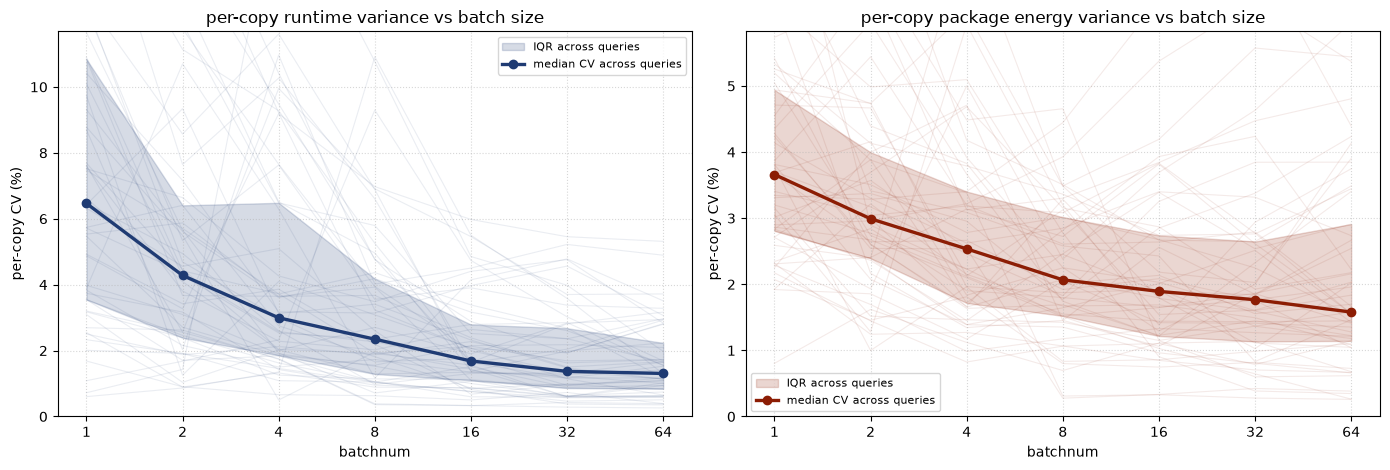

Median per-copy CV(%) by batch size (across 53 queries):
          runtime_cv%  energy_cv%
batchnum                         
1                6.46        3.66
2                4.28        2.99
4                2.99        2.54
8                2.35        2.07
16               1.68        1.89
32               1.37        1.77
64               1.31        1.58

Least reproducible queries at batchnum=1 (highest runtime CV%):
                     qid  mean_copy_s  std_copy_s  cv_pct
            q11/base.sql       0.1338      0.0276 20.6399
 q11/v1_materialized.sql       0.1653      0.0299 18.0776
            q04/base.sql       0.1565      0.0273 17.4653
 q14/v1_materialized.sql       0.2086      0.0351 16.8272
q11/v2_cte_threshold.sql       0.1634      0.0265 16.1866
           q04/v2_in.sql       0.1619      0.0260 16.0397
 q04/v1_materialized.sql       0.1625      0.0240 14.7530
       q14/v2_filter.sql       0.2012      0.0295 14.6802
            q14/base.sql       0.2216      0.0280 

In [4]:
import matplotlib.pyplot as plt


def variance_table(col):
    v = measured.groupby(["qid", "batchnum"]).agg(
        n=(col, "size"), mean=(col, "mean"), std=(col, "std"),
    ).reset_index()
    v["cv_pct"] = 100 * v["std"] / v["mean"]
    return v


var_t = variance_table("copy_time_s")
var_e = variance_table("copy_pkg_j")
xpos = np.arange(len(BATCH))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color) in zip(
        axes,
        [(var_t, "per-copy runtime", "#1f3b73"),
         (var_e, "per-copy package energy", "#8c1d04")]):
    piv = v.pivot(index="qid", columns="batchnum", values="cv_pct").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    q1, q3 = piv.quantile(0.25), piv.quantile(0.75)
    ax.fill_between(xpos, q1.values, q3.values, color=color, alpha=0.18,
                    label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median CV across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_xlabel("batchnum"); ax.set_ylabel("per-copy CV (%)")
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_title(f"{title} variance vs batch size")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median per-copy CV(%) by batch size (across {} queries):".format(
    var_t["qid"].nunique()))
tab = pd.DataFrame({
    "runtime_cv%": var_t.groupby("batchnum")["cv_pct"].median(),
    "energy_cv%": var_e.groupby("batchnum")["cv_pct"].median(),
}).round(2)
print(tab.to_string())

print("\nLeast reproducible queries at batchnum=1 (highest runtime CV%):")
top = (var_t[var_t["batchnum"] == 1].sort_values("cv_pct", ascending=False)
       .head(12)[["qid", "mean", "std", "cv_pct"]]
       .rename(columns={"mean": "mean_copy_s", "std": "std_copy_s"}))
print(top.round(4).to_string(index=False))


## 4. Task 2 — warm-up statistics per query (runtime **and** energy)

Each group runs two warm-ups before the measured step-up. We line up, per group:

* **`warmup1`** — the very first execution after the restart (coldest: cold OS
  page cache / cold buffer cache);
* **`warmup2`** — the second warm-up;
* **`warm`** — the first *measured* single run (`batchnum=1`), the representative
  steady value.

Averaging the three groups per query, `cold penalty = warmup1 / warm` is how
much heavier the first cold run is than warm, and `warmup2 / warm` says whether
**one** warm-up already reaches steady state. Everything is a **ratio**, so the
bars are on a plain linear axis (no log needed). The left panel is runtime, the
right is package energy, for the same set of queries (ranked by runtime cold
penalty) so the two levers line up.


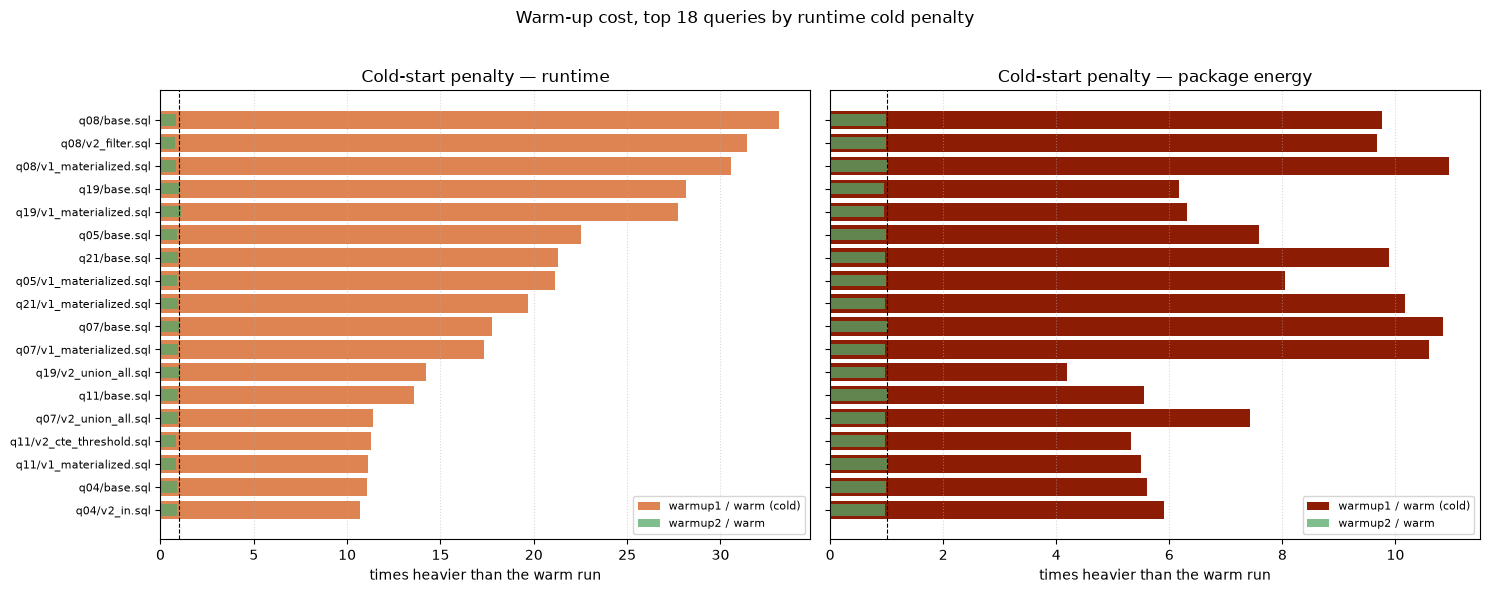

[runtime] cold penalty (warmup1/warm): median 6.65x, mean 9.51x, max 33.15x;  after 1 warm-up: median 0.94x, 48/53 queries within 5% of warm.
[energy] cold penalty (warmup1/warm): median 3.31x, mean 4.45x, max 10.95x;  after 1 warm-up: median 1.00x, 51/53 queries within 5% of warm.

Queries with the largest runtime cold penalty (with their energy penalty):
                    qid  warmup1_s  warm_s  cold_x_time  cold_x_energy
           q08/base.sql      6.804   0.207       33.153          9.770
      q08/v2_filter.sql      6.811   0.216       31.414          9.674
q08/v1_materialized.sql      6.294   0.210       30.588         10.948
           q19/base.sql      1.884   0.067       28.142          6.169
q19/v1_materialized.sql      1.854   0.067       27.750          6.317
           q05/base.sql      7.382   0.329       22.508          7.586
           q21/base.sql     11.594   0.545       21.285          9.894
q05/v1_materialized.sql      6.983   0.336       21.132          8.048
q2

In [5]:
def warm_summary(metric):
    w1 = (warm[warm["batch_index"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("w1"))
    w2 = (warm[warm["batch_index"] == 2]
          .set_index(["qid", "repeat"])[metric].rename("w2"))
    wr = (measured[measured["batchnum"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("warm"))
    m = pd.concat([w1, w2, wr], axis=1).reset_index()
    m["cold"] = m["w1"] / m["warm"]
    m["after1"] = m["w2"] / m["warm"]
    return m.groupby("qid").agg(
        w1=("w1", "mean"), w2=("w2", "mean"), warm=("warm", "mean"),
        cold=("cold", "mean"), after1=("after1", "mean")).reset_index()


# runtime uses per-copy seconds; energy uses whole-run pkg joules (batchnum=1
# rows, so rapl_pkg_j already is the per-run energy)
wq_t = warm_summary("avg_copy_elapsed_sec")
wq_e = warm_summary("rapl_pkg_j")

order = wq_t.sort_values("cold", ascending=False).head(18)["qid"].tolist()
et = wq_e.set_index("qid")
y = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, (src, title, c_cold) in zip(
        axes,
        [(wq_t.set_index("qid"), "runtime", "#dd8452"),
         (et, "package energy", "#8c1d04")]):
    cold = [src.loc[q, "cold"] for q in order]
    after1 = [src.loc[q, "after1"] for q in order]
    ax.barh(y, cold, color=c_cold, label="warmup1 / warm (cold)")
    ax.barh(y, after1, color="#55a868", alpha=0.75, height=0.5,
            label="warmup2 / warm")
    ax.axvline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("times heavier than the warm run")
    ax.set_title(f"Cold-start penalty — {title}")
    ax.grid(axis="x", linestyle=":", alpha=0.5); ax.legend(fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(order, fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Warm-up cost, top 18 queries by runtime cold penalty", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

for name, wq in [("runtime", wq_t), ("energy", wq_e)]:
    near = int((wq["after1"] <= 1.05).sum())
    print(f"[{name}] cold penalty (warmup1/warm): median {wq['cold'].median():.2f}x, "
          f"mean {wq['cold'].mean():.2f}x, max {wq['cold'].max():.2f}x;  "
          f"after 1 warm-up: median {wq['after1'].median():.2f}x, "
          f"{near}/{len(wq)} queries within 5% of warm.")

print("\nQueries with the largest runtime cold penalty (with their energy penalty):")
merged = wq_t[["qid", "w1", "warm", "cold"]].rename(
    columns={"w1": "warmup1_s", "warm": "warm_s", "cold": "cold_x_time"})
merged = merged.merge(
    wq_e[["qid", "cold"]].rename(columns={"cold": "cold_x_energy"}), on="qid")
print(merged.sort_values("cold_x_time", ascending=False).head(12)
      .round(3).to_string(index=False))


## 5. Task 3 — line of best fit: per-run cost (slope) vs fixed overhead (intercept)

For each query, plot the **whole-batch** quantity against `batchnum`, pooling all
three groups (up to 15 points), and fit an ordinary least-squares line

`y ≈ overhead + slope · batchnum`,   with `y = elapsed_sec` (runtime) or `y = rapl_pkg_j` (energy).

Because a batch just runs the same warm query `batchnum` times back-to-back, the
**slope** is the marginal **cost of one warm run** (seconds, or joules) and the
**y-intercept** (`batchnum → 0`) is the fixed **overhead** paid once per batch.
`R²` says how linear the step-up is. Both axes are linear — the whole point is
that the relationship *is* a straight line in `batchnum`.

The first figure is one representative query, runtime and energy side by side,
with the slope and intercept marked. Then a grid fits every query (runtime, then
energy), and finally the fixed overhead is summarised as a **fraction of one
run's cost** (linear) with the full fit table.


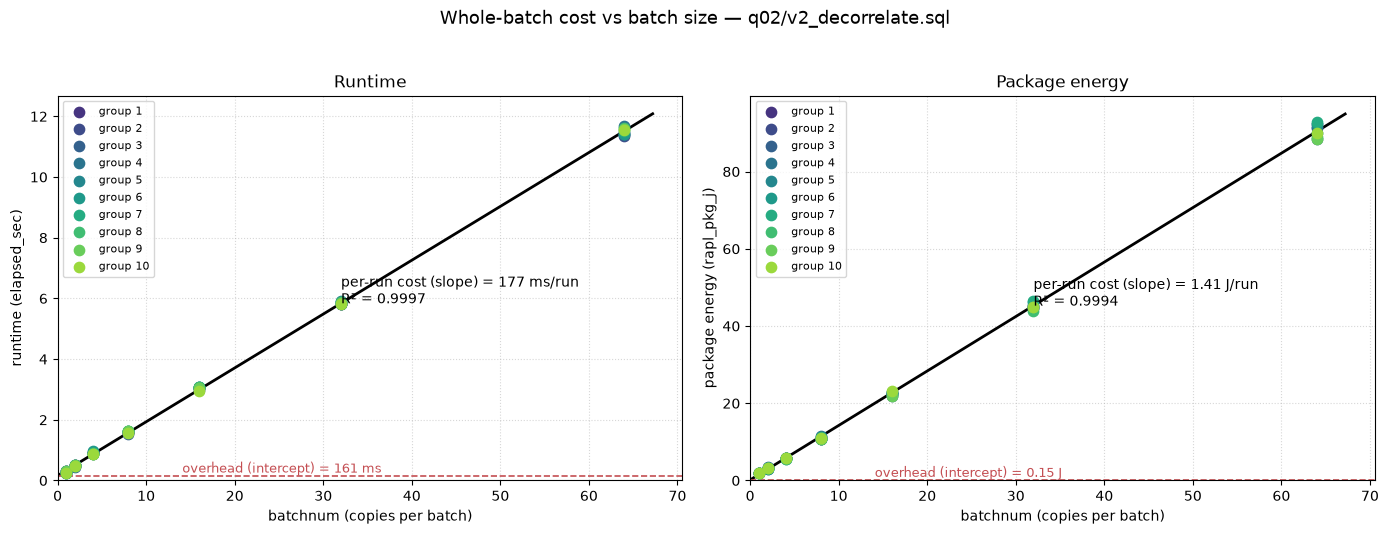

Headline query: q02/v2_decorrelate.sql
  runtime: 177.4 ms/run, overhead 161.0 ms, R²=0.9997
  energy : 1.41 J/run, overhead 0.15 J, R²=0.9994


In [6]:
def fit_line(d, ycol):
    x = d["batchnum"].to_numpy(float)
    y = d[ycol].to_numpy(float)
    ok = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[ok], y[ok]
    if len(x) < 2 or np.ptp(x) == 0:
        return None
    slope, intercept = np.polyfit(x, y, 1)
    yhat = intercept + slope * x
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2, len(x)


def fit_all(ycol):
    rows = []
    for qid, d in measured.groupby("qid"):
        res = fit_line(d, ycol)
        if res is None:
            continue
        rows.append(dict(qid=qid, slope=res[0], overhead=res[1],
                         r2=res[2], n=res[3]))
    return pd.DataFrame(rows)


fit_t = fit_all("elapsed_sec")     # runtime: slope s/run, overhead s
fit_e = fit_all("rapl_pkg_j")      # energy:  slope J/run, overhead J

# a *typical* clearly-linear query (median runtime per-run cost, positive
# overhead) so the slope and a visible positive intercept both read off the plot
cand = fit_t[(fit_t["r2"] > 0.99) & (fit_t["overhead"] > 0)].copy()
if len(cand):
    med = cand["slope"].median()
    head_qid = cand.loc[(cand["slope"] - med).abs().idxmin(), "qid"]
else:
    head_qid = fit_t.iloc[len(fit_t) // 2]["qid"]

d = measured[measured["qid"] == head_qid]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, NREP))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (fitdf, ycol, unit, scale, nice) in zip(
        axes,
        [(fit_t, "elapsed_sec", "ms", 1000, "runtime (elapsed_sec)"),
         (fit_e, "rapl_pkg_j", "J", 1, "package energy (rapl_pkg_j)")]):
    r = fitdf[fitdf["qid"] == head_qid].iloc[0]
    slope, intercept, r2 = r["slope"], r["overhead"], r["r2"]
    for rp, g in d.groupby("repeat"):
        ax.scatter(g["batchnum"], g[ycol], s=55, color=colors[int(rp) - 1],
                   label=f"group {int(rp)}", zorder=3)
    xs = np.linspace(0, max(BATCH) * 1.05, 100)
    ax.plot(xs, intercept + slope * xs, "k-", lw=2)
    ax.axhline(intercept, color="#c44e52", ls="--", lw=1.2)
    u = f"{intercept * scale:.0f} {unit}" if scale != 1 else f"{intercept:.2f} {unit}"
    su = f"{slope * scale:.0f} {unit}/run" if scale != 1 else f"{slope:.2f} {unit}/run"
    ax.annotate(f"overhead (intercept) = {u}", xy=(0, intercept),
                xytext=(max(BATCH) * 0.22, intercept), color="#c44e52",
                fontsize=9, va="bottom")
    ax.annotate(f"per-run cost (slope) = {su}\nR² = {r2:.4f}",
                xy=(max(BATCH) * 0.5, intercept + slope * max(BATCH) * 0.5),
                fontsize=10)
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    ax.set_xlabel("batchnum (copies per batch)")
    ax.set_ylabel(nice)
    ax.set_title(nice.split(" (")[0].capitalize())
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle(f"Whole-batch cost vs batch size — {head_qid}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

rt = fit_t[fit_t["qid"] == head_qid].iloc[0]
en = fit_e[fit_e["qid"] == head_qid].iloc[0]
print(f"Headline query: {head_qid}")
print(f"  runtime: {rt['slope']*1000:.1f} ms/run, overhead {rt['overhead']*1000:.1f} ms, R²={rt['r2']:.4f}")
print(f"  energy : {en['slope']:.2f} J/run, overhead {en['overhead']:.2f} J, R²={en['r2']:.4f}")


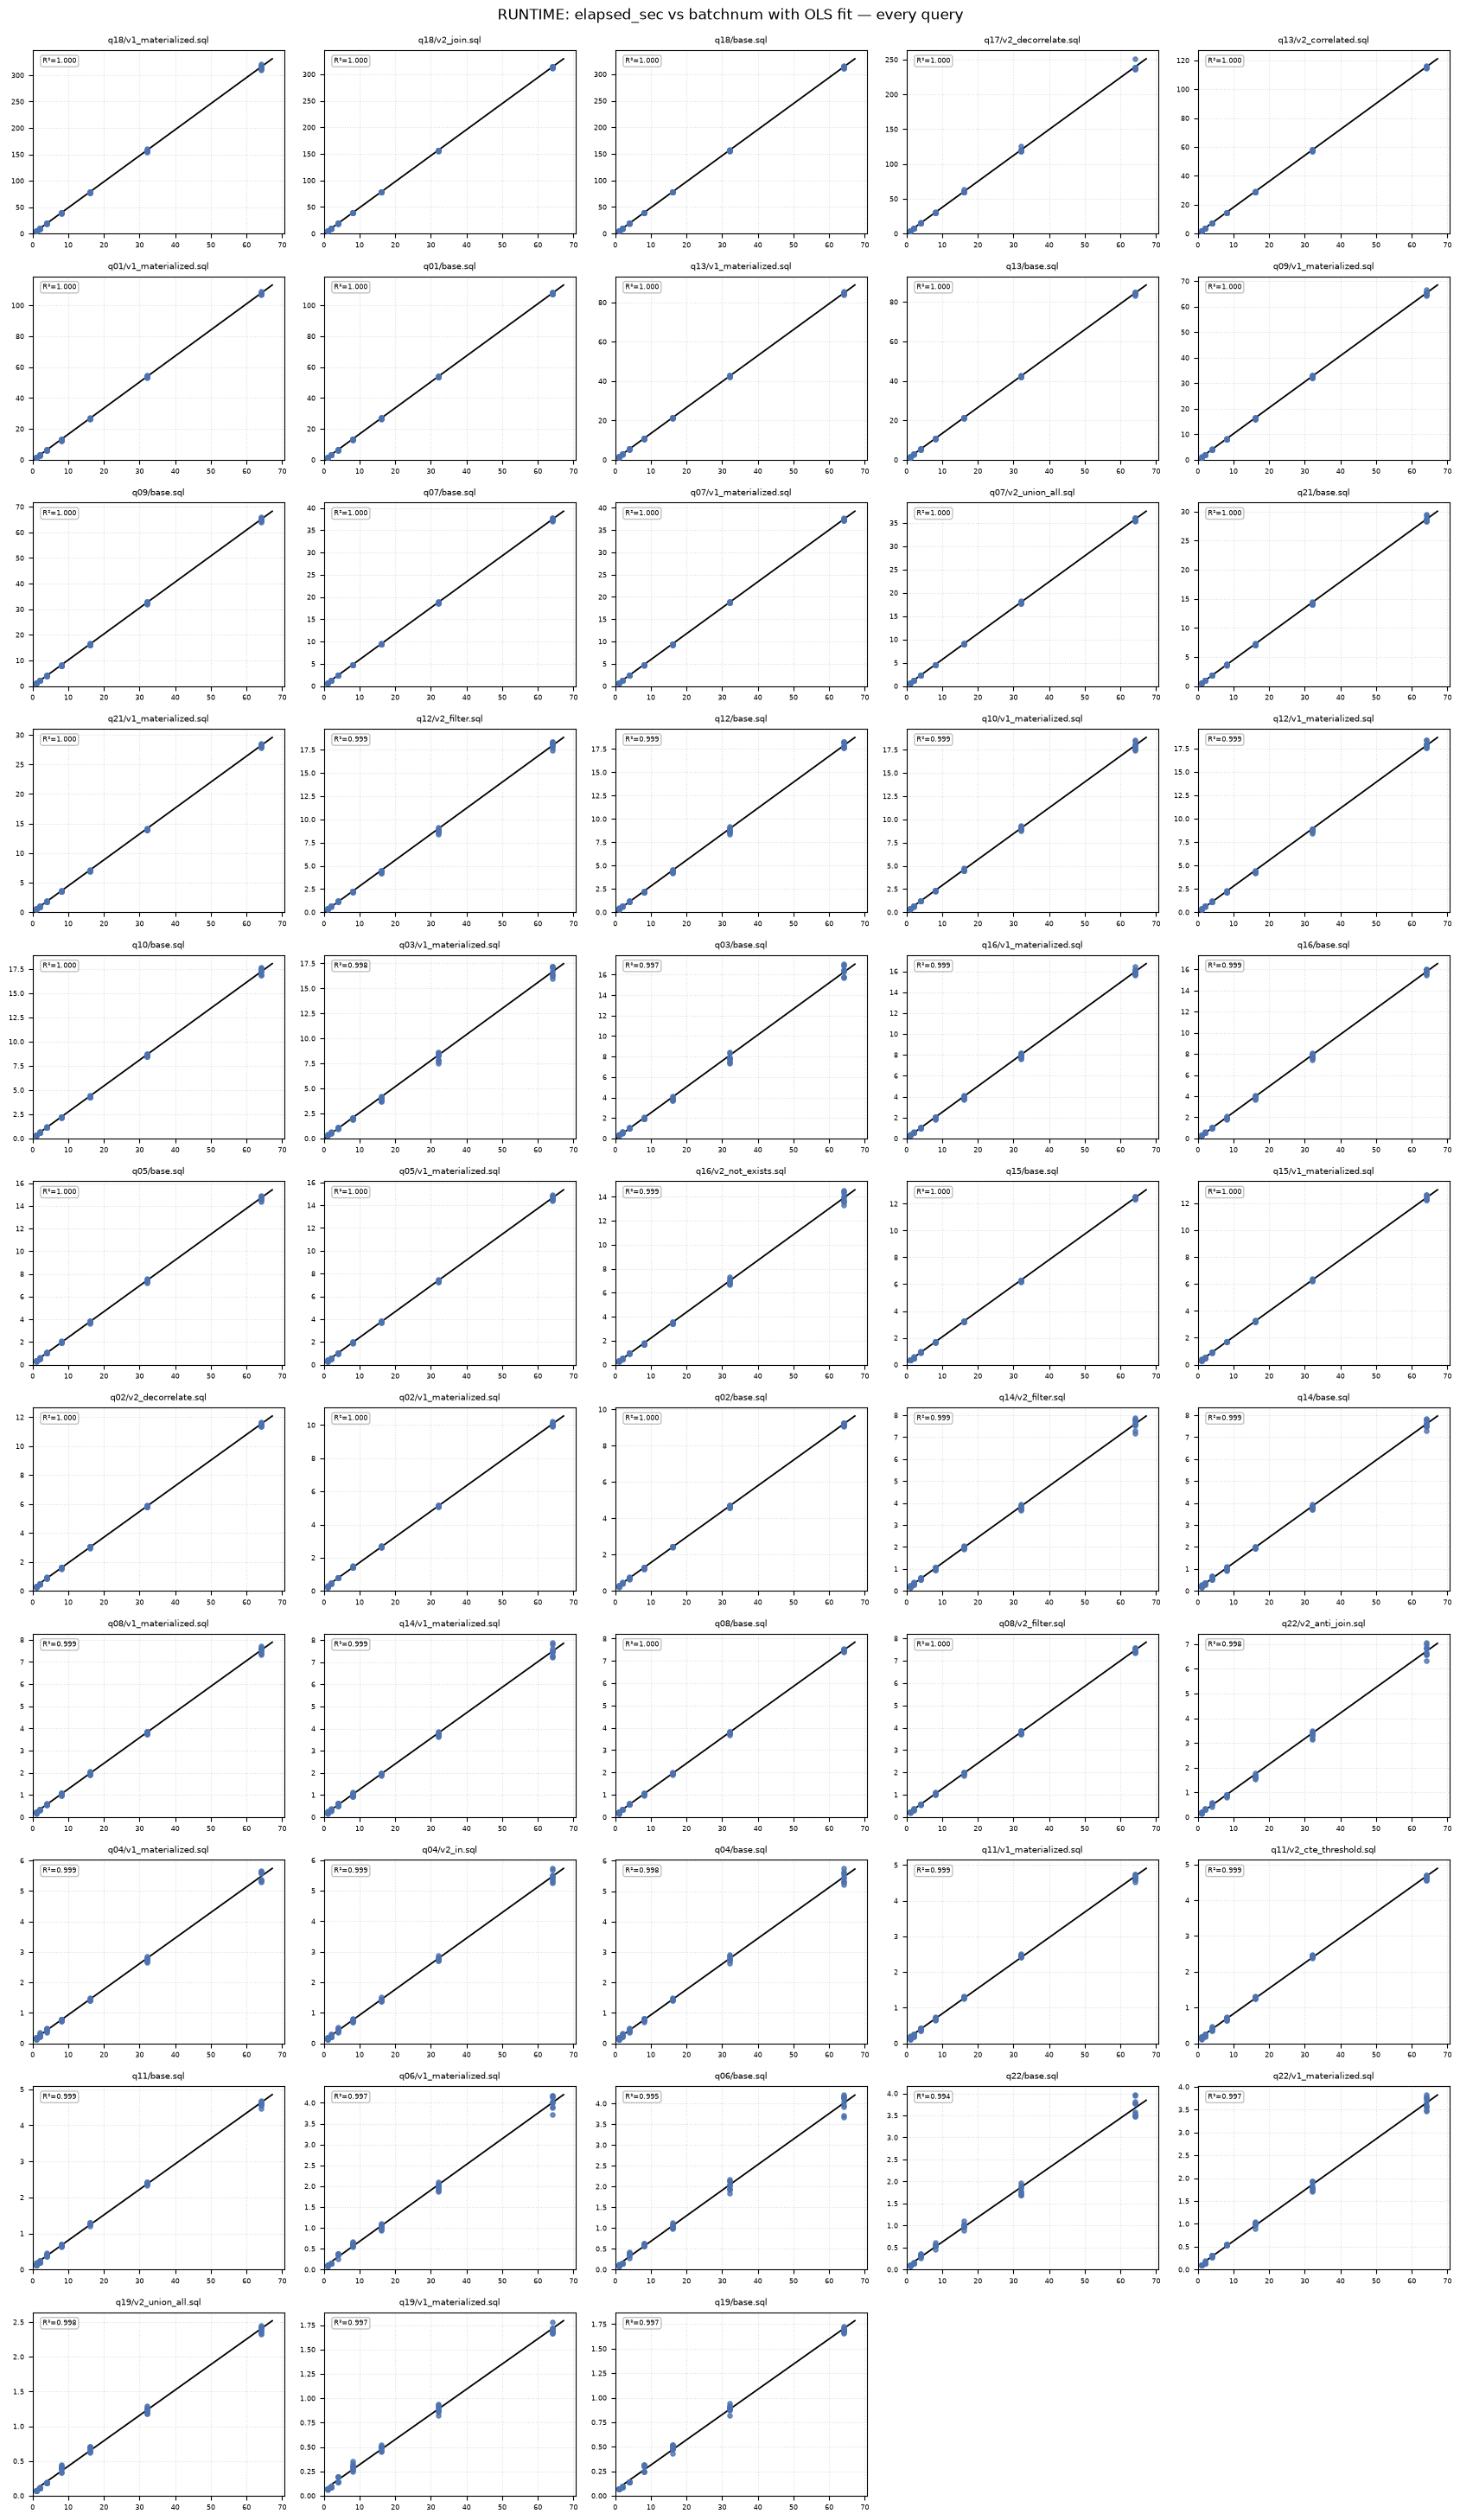

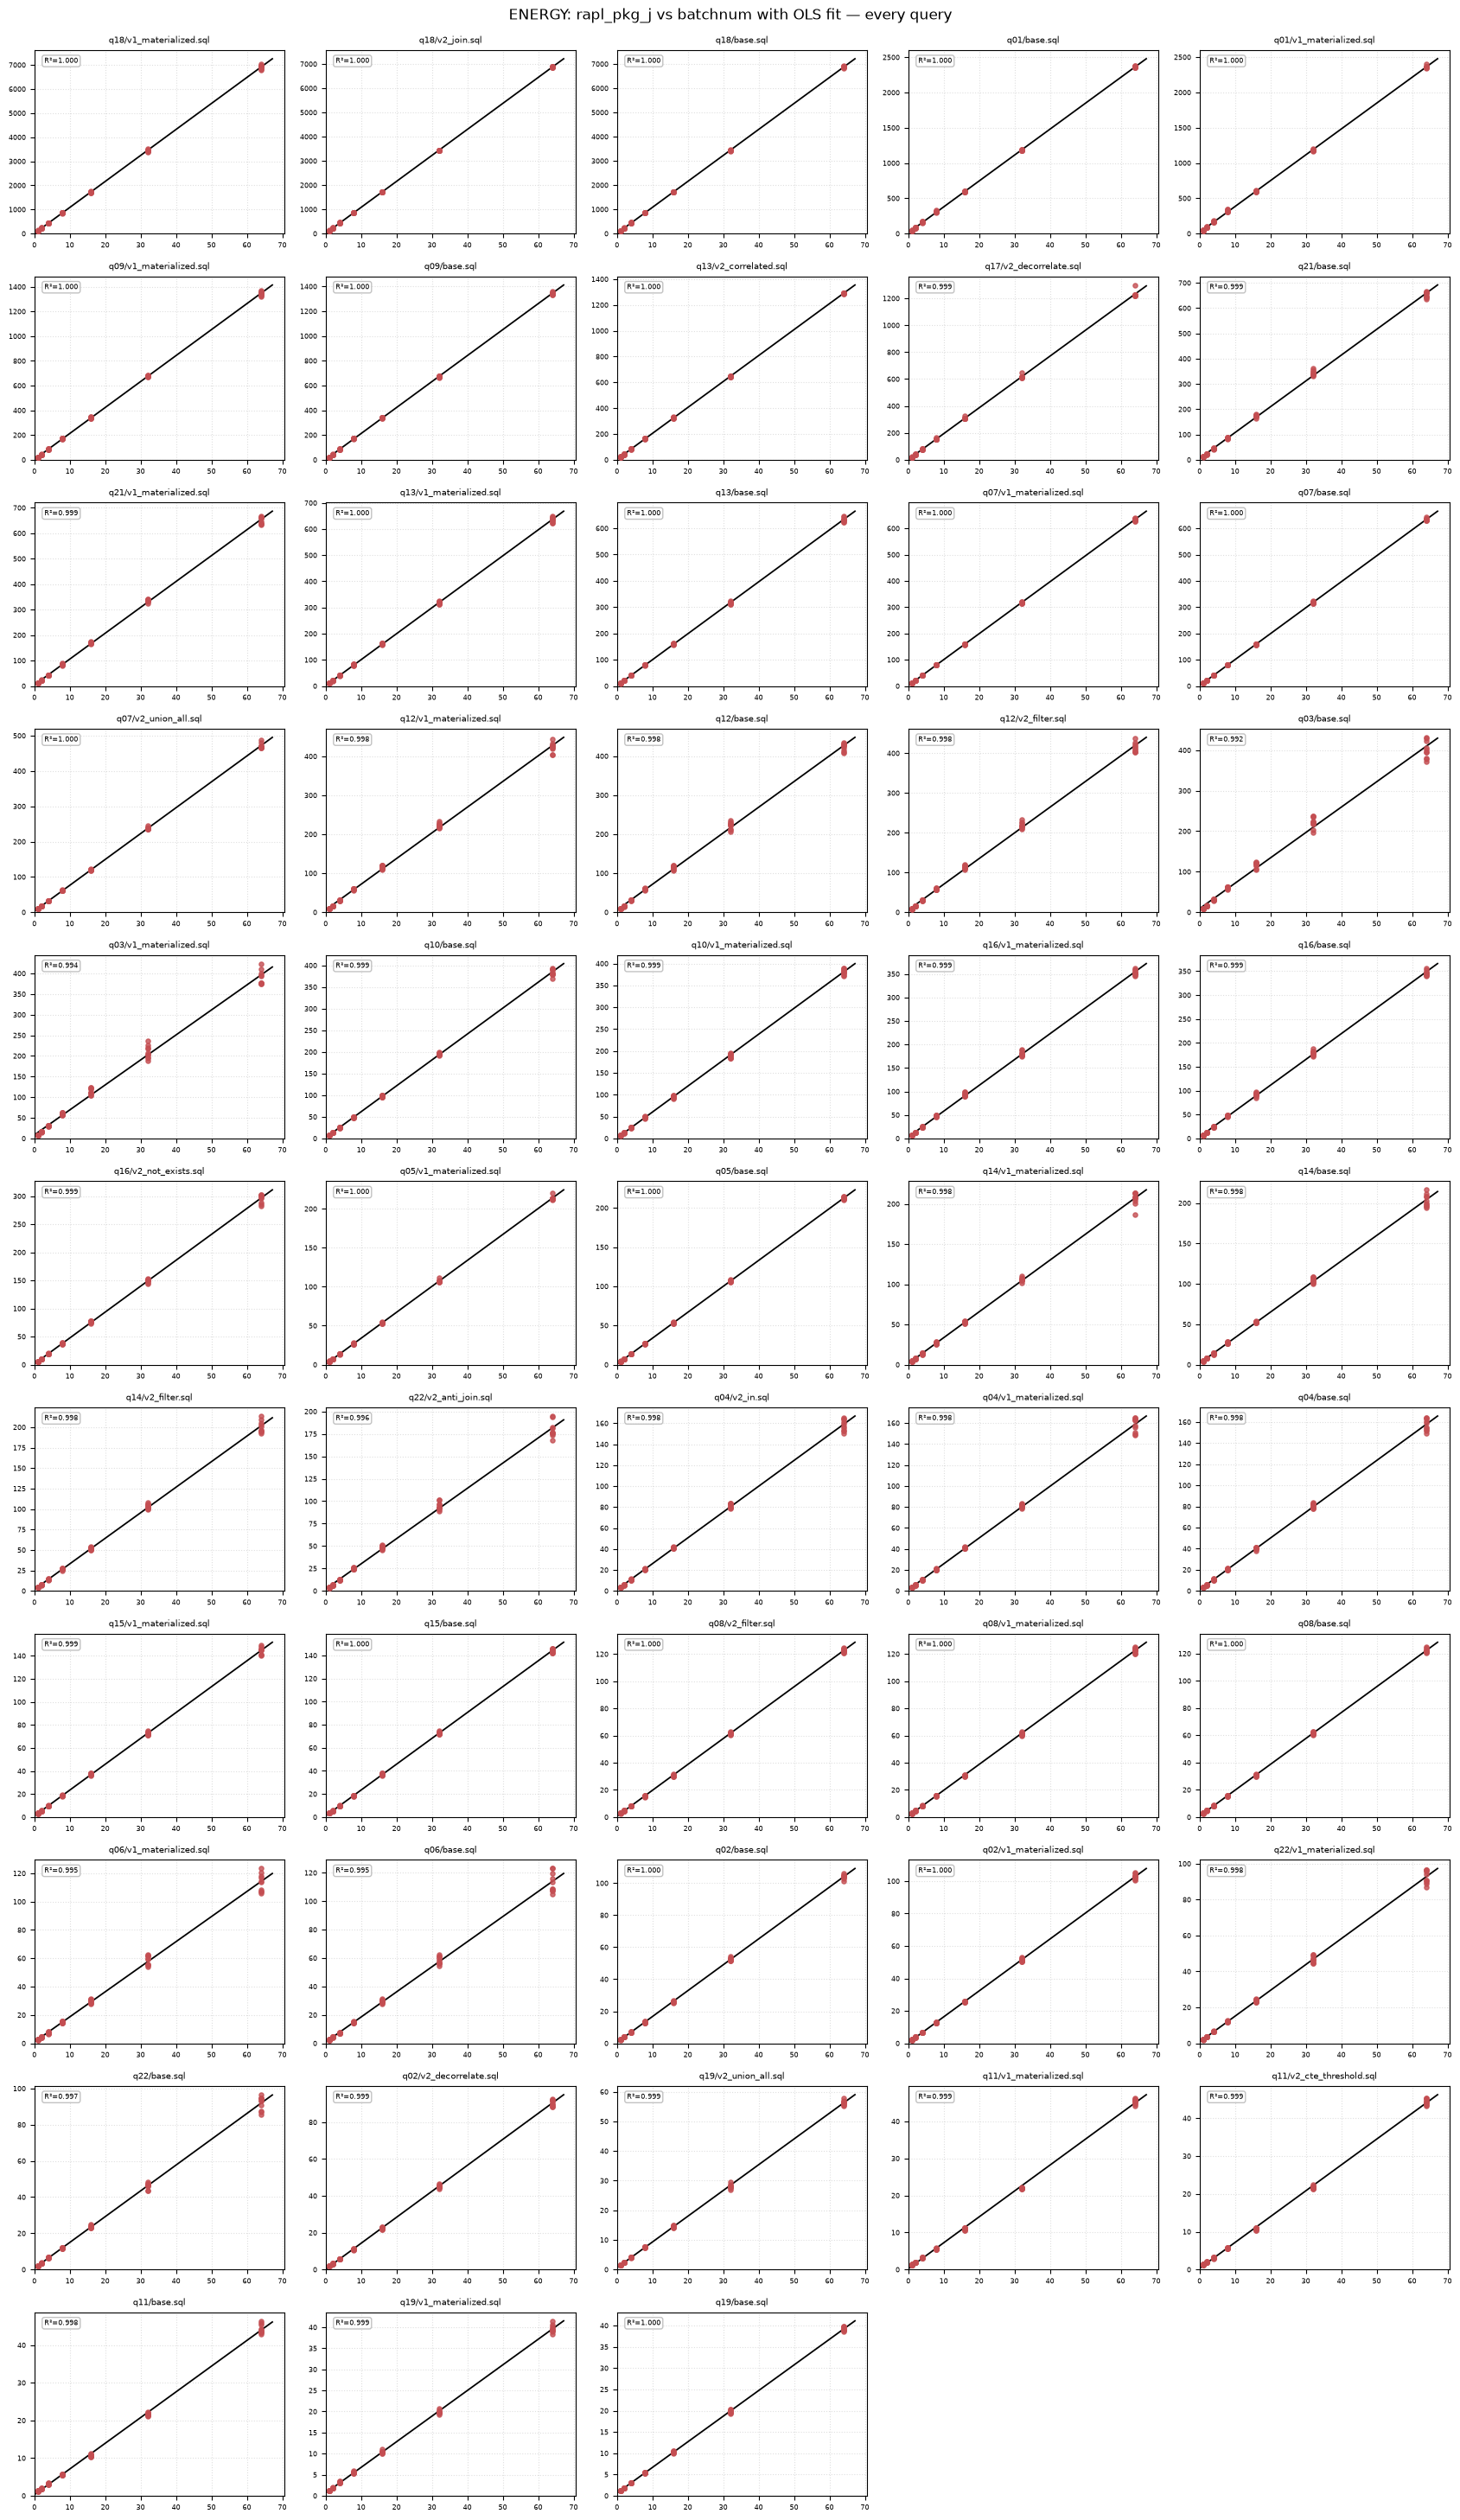

In [7]:
def draw_grid(fitdf, ycol, dot, title):
    order = fitdf.sort_values("slope", ascending=False)["qid"].tolist()
    ncols = 5
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.7))
    axes = np.atleast_1d(axes).ravel()
    xs = np.linspace(0, max(BATCH) * 1.05, 50)
    for ax, qid in zip(axes, order):
        d = measured[measured["qid"] == qid]
        r = fitdf[fitdf["qid"] == qid].iloc[0]
        ax.scatter(d["batchnum"], d[ycol], s=14, color=dot, alpha=0.8, zorder=3)
        ax.plot(xs, r["overhead"] + r["slope"] * xs, "k-", lw=1.3)
        ax.set_title(qid, fontsize=7)
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=6)
        ax.text(0.04, 0.96, f"R²={r['r2']:.3f}", transform=ax.transAxes,
                fontsize=6, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.8))
        ax.grid(linestyle=":", alpha=0.4)
    for ax in axes[len(order):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()


draw_grid(fit_t, "elapsed_sec", "#4c72b0",
          "RUNTIME: elapsed_sec vs batchnum with OLS fit — every query")
draw_grid(fit_e, "rapl_pkg_j", "#c44e52",
          "ENERGY: rapl_pkg_j vs batchnum with OLS fit — every query")


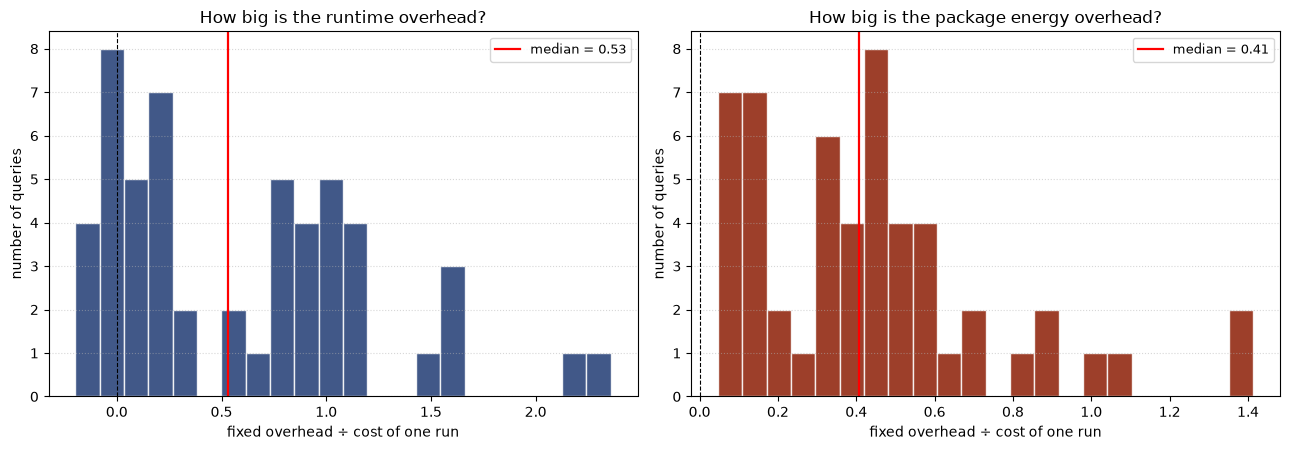

runtime: 8 queries have a small negative intercept; median R² = 0.9995
energy : 0 queries have a small negative intercept; median R² = 0.9994
per-run cost: runtime median 226.7 ms; energy median 3.33 J
overhead: runtime median 84.0 ms; energy median 1.36 J

Full fit table (sorted by runtime per-run cost):
                     qid  run_cost_ms  run_ovh_ms  run_r2  en_cost_j  en_ovh_j  en_r2
 q18/v1_materialized.sql       4931.6      -386.7  0.9998     107.87      5.03 0.9998
         q18/v2_join.sql       4900.5      -272.1  1.0000     107.24      8.54 1.0000
            q18/base.sql       4898.5      -221.1  1.0000     107.24      7.59 1.0000
  q17/v2_decorrelate.sql       3734.7       253.7  0.9995      19.21      2.03 0.9994
   q13/v2_correlated.sql       1799.1       192.7  1.0000      20.11      3.08 1.0000
 q01/v1_materialized.sql       1688.6      -334.1  0.9999      36.61     17.19 0.9998
            q01/base.sql       1685.7      -157.9  1.0000      36.72     11.00 0.9999
 q13/

In [8]:
# ---- summary: fixed overhead as a fraction of one run's cost (linear) ----
fit_t["ovh_frac"] = fit_t["overhead"] / fit_t["slope"]
fit_e["ovh_frac"] = fit_e["overhead"] / fit_e["slope"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (f, title, color) in zip(
        axes,
        [(fit_t, "runtime", "#1f3b73"), (fit_e, "package energy", "#8c1d04")]):
    vals = f["ovh_frac"].clip(-0.5, 2.5)
    ax.hist(vals, bins=22, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.axvline(f["ovh_frac"].median(), color="red", lw=1.6,
               label=f"median = {f['ovh_frac'].median():.2f}")
    ax.set_xlabel("fixed overhead ÷ cost of one run")
    ax.set_ylabel("number of queries")
    ax.set_title(f"How big is the {title} overhead?")
    ax.grid(axis="y", linestyle=":", alpha=0.5); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"runtime: {(fit_t['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_t['r2'].median():.4f}")
print(f"energy : {(fit_e['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_e['r2'].median():.4f}")
print(f"per-run cost: runtime median {fit_t['slope'].median()*1000:.1f} ms; "
      f"energy median {fit_e['slope'].median():.2f} J")
print(f"overhead: runtime median {fit_t['overhead'].median()*1000:.1f} ms; "
      f"energy median {fit_e['overhead'].median():.2f} J")

comb = fit_t[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "run_cost_s", "overhead": "run_ovh_s", "r2": "run_r2"})
comb = comb.merge(fit_e[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "en_cost_j", "overhead": "en_ovh_j", "r2": "en_r2"}), on="qid")
comb["run_cost_ms"] = (comb["run_cost_s"] * 1000).round(1)
comb["run_ovh_ms"] = (comb["run_ovh_s"] * 1000).round(1)
comb["en_cost_j"] = comb["en_cost_j"].round(2)
comb["en_ovh_j"] = comb["en_ovh_j"].round(2)
comb["run_r2"] = comb["run_r2"].round(4)
comb["en_r2"] = comb["en_r2"].round(4)
print("\nFull fit table (sorted by runtime per-run cost):")
print(comb.sort_values("run_cost_ms", ascending=False)[
    ["qid", "run_cost_ms", "run_ovh_ms", "run_r2",
     "en_cost_j", "en_ovh_j", "en_r2"]].to_string(index=False))


## 6. Fit residuals vs `batchnum` — relative (% of fitted)

Sections 6–6d are the residual diagnostics for the §5 fits. **§6** and **§6b**
plot the residual against `batchnum`; **§6c** and **§6d** plot it against the
run's fitted **time** (seconds) — a common axis for both metrics. Each pair comes
in a **relative** (% of fitted) and an **absolute** (raw s / J) flavour.

A straight line is only the right model if its **residuals** (`observed −
fitted`) are unstructured. Here we take every measured point, subtract the
per-query fit from §5, and express the residual as a **percentage of the fitted
value** so all queries — which span several orders of magnitude per run — sit on
the same axis. We do this for runtime and package energy.

Reading the plot: points scattered symmetrically around **0** at every batch
size means the line fits well; a consistent **curve** (e.g. all-positive at the
ends and negative in the middle, or vice-versa) would signal that cost is *not*
quite linear in `batchnum`; and a **funnel** that narrows as `batchnum` grows is
the same noise-averaging effect seen in the variance sections. The box shows the
inter-quartile range per batch size (whiskers 5–95%), with the raw points
jittered behind it.


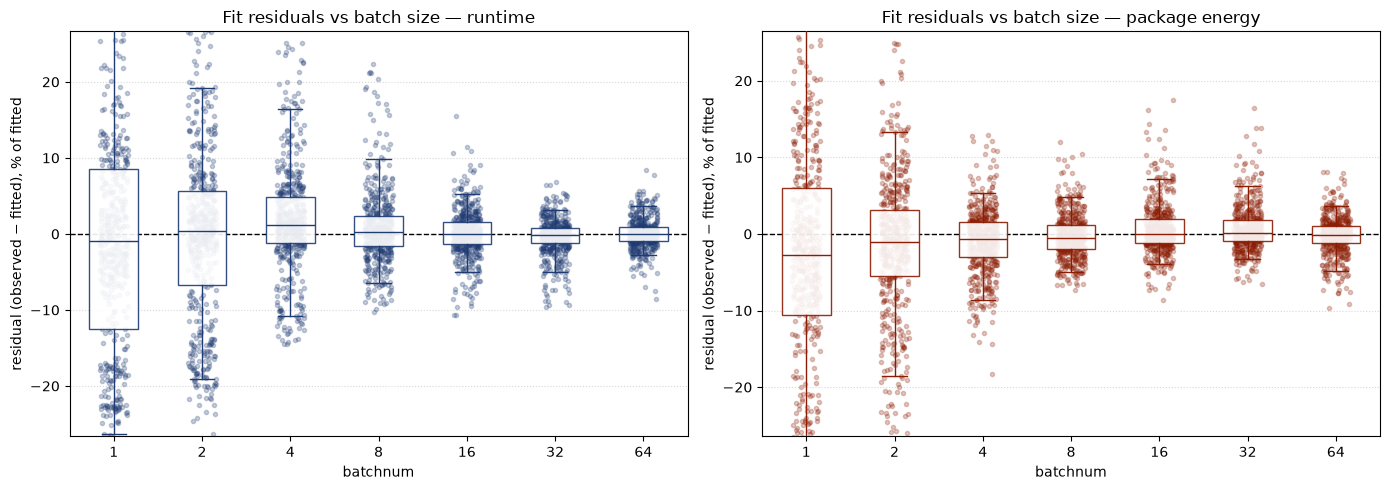

Median residual (% of fitted) by batch size — a systematic sign here would mean the fit is slightly non-linear:
          runtime_%  energy_%
batchnum                     
1             -0.92     -2.74
2              0.39     -1.00
4              1.24     -0.62
8              0.23     -0.52
16            -0.02      0.02
32            -0.14      0.08
64            -0.01     -0.09

Residual spread (std of % residual) by batch size:
          runtime_%  energy_%
batchnum                     
1             18.62     17.21
2             11.54      9.02
4              7.30      4.33
8              5.22      2.91
16             3.15      3.35
32             2.43      2.95
64             1.97      2.49


In [9]:
rng = np.random.default_rng(0)


def residual_frame(fitdf, ycol):
    f = fitdf.set_index("qid")
    d = measured.dropna(subset=[ycol]).copy()
    d = d[d["qid"].isin(f.index)]
    yhat = (f.loc[d["qid"], "overhead"].to_numpy()
            + f.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    d["yhat"] = yhat
    d["rel_resid_pct"] = 100 * (d[ycol] - d["yhat"]) / d["yhat"]
    return d


res_t = residual_frame(fit_t, "elapsed_sec")
res_e = residual_frame(fit_e, "rapl_pkg_j")
pos = {b: i for i, b in enumerate(BATCH)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (res, title, color) in zip(
        axes, [(res_t, "runtime", "#1f3b73"),
                (res_e, "package energy", "#8c1d04")]):
    xi = res["batchnum"].map(pos).to_numpy(float)
    ax.scatter(xi + rng.uniform(-0.16, 0.16, len(xi)), res["rel_resid_pct"],
               s=9, color=color, alpha=0.25, zorder=2)
    box = [res.loc[res["batchnum"] == b, "rel_resid_pct"].values for b in BATCH]
    bp = ax.boxplot(box, positions=range(len(BATCH)), widths=0.55,
                    whis=(5, 95), showfliers=False, patch_artist=True, zorder=3)
    for patch in bp["boxes"]:
        patch.set(facecolor="white", edgecolor=color, alpha=0.9)
    for el in ("whiskers", "caps", "medians"):
        for ln in bp[el]:
            ln.set_color(color)
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xticks(range(len(BATCH))); ax.set_xticklabels(BATCH)
    lim = float(np.nanpercentile(np.abs(res["rel_resid_pct"]), 97))
    ax.set_ylim(-lim * 1.1, lim * 1.1)
    ax.set_xlabel("batchnum")
    ax.set_ylabel("residual (observed − fitted), % of fitted")
    ax.set_title(f"Fit residuals vs batch size — {title}")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Median residual (% of fitted) by batch size — a systematic sign here "
      "would mean the fit is slightly non-linear:")
tab = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].median(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].median(),
}).round(2)
print(tab.to_string())
print("\nResidual spread (std of % residual) by batch size:")
tab2 = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].std(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].std(),
}).round(2)
print(tab2.to_string())


## 6b. Fit residuals vs `batchnum` — absolute (raw s / J)

The same residuals as §6, but in their **raw units** — `observed − fitted` in
**seconds** (runtime) and **joules** (energy) — so you see the actual size of the
miss, not just its relative size. Because queries span 3+ orders of magnitude (a
tiny query's residuals are milliseconds, `q02`'s are seconds) the y-axis is
**symlog** (linear near zero, log further out), the only way to show both scales
while keeping the sign. Note the box **grows** with `batchnum` here, the opposite
of the §6 percentage view — a bigger batch is simply a bigger number, the
magnitude effect §9 pins down.


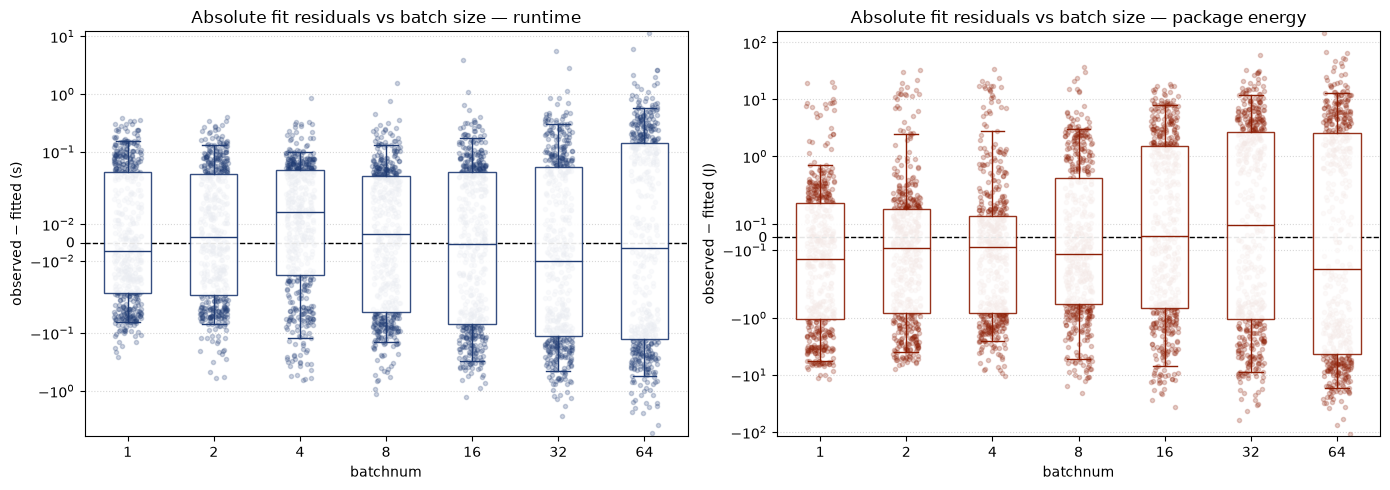

Absolute residual size (median |observed − fitted|) by batch size — grows with the batch because the whole-batch value grows:
          runtime |resid| (s)  energy |resid| (J)
batchnum                                         
1                      0.0321              0.4279
2                      0.0336              0.3447
4                      0.0343              0.3985
8                      0.0389              0.5452
16                     0.0522              1.0482
32                     0.0761              1.7364
64                     0.1371              3.4490


In [10]:
ar_t = res_t.assign(abs_resid=res_t["elapsed_sec"] - res_t["yhat"])   # seconds
ar_e = res_e.assign(abs_resid=res_e["rapl_pkg_j"] - res_e["yhat"])    # joules

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ar, title, color, unit) in zip(
        axes, [(ar_t, "runtime", "#1f3b73", "s"),
                (ar_e, "package energy", "#8c1d04", "J")]):
    xi = ar["batchnum"].map(pos).to_numpy(float)
    ax.scatter(xi + rng.uniform(-0.16, 0.16, len(xi)), ar["abs_resid"],
               s=9, color=color, alpha=0.22, zorder=2)
    box = [ar.loc[ar["batchnum"] == b, "abs_resid"].values for b in BATCH]
    bp = ax.boxplot(box, positions=range(len(BATCH)), widths=0.55,
                    whis=(5, 95), showfliers=False, patch_artist=True, zorder=3)
    for patch in bp["boxes"]:
        patch.set(facecolor="white", edgecolor=color, alpha=0.9)
    for el in ("whiskers", "caps", "medians"):
        for ln in bp[el]:
            ln.set_color(color)
    ax.axhline(0, color="k", lw=1.0, ls="--")
    lt = float(np.nanpercentile(np.abs(ar["abs_resid"]), 40)) or 1e-4
    ax.set_yscale("symlog", linthresh=lt)
    ax.set_xticks(range(len(BATCH))); ax.set_xticklabels(BATCH)
    ax.set_xlabel("batchnum")
    ax.set_ylabel(f"observed − fitted ({unit})")
    ax.set_title(f"Absolute fit residuals vs batch size — {title}")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Absolute residual size (median |observed − fitted|) by batch size — "
      "grows with the batch because the whole-batch value grows:")
tab = pd.DataFrame({
    "runtime |resid| (s)": ar_t.assign(a=ar_t["abs_resid"].abs())
        .groupby("batchnum")["a"].median(),
    "energy |resid| (J)": ar_e.assign(a=ar_e["abs_resid"].abs())
        .groupby("batchnum")["a"].median(),
}).round(4)
print(tab.to_string())


## 6c. Fit residuals vs the run's time — relative (% of fitted)

Now the x-axis is the run's **fitted whole-batch time** (seconds) rather than the
discrete `batchnum` — and the **same time axis is used for both panels**, so the
runtime- and energy-residuals line up against how long the run took (energy uses
fitted time, not fitted joules, on x). Each point is one measured batch, coloured
by `batchnum`; time is on a log x-axis because it spans orders. A flat, symmetric
band around **0** means the relative error is time-independent; a funnel narrowing
to the right would mean longer runs are relatively tighter.


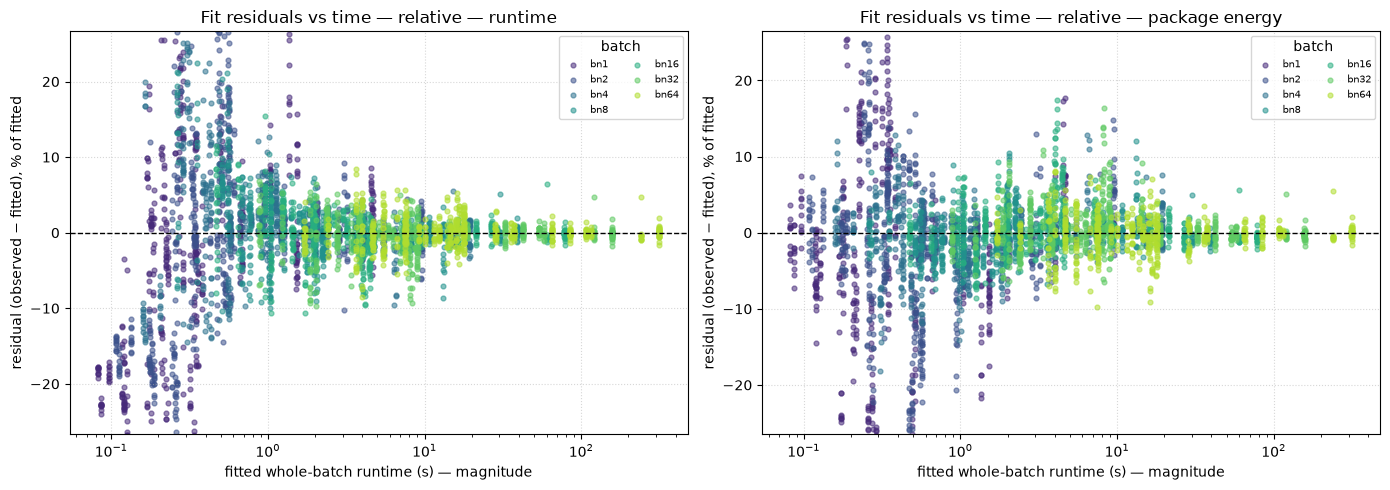

In [11]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
ft = fit_t.set_index("qid")     # fitted runtime supplies the common time x-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (res, title) in zip(
        axes, [(res_t, "runtime"), (res_e, "package energy")]):
    d = res.copy()
    d["mag_s"] = (ft.loc[d["qid"], "overhead"].to_numpy()
                  + ft.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    d = d[d["mag_s"] > 0]
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["mag_s"], s["rel_resid_pct"], s=12, color=colB[j],
                   alpha=0.55, label=f"bn{b}")
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xscale("log")
    lim = float(np.nanpercentile(np.abs(d["rel_resid_pct"]), 97))
    ax.set_ylim(-lim * 1.1, lim * 1.1)
    ax.set_xlabel("fitted whole-batch runtime (s) — magnitude")
    ax.set_ylabel("residual (observed − fitted), % of fitted")
    ax.set_title(f"Fit residuals vs time — relative — {title}")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=7, title="batch", ncol=2)
fig.tight_layout(); plt.show()


## 6d. Fit residuals vs the run's time — absolute (raw s / J)

The same as §6c but in raw units, with a **symlog** y-axis, again against the
run's fitted **time** (seconds) on both panels. This is the direct picture of
**heteroscedasticity**: if the cloud fans out to the right, the absolute error
grows with how long the run takes. The printed slope is `log|residual|` regressed
on `log(fitted time)` — a value near 1 means the absolute error is roughly
proportional to run time (constant relative error), the same conclusion §9
reaches for the variance.


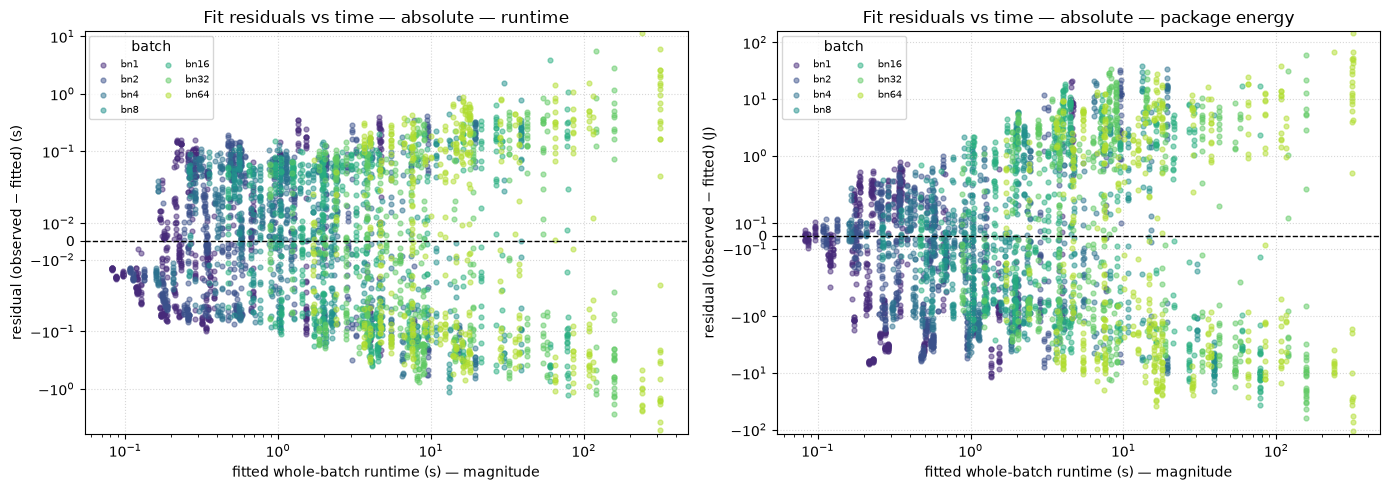

Heteroscedasticity slope  d(log|residual|)/d(log fitted-time)  (~1 = absolute error proportional to run time):
  runtime: 0.42
  energy: 0.59


In [12]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
ft = fit_t.set_index("qid")     # fitted runtime supplies the common time x-axis


def _with_time(ar):
    d = ar.copy()
    d["mag_s"] = (ft.loc[d["qid"], "overhead"].to_numpy()
                  + ft.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    return d[d["mag_s"] > 0]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ar, title, unit) in zip(
        axes, [(ar_t, "runtime", "s"), (ar_e, "package energy", "J")]):
    d = _with_time(ar)
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["mag_s"], s["abs_resid"], s=12, color=colB[j],
                   alpha=0.5, label=f"bn{b}")
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xscale("log")
    lt = float(np.nanpercentile(np.abs(d["abs_resid"]), 40)) or 1e-4
    ax.set_yscale("symlog", linthresh=lt)
    ax.set_xlabel("fitted whole-batch runtime (s) — magnitude")
    ax.set_ylabel(f"residual (observed − fitted) ({unit})")
    ax.set_title(f"Fit residuals vs time — absolute — {title}")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=7, title="batch", ncol=2)
fig.tight_layout(); plt.show()

print("Heteroscedasticity slope  d(log|residual|)/d(log fitted-time)  "
      "(~1 = absolute error proportional to run time):")
for ar, name in [(ar_t, "runtime"), (ar_e, "energy")]:
    d = _with_time(ar)
    x = np.log10(d["mag_s"].to_numpy())
    y = np.log10(d["abs_resid"].abs().replace(0, np.nan).to_numpy())
    ok = np.isfinite(x) & np.isfinite(y)
    slope = np.polyfit(x[ok], y[ok], 1)[0]
    print(f"  {name}: {slope:.2f}")


## 7. Variance vs test length — does runtime drive the noise?

Each point is one `(query, batchnum)`: its **per-copy CV%** (the run-to-run
spread from §3) on the y-axis against the **mean per-copy runtime** — the test
length — on the x-axis, coloured by `batchnum`. **Energy is an outcome**, so its
variance is also shown against **runtime**, not against energy: the right panel is
energy CV vs runtime. This asks whether the fast, tiny queries are the noisy ones
(fixed timer / scheduling jitter being a big fraction of a small number) while the
long queries are relatively steady. The x-axis is clipped to the bulk so the
dense region is readable — a few very long queries sit far right with low CV and
are off-scale by design.


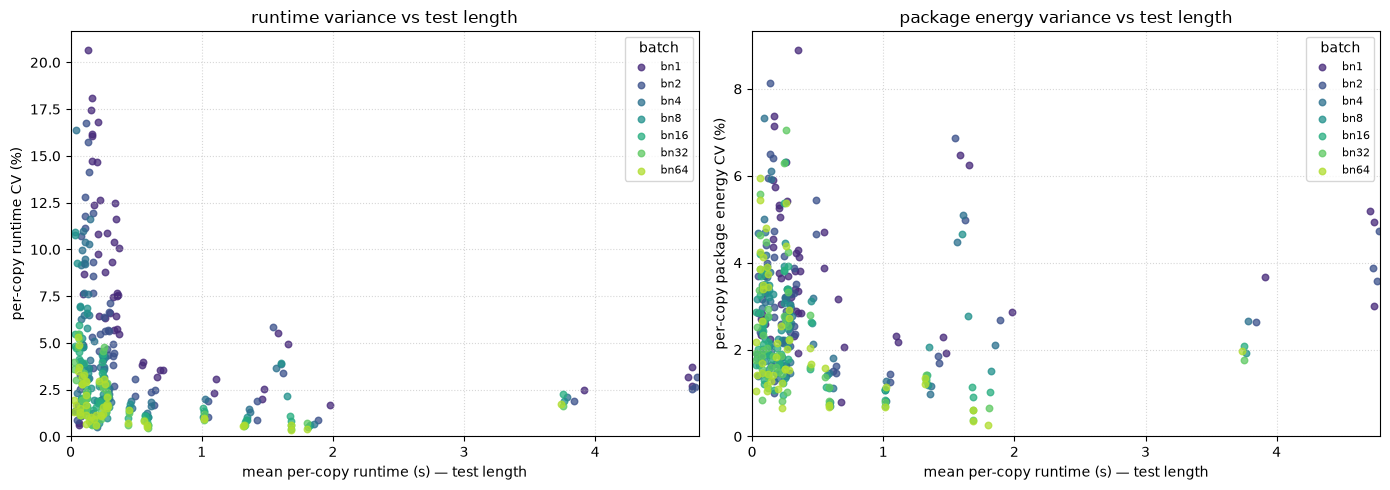

At batchnum=1, shortest third of queries: median runtime CV 11.6%; longest third: 3.4%.
Correlation with per-copy runtime (all points): runtime CV -0.27, energy CV -0.19


In [13]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
size = var_t[["qid", "batchnum", "mean"]].rename(columns={"mean": "runtime_s"})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (v, title) in zip(axes, [(var_t, "runtime"), (var_e, "package energy")]):
    d = v.merge(size, on=["qid", "batchnum"])
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["runtime_s"], s["cv_pct"], s=22, color=colB[j], alpha=0.75,
                   label=f"bn{b}")
    ax.set_xlim(0, float(np.nanpercentile(d["runtime_s"], 96)))
    ax.set_ylim(bottom=0)
    ax.set_xlabel("mean per-copy runtime (s) — test length")
    ax.set_ylabel(f"per-copy {title} CV (%)")
    ax.set_title(f"{title} variance vs test length")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8, title="batch")
fig.tight_layout(); plt.show()

# shortest vs longest tertiles at batchnum=1 (by runtime length)
b1 = var_t[var_t["batchnum"] == 1].dropna(subset=["mean", "cv_pct"])
q33, q67 = b1["mean"].quantile([1/3, 2/3])
short = b1[b1["mean"] <= q33]["cv_pct"].median()
long_ = b1[b1["mean"] >= q67]["cv_pct"].median()
print(f"At batchnum=1, shortest third of queries: median runtime CV {short:.1f}%; "
      f"longest third: {long_:.1f}%.")
ce = var_e.merge(size, on=["qid", "batchnum"])
print("Correlation with per-copy runtime (all points): "
      f"runtime CV {np.corrcoef(var_t['mean'].fillna(0), var_t['cv_pct'].fillna(0))[0,1]:+.2f}, "
      f"energy CV {np.corrcoef(ce['runtime_s'].fillna(0), ce['cv_pct'].fillna(0))[0,1]:+.2f}")


## 8. Variance vs `batchnum` — absolute spread

§3 showed the *relative* spread (CV%). This shows the **absolute** per-copy
standard deviation and how it collapses as the batch grows: the median per-copy
std across queries with the inter-quartile band and every query as a faint line.
Evenly-spaced batch ticks, linear y (clipped to the bulk so the median stays
readable). Units are seconds (runtime) and joules (energy) — the actual size of
the jitter you'd see on a single warm copy at each batch size.


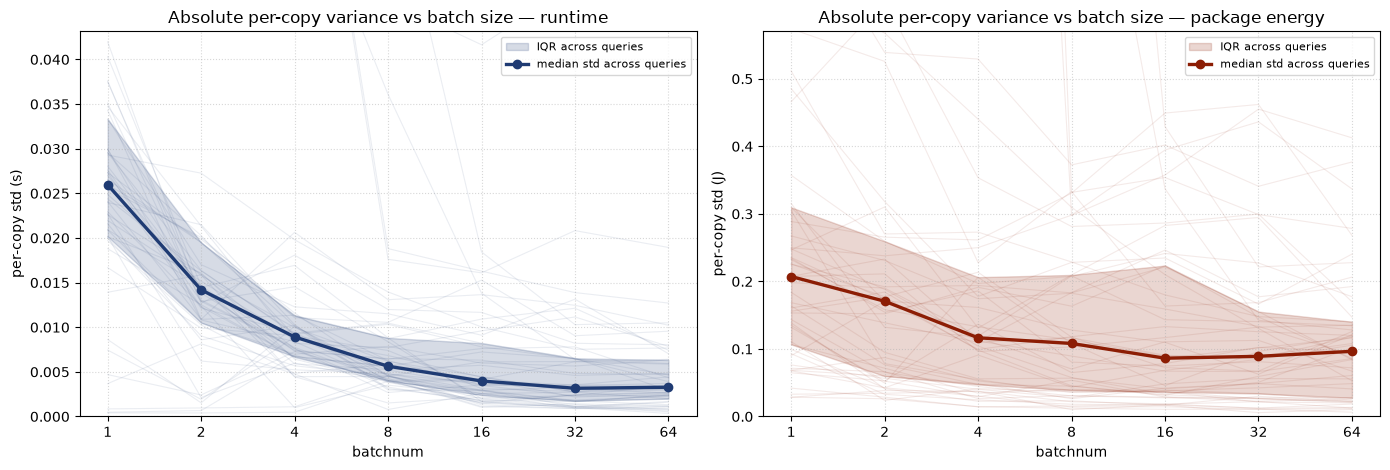

Median absolute per-copy std by batch size:
          runtime_std_s  energy_std_j
batchnum                             
1                0.0260        0.2073
2                0.0142        0.1707
4                0.0089        0.1165
8                0.0056        0.1081
16               0.0040        0.0863
32               0.0032        0.0891
64               0.0033        0.0965


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color, unit) in zip(
        axes, [(var_t, "runtime", "#1f3b73", "s"),
                (var_e, "package energy", "#8c1d04", "J")]):
    piv = v.pivot(index="qid", columns="batchnum", values="std").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    ax.fill_between(xpos, piv.quantile(0.25).values, piv.quantile(0.75).values,
                    color=color, alpha=0.18, label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median std across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_xlabel("batchnum")
    ax.set_ylabel(f"per-copy std ({unit})")
    ax.set_title(f"Absolute per-copy variance vs batch size — {title}")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median absolute per-copy std by batch size:")
tab = pd.DataFrame({
    "runtime_std_s": var_t.groupby("batchnum")["std"].median(),
    "energy_std_j": var_e.groupby("batchnum")["std"].median(),
}).round(4)
print(tab.to_string())


## 9. Does the variance come from test length (runtime) or from `batchnum`?

`batchnum` and runtime are the two things that vary here, and they are
confounded: a bigger batch simply takes longer, so "more variance at
`batchnum=16`" could just be "more variance because the run is 16× longer".
**Energy is an outcome, not a control**, so both the time-variance *and* the
energy-variance are explained against the same two candidates — **test length
(runtime)** and **`batchnum`** — and energy magnitude is never used as an x-axis.

Each point is one `(query, batchnum)`: the **mean whole-batch runtime** (test
length, x) against the **std of its repeats** (observed variance, y) — std of
**time** on the left, std of **energy** on the right, both against runtime.
Axes are log (values span ~4 orders), so the log-log slope is itself informative;
the grey lines on the runtime panel are constant-CV references.

The decisive number is the **partial correlation** printed below: the correlation
of the variance with `batchnum` *after removing test length*. If it is ≈ 0 (or
negative), `batchnum` adds nothing on its own — the variance rises only because
bigger batches run longer, and a bigger batch is if anything *relatively* quieter
because it averages more copies.


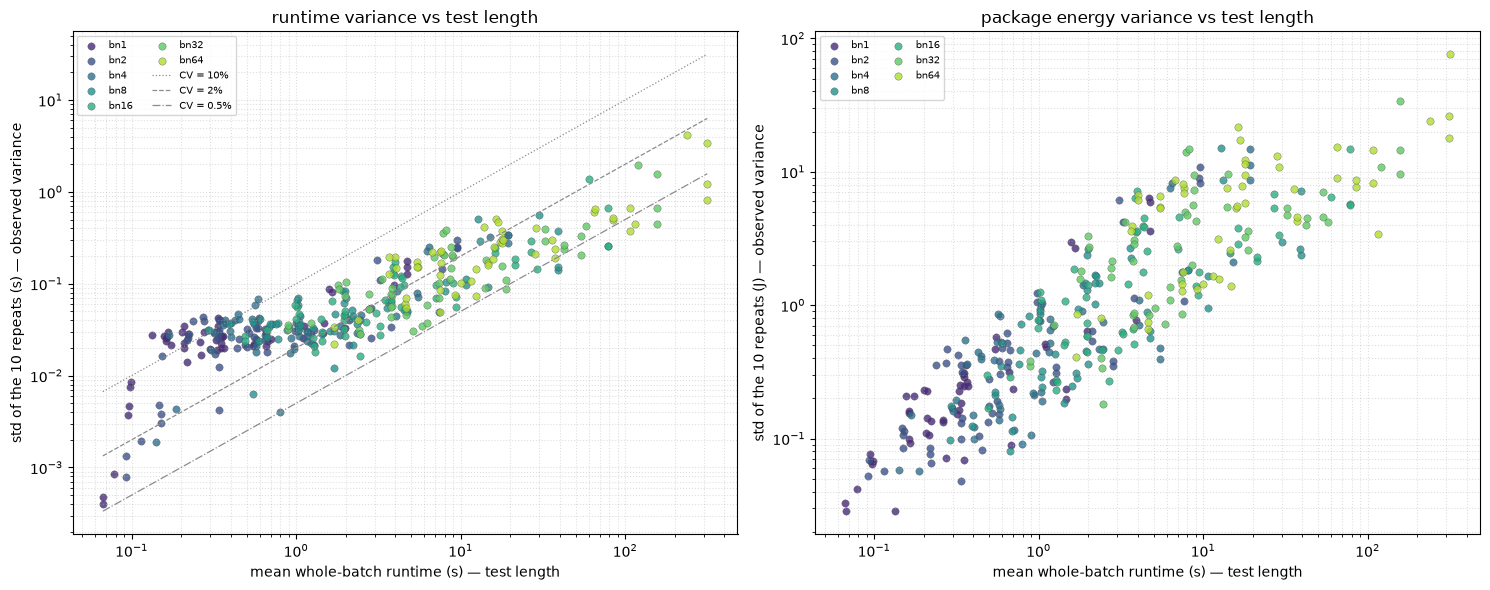

[runtime variance]  log-log slope vs test length = 0.62  (1.0 = variance proportional to run time)
          corr(variance, test length) = +0.87
          corr(variance, batchnum)    = +0.60
          PARTIAL corr(variance, batchnum | test length) = -0.06  <- batchnum's own effect once run time is held fixed
[energy variance]  log-log slope vs test length = 0.78  (1.0 = variance proportional to run time)
          corr(variance, test length) = +0.88
          corr(variance, batchnum)    = +0.66
          PARTIAL corr(variance, batchnum | test length) = +0.09  <- batchnum's own effect once run time is held fixed

Median CV(%) at each batchnum (relative spread of the outcome itself; falls as the batch averages more copies):
          runtime_cv%  energy_cv%
batchnum                         
1                6.46        3.66
2                4.28        2.99
4                2.99        2.54
8                2.35        2.07
16               1.68        1.89
32               1.37        1

In [15]:
mv = (measured.dropna(subset=["elapsed_sec"])
      .groupby(["qid", "batchnum"])
      .agg(mean_time=("elapsed_sec", "mean"), std_time=("elapsed_sec", "std"),
           mean_energy=("rapl_pkg_j", "mean"), std_energy=("rapl_pkg_j", "std"),
           n=("elapsed_sec", "count")).reset_index())
mv = mv[mv["n"] >= 2]
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (ycol, title, unit) in zip(
        axes, [("std_time", "runtime", "s"),
               ("std_energy", "package energy", "J")]):
    for j, b in enumerate(BATCH):
        s = mv[mv["batchnum"] == b]
        ax.scatter(s["mean_time"], s[ycol], s=28, color=colB[j], alpha=0.8,
                   edgecolor="0.3", linewidth=0.3, label=f"bn{b}")
    if ycol == "std_time":                         # constant-CV guides (time only)
        xs = np.array([mv["mean_time"].min(), mv["mean_time"].max()])
        for cv, ls in [(10, ":"), (2, "--"), (0.5, "-.")]:
            ax.plot(xs, cv / 100 * xs, color="0.55", lw=0.9, ls=ls,
                    label=f"CV = {cv:g}%")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("mean whole-batch runtime (s) — test length")
    ax.set_ylabel(f"std of the {NREP} repeats ({unit}) — observed variance")
    ax.set_title(f"{title} variance vs test length")
    ax.grid(which="both", linestyle=":", alpha=0.4)
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()


def drivers(ycol, name):
    m = np.log10(mv["mean_time"].to_numpy())               # test length
    s = np.log10(mv[ycol].replace(0, np.nan).to_numpy())   # variance (outcome)
    b = np.log10(mv["batchnum"].to_numpy())
    ok = np.isfinite(m) & np.isfinite(s) & np.isfinite(b)
    m, s, b = m[ok], s[ok], b[ok]
    slope = np.polyfit(m, s, 1)[0]

    def resid(y, x):
        a, c = np.polyfit(x, y, 1)
        return y - (a * x + c)
    pc = np.corrcoef(resid(s, m), resid(b, m))[0, 1]
    print(f"[{name} variance]  log-log slope vs test length = {slope:.2f}  "
          f"(1.0 = variance proportional to run time)")
    print(f"          corr(variance, test length) = {np.corrcoef(m, s)[0,1]:+.2f}")
    print(f"          corr(variance, batchnum)    = {np.corrcoef(b, s)[0,1]:+.2f}")
    print(f"          PARTIAL corr(variance, batchnum | test length) = {pc:+.2f}  "
          f"<- batchnum's own effect once run time is held fixed")


drivers("std_time", "runtime")
drivers("std_energy", "energy")
print("\nMedian CV(%) at each batchnum (relative spread of the outcome itself; "
      "falls as the batch averages more copies):")
mv["cv_time"] = 100 * mv["std_time"] / mv["mean_time"]
mv["cv_energy"] = 100 * mv["std_energy"] / mv["mean_energy"]
print(pd.DataFrame({
    "runtime_cv%": mv.groupby("batchnum")["cv_time"].median(),
    "energy_cv%": mv.groupby("batchnum")["cv_energy"].median(),
}).round(2).to_string())


## 10. How many tests are needed? Repeats × batch-set sensitivity

The 530-group run is deliberately over-sampled (10 repeats, 5 batch sizes). This
section asks **how much of it you actually need** to recover the two fit
parameters — the **energy slope** (the per-run energy cost, the headline number)
and, secondarily, the **overhead** — plus the runtime slope as a cross-check.

Method: the **full design** (all repeats × all 5 batch sizes) is taken as ground
truth. For every candidate design — `R` repeats × a subset of the batch sizes —
we refit each query's line and measure the **relative error of its slope vs the
full-design slope**, then take the **median across queries**. To remove "which
repeats you happened to pick" from the answer, each cell is averaged **exactly
over all `C(10,R)` ways** of choosing the `R` repeats (no random sampling).
Because every choice is enumerated, we also report the **standard deviation
across those `C(10,R)` choices** — how much the accuracy depends on *which*
repeats you happen to use (it shrinks as `R` grows, and is exactly 0 at `R=10`
where only one choice exists).

There is **one heatmap per metric** (energy slope, energy overhead, runtime
slope), all on the **same colour scale** so they are directly comparable, and
each saved as an **SVG in `./figures/`**. Every cell shows three lines: the
accuracy `mean ± std` (%, two decimals); the **per-query run count**
(`runs/q` — executions for one query, warm-ups included); and the **estimated
per-query wall time** (`~t/q` — the run's `summary.txt` average seconds per full
group, scaled by repeats and by the batch set's copy count). Both costs are
**per single query**: the query count can change run-to-run, but the per-query
cost is the stable planning number.

The tables/heatmaps have **rows = batch set** and **columns = number of
repeats**, so the top row (all batch sizes) answers "how many repeats?" and the
last column (all repeats) answers "how few batch sizes?". Overhead is reported
as a % of **one run's cost** (its natural scale — it is often near zero, so a
plain relative error would explode).

**Batch-size cap (`BATCH_MAX`).** A run may sweep beyond `batchnum=16` (the latest
tpch_idx run goes to 64). Everything from here on uses only batch sizes
`≤ BATCH_MAX`, set at the top of the next cell — `16` keeps `{1,2,4,8,16}`, `32`
also admits 32, `64` also admits 64, and the candidate batch sets are generated to
match. Wall-time (`~t/q`) is still normalised by the run's **real** full group
(all sizes it actually swept), so time estimates stay correct when the cap drops
the largest sizes. §3–§9 above are unaffected and show the full sweep.


experiment-design analysis (§10+) uses batchnum <= 64: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]


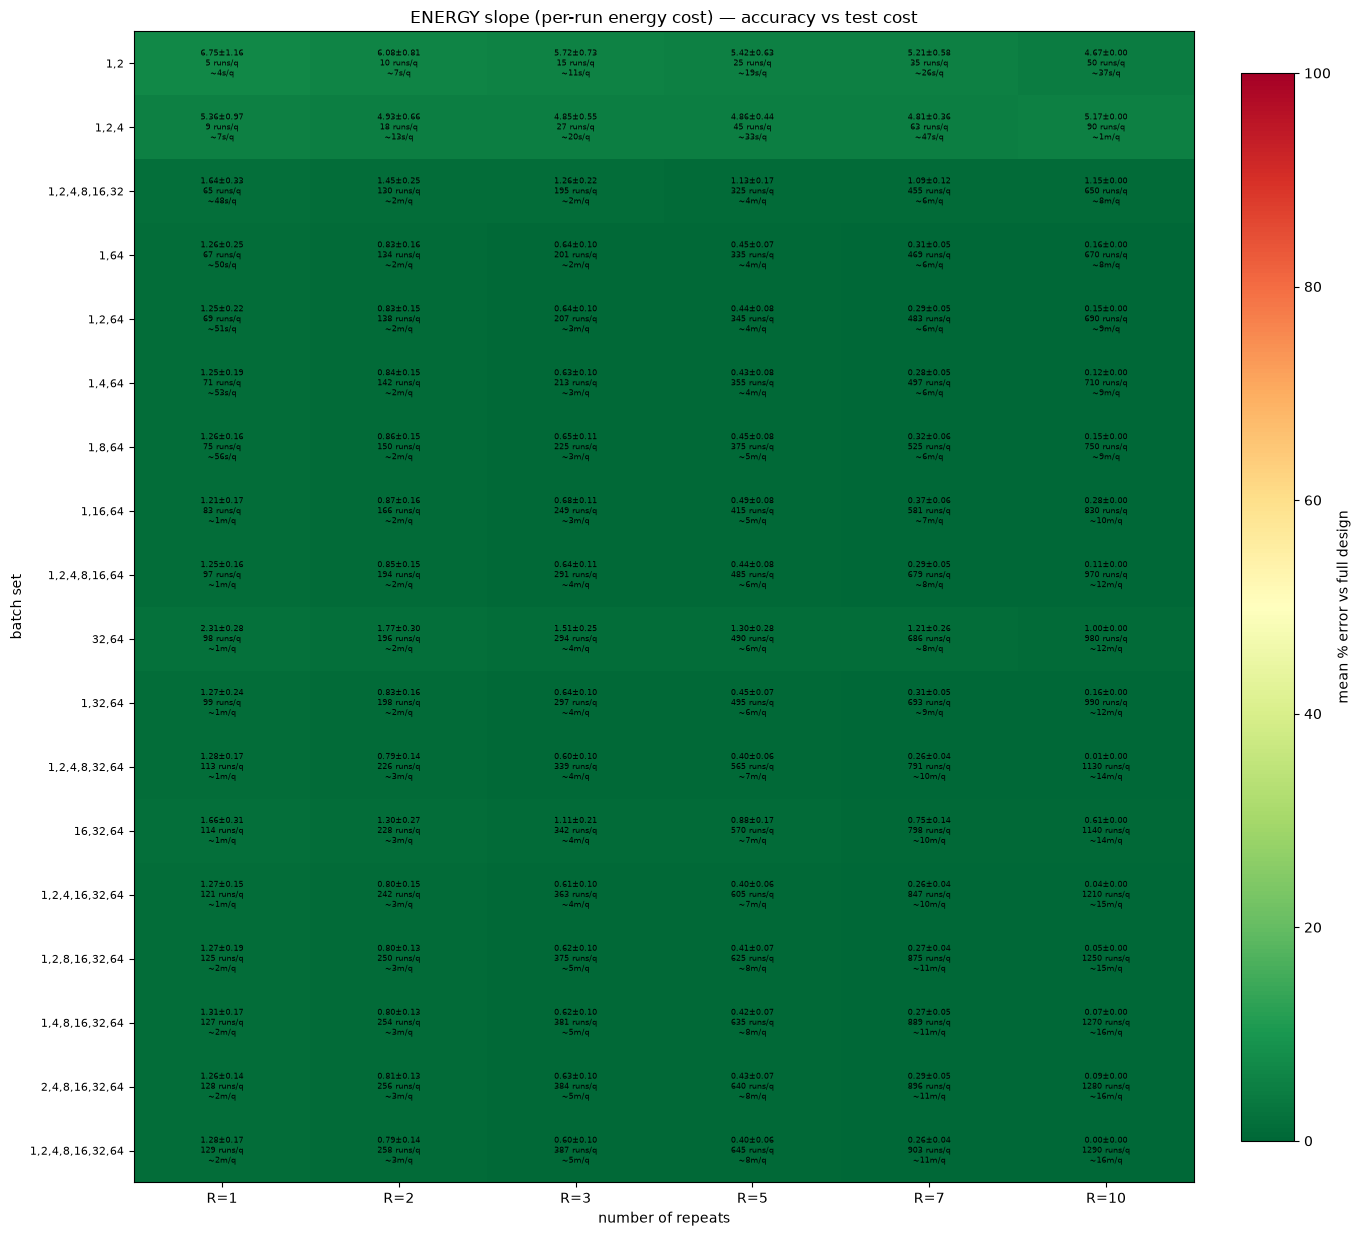

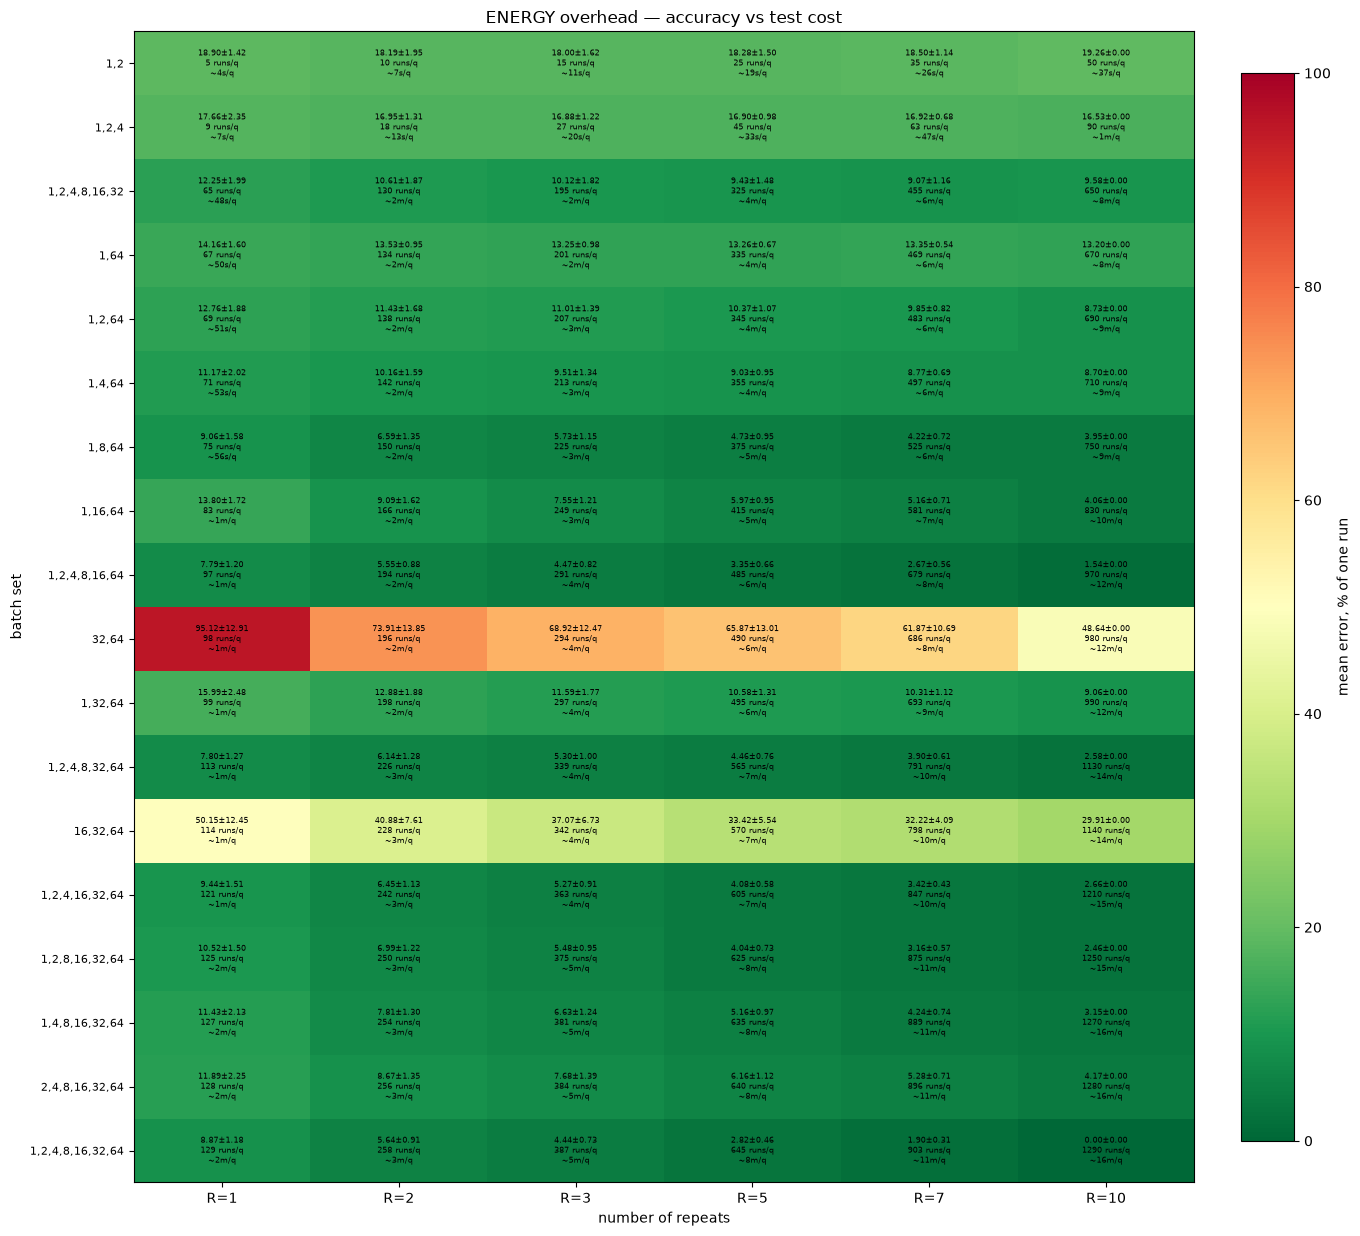

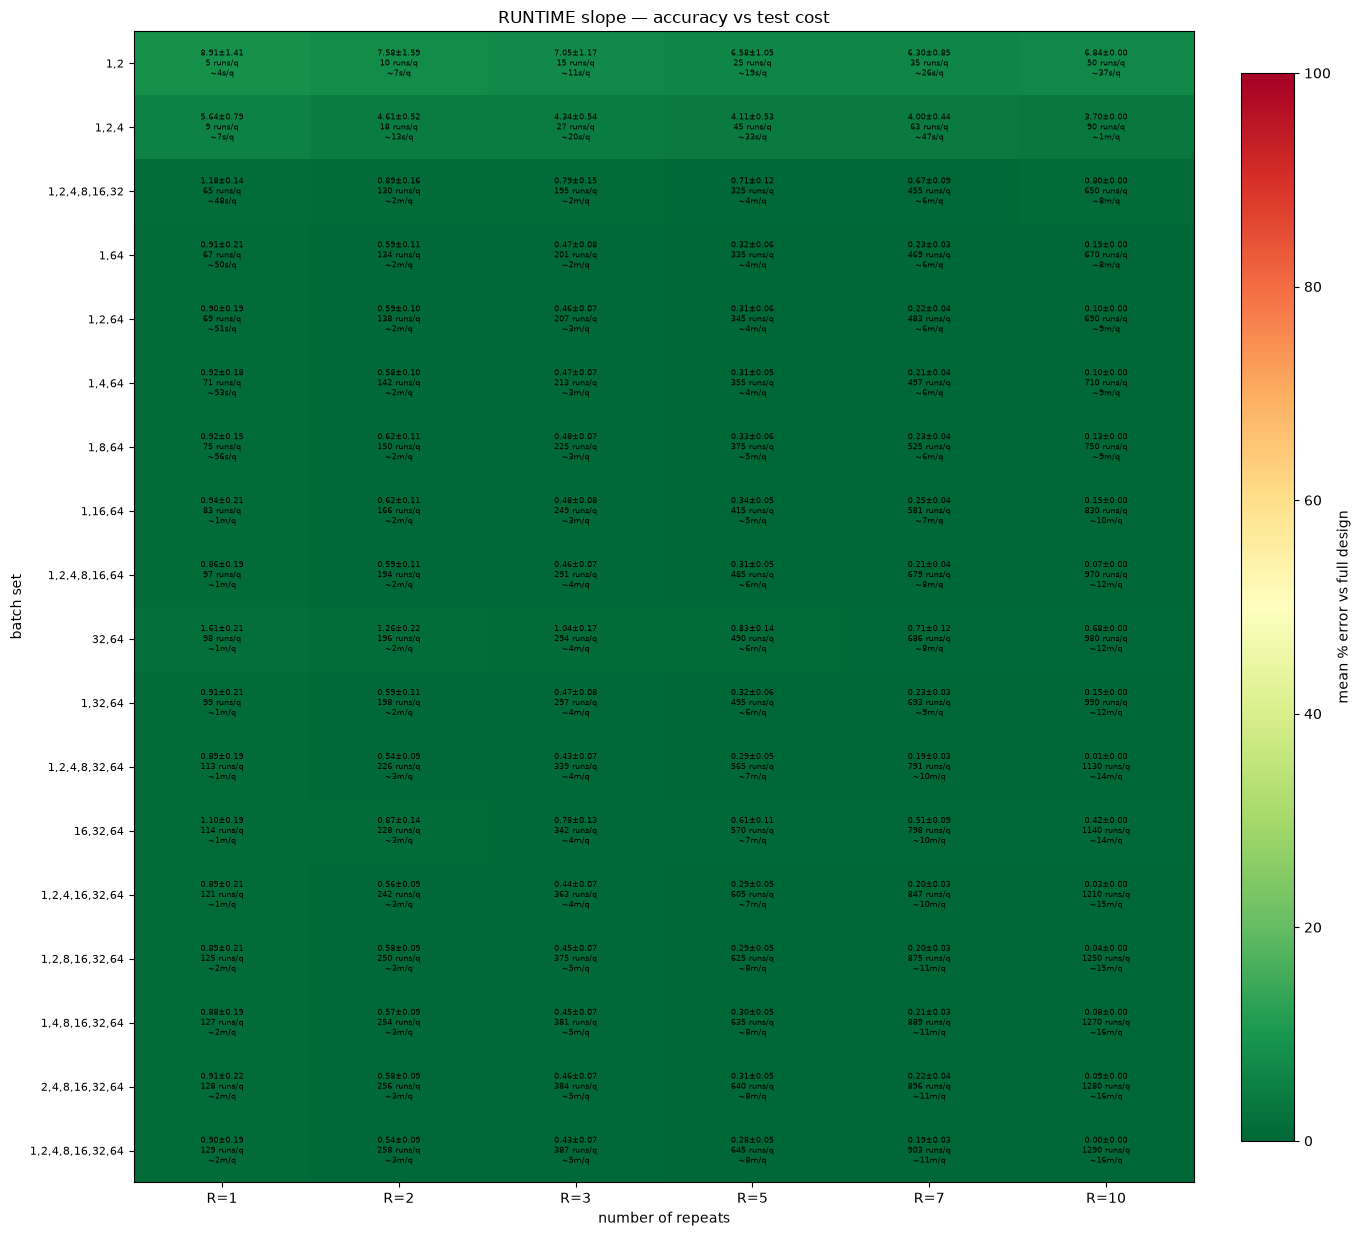

Saved 3 SVGs to 'figures/' (shared colour scale 0-100).
Ground truth = full design (10 repeats x 7 batch sizes).
Queries with a complete cube: energy 49/53, runtime 53/53.
Cost model: 2 warm-ups + batch copies per group; 95.5s per full group (from summary.txt). 'runs/q' and '~t/q' are per SINGLE query (this run has 53); per-query cost is the query-count-agnostic planning number.

Each cell below is the MEAN over all C(10,R) repeat choices; the matching
std table is the spread ACROSS those choices (how much it depends on WHICH
repeats you pick — it shrinks as R grows and is 0 at R=10, the only choice).

=== ENERGY slope — mean relative error vs full design (%) ===
                   R=1   R=2   R=3   R=5   R=7  R=10
1,2               6.75  6.08  5.72  5.42  5.21  4.67
1,2,4             5.36  4.93  4.85  4.86  4.81  5.17
1,2,4,8,16,32     1.64  1.45  1.26  1.13  1.09  1.15
1,64              1.26  0.83  0.64  0.45  0.31  0.16
1,2,64            1.25  0.83  0.64  0.44  0.29  0.15
1,4,64    

In [16]:
import itertools

# ---------------------------------------------------------------------------
# Upper batchnum for the experiment-design analysis (§10 onward). The selected
# run may sweep beyond 16 (e.g. 1..64); cap which sizes this half of the
# notebook uses.  16 -> {1,2,4,8,16};  32 also uses 32;  64 also uses 64; etc.
BATCH_MAX = 64
# ---------------------------------------------------------------------------
BATCH_FULL = list(BATCH)                       # the run's actual sweep (wall-time)
BATCH = [b for b in BATCH_FULL if b <= BATCH_MAX]
print(f"experiment-design analysis (§10+) uses batchnum <= {BATCH_MAX}: {BATCH}")
if BATCH_FULL != BATCH:
    print(f"   (the selected run actually swept {BATCH_FULL}; "
          f"sizes > {BATCH_MAX} are excluded from §10 onward)")


def make_batch_sets(bs):
    """curated candidate batch sets (>=2 sizes) spanning the range in bs."""
    bs = sorted(bs); S = {tuple(bs)}
    for i in range(len(bs)):                    # drop any single size
        t = tuple(bs[:i] + bs[i + 1:])
        if len(t) >= 2:
            S.add(t)
    lo, hi = bs[0], bs[-1]
    S.add((lo, hi))                             # the two extremes
    for m in bs[1:-1]:
        S.add((lo, m, hi))                      # extremes + one middle
    for k in (2, 3):                            # low-end / high-end runs
        if len(bs) >= k:
            S.add(tuple(bs[:k])); S.add(tuple(bs[-k:]))
    return [list(t) for t in sorted(S, key=lambda t: (-len(t), t))]


QIDS = sorted(measured["qid"].unique())
qpos = {q: i for i, q in enumerate(QIDS)}
bpos = {b: i for i, b in enumerate(BATCH)}
R_AVAIL = int(measured["repeat"].max())


def build_cube(col):
    C = np.full((len(QIDS), len(BATCH), R_AVAIL), np.nan)
    sub = measured.dropna(subset=[col])
    for q, b, r, v in zip(sub["qid"], sub["batchnum"], sub["repeat"], sub[col]):
        if int(b) in bpos and 1 <= int(r) <= R_AVAIL:   # skip sizes above BATCH_MAX
            C[qpos[q], bpos[int(b)], int(r) - 1] = v
    return C


cube_E = build_cube("rapl_pkg_j")
cube_T = build_cube("elapsed_sec")


def slopes_intercepts(C, qmask, b_idx, r_idx):
    sub = C[qmask][:, b_idx][:, :, r_idx]              # (Qk, nb, nr)
    Y = sub.reshape(sub.shape[0], -1)
    x = np.repeat(np.array([BATCH[i] for i in b_idx], float), len(r_idx))
    xbar = x.mean(); xc = x - xbar; Sxx = (xc ** 2).sum()
    slope = Y @ xc / Sxx                               # OLS, vectorised over queries
    intercept = Y.mean(axis=1) - slope * xbar
    return slope, intercept


# candidate batch sets (each >= 2 distinct sizes), generated from the capped batch
# list so the analysis adapts when BATCH_MAX admits 32 / 64 / ...; ordered by total
# runs (sum of the batch set) so the heatmap y-axis reads as a cost ladder
BATCH_SETS = sorted(make_batch_sets(BATCH), key=lambda bs: sum(bs))
# always include the actual full-repeat count as the last column, even if the run
# has few repeats (e.g. the thermal runs with R_AVAIL=3)
R_LIST = sorted(set([r for r in [1, 2, 3, 5, 7, 10] if r <= R_AVAIL] + [R_AVAIL]))


def sensitivity(C, kind):
    qmask = ~np.isnan(C).any(axis=(1, 2))             # queries with a complete cube
    s_true, o_true = slopes_intercepts(
        C, qmask, list(range(len(BATCH))), list(range(R_AVAIL)))
    denom = np.abs(s_true)                            # per-run cost = natural scale
    idx = [",".join(map(str, bs)) for bs in BATCH_SETS]
    cols = [f"R={r}" for r in R_LIST]
    mean_tab = pd.DataFrame(index=idx, columns=cols, dtype=float)
    std_tab = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for bs in BATCH_SETS:
        b_idx = [bpos[b] for b in bs]
        for R in R_LIST:
            errs = []
            for r_combo in itertools.combinations(range(R_AVAIL), R):
                s_est, o_est = slopes_intercepts(C, qmask, b_idx, list(r_combo))
                est, true = (s_est, s_true) if kind == "slope" else (o_est, o_true)
                errs.append(np.median(np.abs(est - true) / denom))
            errs = 100 * np.array(errs)              # one median-error per repeat-combo
            lbl = ",".join(map(str, bs))
            mean_tab.loc[lbl, f"R={R}"] = errs.mean()
            # std ACROSS the C(R_AVAIL, R) repeat choices (0 when only one combo)
            std_tab.loc[lbl, f"R={R}"] = errs.std(ddof=1) if len(errs) > 1 else 0.0
    return mean_tab, std_tab, int(qmask.sum())


tab_Es, std_Es, nE = sensitivity(cube_E, "slope")
tab_Eo, std_Eo, _ = sensitivity(cube_E, "overhead")
tab_Ts, std_Ts, nT = sensitivity(cube_T, "slope")


# ---- design cost: total run count and estimated per-query wall time ----
WARMUPS = int(round(warm.groupby(["qid", "repeat"]).size().mean()))   # ~2 per group
NQ = len(QIDS)
full_copies = WARMUPS + sum(BATCH_FULL)   # the run's real full group (for wall-time)


def _sec_per_entry():
    d = SEL["timing_key"].rsplit("/", 1)[0] if "/" in SEL["timing_key"] else ""
    skey = (d + "/summary.txt") if d else "summary.txt"
    if skey in BLOBS:
        t = BLOBS[skey].decode("utf-8", "replace")
        sec = re.search(r"\((\d+)\s*seconds\)", t)
        ent = re.search(r"entries:\s*(\d+)", t)
        if sec and ent:
            return int(sec.group(1)) / int(ent.group(1)), "summary.txt"
    # fallback: mean wall time per group from the timing rows themselves
    return raw["elapsed_sec"].sum() / raw["run_id"].nunique(), "data estimate"


SEC_PER_ENTRY, SEC_SRC = _sec_per_entry()


def _copies(bs):
    return WARMUPS + sum(bs)


def cost_grid(fn):
    return pd.DataFrame(
        {f"R={R}": [fn(bs, R) for bs in BATCH_SETS] for R in R_LIST},
        index=[",".join(map(str, bs)) for bs in BATCH_SETS])


RUNS = cost_grid(lambda bs, R: R * _copies(bs))     # per SINGLE query (query-count-agnostic)
SECS = cost_grid(lambda bs, R: R * SEC_PER_ENTRY * _copies(bs) / full_copies)


def fmt_dur(s):
    if s >= 3600:
        return f"{s / 3600:.1f}h"
    if s >= 60:
        return f"{s / 60:.0f}m"
    return f"{s:.0f}s"


FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
# shared colour limits so all three heatmaps are directly comparable
VMAX = float(np.ceil(max(np.nanmax(tab_Es.to_numpy()), np.nanmax(tab_Eo.to_numpy()),
                         np.nanmax(tab_Ts.to_numpy())) / 5.0) * 5)


def heat(tab, std, title, cbar_label, fname):
    A = tab.to_numpy(dtype=float); S = std.to_numpy(dtype=float)
    nrows, ncols = tab.shape                    # scale with #batch sets / #repeats
    fig, ax = plt.subplots(figsize=(max(10, 1.7 * ncols + 3.5),
                                    max(6.0, 0.62 * nrows + 1.3)))
    im = ax.imshow(A, cmap="RdYlGn_r", vmin=0, vmax=VMAX, aspect="auto")
    ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels(tab.columns)
    ax.set_yticks(range(tab.shape[0])); ax.set_yticklabels(tab.index, fontsize=8)
    for i, bs in enumerate(tab.index):
        for j, col in enumerate(tab.columns):
            ax.text(j, i, f"{A[i, j]:.2f}±{S[i, j]:.2f}\n"
                          f"{int(RUNS.loc[bs, col])} runs/q\n"
                          f"~{fmt_dur(SECS.loc[bs, col])}/q",
                    ha="center", va="center", fontsize=6.0)
    ax.set_xlabel("number of repeats"); ax.set_ylabel("batch set")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, format="svg", bbox_inches="tight")
    plt.show()


heat(tab_Es, std_Es, "ENERGY slope (per-run energy cost) — accuracy vs test cost",
     "mean % error vs full design", "repeats_x_batch_energy_slope.svg")
heat(tab_Eo, std_Eo, "ENERGY overhead — accuracy vs test cost",
     "mean error, % of one run", "repeats_x_batch_energy_overhead.svg")
heat(tab_Ts, std_Ts, "RUNTIME slope — accuracy vs test cost",
     "mean % error vs full design", "repeats_x_batch_runtime_slope.svg")
print(f"Saved 3 SVGs to '{FIG_DIR}/' (shared colour scale 0-{VMAX:g}).")

print(f"Ground truth = full design ({R_AVAIL} repeats x {len(BATCH)} batch sizes).")
print(f"Queries with a complete cube: energy {nE}/{len(QIDS)}, "
      f"runtime {nT}/{len(QIDS)}.")
print(f"Cost model: {WARMUPS} warm-ups + batch copies per group; "
      f"{SEC_PER_ENTRY:.1f}s per full group (from {SEC_SRC}). "
      f"'runs/q' and '~t/q' are per SINGLE query (this run has {NQ}); "
      f"per-query cost is the query-count-agnostic planning number.\n")
print("Each cell below is the MEAN over all C(10,R) repeat choices; the matching")
print("std table is the spread ACROSS those choices (how much it depends on WHICH")
print(f"repeats you pick — it shrinks as R grows and is 0 at R={R_AVAIL}, the only "
      "choice).")
print("\n=== ENERGY slope — mean relative error vs full design (%) ===")
print(tab_Es.round(2).to_string())
print("--- ENERGY slope — std across repeat choices (%) ---")
print(std_Es.round(2).to_string())
print("\n=== ENERGY overhead — mean error as % of one run's energy ===")
print(tab_Eo.round(2).to_string())
print("--- ENERGY overhead — std across repeat choices (%) ---")
print(std_Eo.round(2).to_string())
print("\n=== RUNTIME slope — mean relative error vs full design (%) ===")
print(tab_Ts.round(2).to_string())
print("--- RUNTIME slope — std across repeat choices (%) ---")
print(std_Ts.round(2).to_string())

full = ",".join(map(str, BATCH))
print(f"\n-- how many repeats? (all {len(BATCH)} batch sizes) --")
for R in R_LIST:
    print(f"   R={R:<2}: energy slope {tab_Es.loc[full, f'R={R}']:.1f}% error")
print("-- how few batch sizes? (all repeats) --")
lastcol = f"R={R_AVAIL}"
for bs in tab_Es.index:
    print(f"   {bs:<12}: energy slope {tab_Es.loc[bs, lastcol]:.1f}% error")


## 11. Cheapest configuration per accuracy cutoff

The planning view: for a series of **accuracy cutoffs** on the
**energy-slope error** (error ≤ 0.2%, ≤ 0.4%, ≤ 0.6%, …), list the
configurations that meet the tolerance with the **fewest runs per query**
(top 3), rendered as a **table figure for cutoffs up to 2%**. Cutoffs are
cumulative — a looser tolerance admits everything a tighter
one did, plus cheaper (higher-error) configs — so the cheapest qualifying design
gets cheaper as you relax the cutoff. Each line shows the config, its
`error ± std`, the per-query run count and estimated wall time.

A `*Pareto` tag marks configs on the global accuracy-vs-cost frontier — nothing
else is both cheaper **and** at least as accurate, so those are the only ones
actually worth choosing. The cheapest config meeting each cutoff is **always** one
of them (sorting by runs then error makes row 1 provably Pareto-optimal), so the
tolerance's best pick is always shown; a guard would append it if the top-N ever
missed it (the printed count of such appends is 0 here). The scatter draws that
frontier through all configs; it
*is* the "least runs to reach a given accuracy" curve. Swap `tab_Es` for
`tab_Ts` / `tab_Eo` to use runtime-slope or overhead instead.


Pareto-guarantee check: cutoffs whose top-3 lacked a Pareto config (extra rows appended): 0


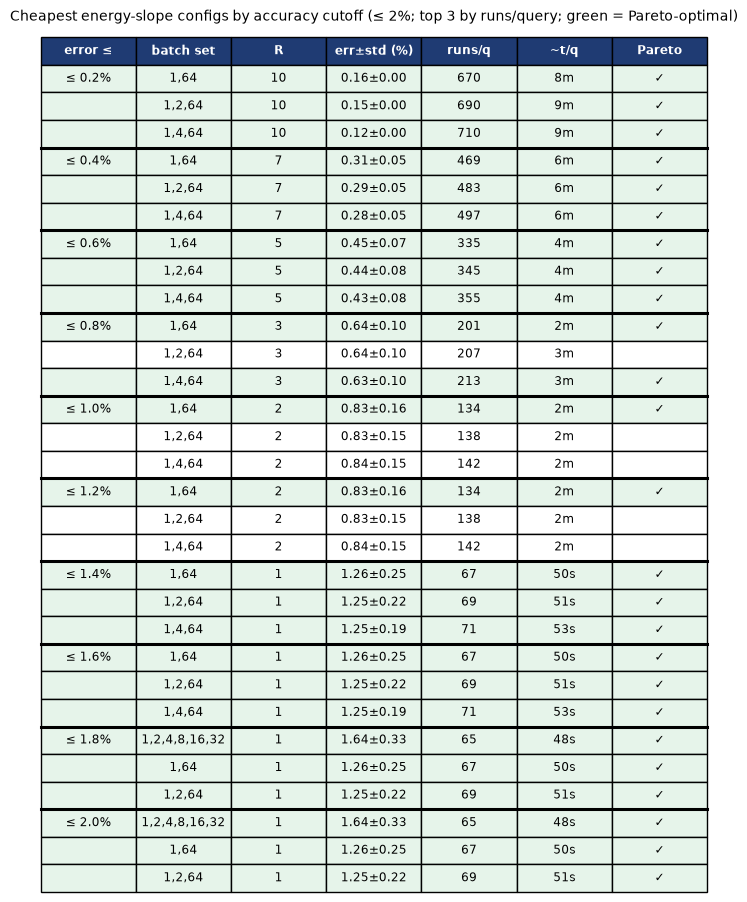



Pareto frontier — the least runs to reach each accuracy level:
   1,2         R=1  err 6.75±1.16%     5 runs/q   ~4s/q
   1,2,4       R=1  err 5.36±0.97%     9 runs/q   ~7s/q
   1,2,4       R=2  err 4.93±0.66%    18 runs/q   ~13s/q
   1,2,4       R=3  err 4.85±0.55%    27 runs/q   ~20s/q
   1,2         R=10 err 4.67±0.00%    50 runs/q   ~37s/q
   1,2,4,8,16,32 R=1  err 1.64±0.33%    65 runs/q   ~48s/q
   1,64        R=1  err 1.26±0.25%    67 runs/q   ~50s/q
   1,2,64      R=1  err 1.25±0.22%    69 runs/q   ~51s/q
   1,4,64      R=1  err 1.25±0.19%    71 runs/q   ~53s/q
   1,16,64     R=1  err 1.21±0.17%    83 runs/q   ~1m/q
   1,64        R=2  err 0.83±0.16%   134 runs/q   ~2m/q
   1,64        R=3  err 0.64±0.10%   201 runs/q   ~2m/q
   1,4,64      R=3  err 0.63±0.10%   213 runs/q   ~3m/q
   1,64        R=5  err 0.45±0.07%   335 runs/q   ~4m/q
   1,2,64      R=5  err 0.44±0.08%   345 runs/q   ~4m/q
   1,4,64      R=5  err 0.43±0.08%   355 runs/q   ~4m/q
   1,64        R=7  err 0.31±0

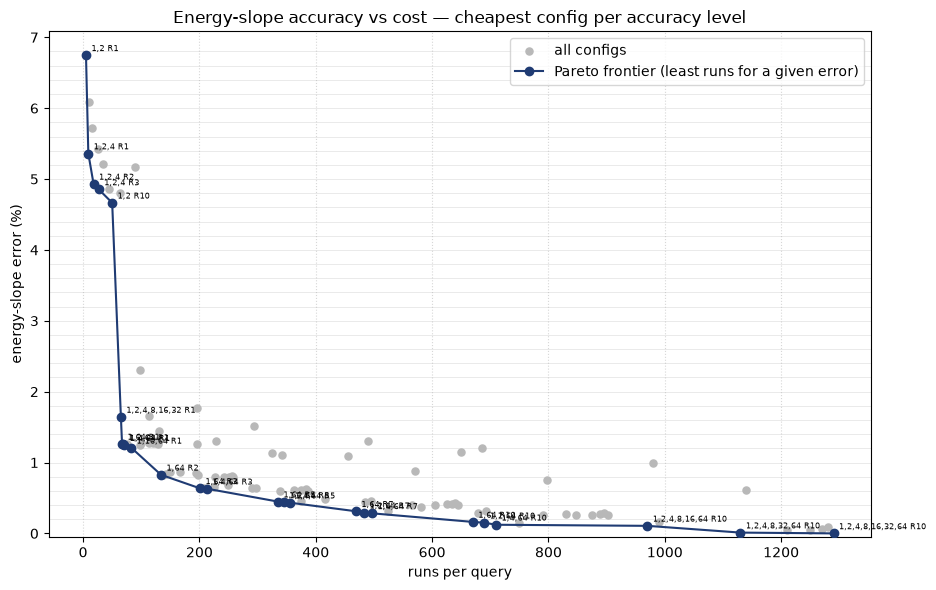

In [17]:
STEP = 0.2         # spacing of the accuracy cutoffs, in % error


def config_table(mean_tab, std_tab):
    recs = []
    for bs in mean_tab.index:
        for col in mean_tab.columns:
            recs.append(dict(batch_set=bs, R=int(col.split("=")[1]),
                             err=float(mean_tab.loc[bs, col]),
                             std=float(std_tab.loc[bs, col]),
                             runs=int(RUNS.loc[bs, col]),
                             secs=float(SECS.loc[bs, col])))
    df = pd.DataFrame(recs)
    # Pareto-optimal = no other config is <= on BOTH err and runs (and < on one)
    e, r = df["err"].to_numpy(), df["runs"].to_numpy()
    dominated = (((e[None, :] <= e[:, None]) & (r[None, :] <= r[:, None]) &
                  ((e[None, :] < e[:, None]) | (r[None, :] < r[:, None]))).any(axis=1))
    df["pareto"] = ~dominated
    return df


cfg = config_table(tab_Es, std_Es)

# ---- figure table: cheapest configs per accuracy cutoff (up to 2%) ----
MAX_CUT = 2.0
TOPN_TAB = 3
cols = ["error ≤", "batch set", "R", "err±std (%)",
        "runs/q", "~t/q", "Pareto"]
rows, rowcolors, n_extra = [], [], 0
for c in np.arange(STEP, MAX_CUT + 1e-9, STEP):
    feas = cfg[cfg["err"] <= c + 1e-9].sort_values(["runs", "err"])
    shown = feas.head(TOPN_TAB)
    # guarantee each cutoff shows its Pareto-optimal (best non-dominated) pick:
    # sorting by (runs, err) makes row 1 always Pareto, so this never triggers,
    # but if a top-N ever lacked one we append the cheapest Pareto config here.
    if not shown["pareto"].any() and feas["pareto"].any():
        shown = pd.concat([shown, feas[feas["pareto"]].head(1)])
        n_extra += 1
    for k, (_, x) in enumerate(shown.iterrows()):
        rows.append([f"≤ {c:.1f}%" if k == 0 else "", x["batch_set"],
                     str(int(x["R"])), f"{x['err']:.2f}±{x['std']:.2f}",
                     str(int(x["runs"])), fmt_dur(x["secs"]),
                     "✓" if x["pareto"] else ""])
        rowcolors.append("#e6f4ea" if x["pareto"] else "white")   # green = Pareto
group_starts = [i for i, r in enumerate(rows) if r[0]]            # first row per cutoff
print(f"Pareto-guarantee check: cutoffs whose top-{TOPN_TAB} lacked a Pareto "
      f"config (extra rows appended): {n_extra}")

n_total = len(rows) + 1
fig, ax = plt.subplots(figsize=(8.6, 0.34 * len(rows) + 0.9))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1f3b73")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(rowcolors):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(rc)
# bold separator line between each accuracy-cutoff section
for g in group_starts[1:]:
    y = 1 - (g + 1) / n_total
    ax.plot([0, 1], [y, y], transform=ax.transAxes, color="black", lw=2.2,
            clip_on=False, zorder=5)
ax.set_title(f"Cheapest energy-slope configs by accuracy cutoff "
             f"(≤ {MAX_CUT:g}%; top {TOPN_TAB} by runs/query; "
             "green = Pareto-optimal)", fontsize=10, pad=12)
fig.savefig(FIG_DIR / "accuracy_cutoffs_table_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()

cuts = np.arange(STEP, np.ceil(cfg["err"].max() / STEP) * STEP + STEP, STEP)

print("\n\nPareto frontier — the least runs to reach each accuracy level:")
pf = cfg[cfg["pareto"]].sort_values("runs")
for _, x in pf.iterrows():
    print(f"   {x['batch_set']:<11} R={int(x['R']):<2} "
          f"err {x['err']:.2f}±{x['std']:.2f}%   "
          f"{int(x['runs']):>3} runs/q   ~{fmt_dur(x['secs'])}/q")

# ---- scatter: every config, with the accuracy-vs-cost frontier ----
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(cfg["runs"], cfg["err"], s=26, color="0.72", zorder=2,
           label="all configs")
ax.plot(pf["runs"], pf["err"], "-o", color="#1f3b73", zorder=3,
        label="Pareto frontier (least runs for a given error)")
for _, x in pf.iterrows():
    ax.annotate(f"{x['batch_set']} R{int(x['R'])}", (x["runs"], x["err"]),
                fontsize=6, xytext=(4, 3), textcoords="offset points")
for e in cuts:
    ax.axhline(e, color="0.9", lw=0.6, zorder=0)
ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
ax.set_ylim(bottom=-0.05)
ax.set_title("Energy-slope accuracy vs cost — cheapest config per accuracy level")
ax.grid(axis="x", linestyle=":", alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_buckets_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()


## 12. Uneven repeat allocation across batch sizes

§10–§11 used the same repeat count `R` at every batch size. But a repeat at
batchnum 16 costs ~16× one at batchnum 1 while being only ~4× noisier
(`σ ∝ √magnitude`, §9), so in principle repeats can be spent **unevenly** — more
where measurement is cheap, fewer where it is expensive. For a two-point design
the optimal split minimises the slope's sampling variance at fixed cost
`Σ nₓcₓ`, giving (with the per-batchnum leverage) `nₓ ∝ |x−x̄|·σₓ/√cₓ`.

Enumerating every allocation *empirically* is intractable, so we **predict** each
one: per query, its error is `√(bias² + Var(b̂))`, where **bias** is the batch
set's own error at full repeats (the floor from dropping batch sizes, from §10's
`R=10` column) and **Var(b̂)** is the slope's variance from sub-sampling the
repeats — `Var = Σ (x−x̄)²σₓ²(1/nₓ − 1/N) / [Σ(x−x̄)²]²`, a fit-the-means slope
with a **finite-population correction** (the `N=10` repeats *are* the
population), and the noise term scaled by `0.674` (median/σ) so the RMS matches
§11's *median* metric. The correction makes the prediction reduce to the pure
bias at full repeats; the check below confirms it reproduces §11's `{1,16}` row
across all repeat counts. We report the **median relative error across queries**.

Below: (a) the suggested allocation shape per batch set and a check that the
model reproduces §11 for uniform allocation; then (b) a cutoff table over
allocations. Batch sets whose **full-data error already exceeds 1%** are dropped
(no allocation beats the bias floor), the **max cutoff is 1%**, and we show the
top **20** configs at ≤0.2%, **10** at ≤0.4%, and **3** for the rest. Cost is
`runs/q = 2·max(nₓ) + Σ nₓ·x` (warm-ups shared per restart group, matching §11).


In [18]:
# per-query, per-batchnum mean and std of whole-batch ENERGY, from §10's cube
xall = np.array(BATCH, float)
N_REP = R_AVAIL                         # the repeats ARE the finite population
qmE = ~np.isnan(cube_E).any(axis=(1, 2))
CE = cube_E[qmE]
meanx = CE.mean(axis=2)                 # (Qk, 5) mean over the repeats
sdx = CE.std(axis=2, ddof=1)           # (Qk, 5) std over the repeats


def _slope(Y, xs):                      # fit-the-means slope (one point per batchnum)
    xc = xs - xs.mean()
    return (Y * xc).sum(1) / (xc ** 2).sum()


b_full = _slope(meanx, xall)            # full-design slope per query = ground truth
ab = np.abs(b_full)

# batch sets worth keeping: full-repeats (bias-floor) error <= 1%
_FULLR = f"R={R_AVAIL}"
kept = [bs for bs in BATCH_SETS
        if tab_Es.loc[",".join(map(str, bs)), _FULLR] <= 1.0]


MED = 0.6745    # median(|N(0,σ)|)/σ — calibrates the RMS noise term to §11's median


def alloc_error(idx, n, bias):
    """predicted median % slope error for allocation n over batch indices idx."""
    xs = xall[idx]; lev = (xs - xs.mean()) ** 2; DB = lev.sum()
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP        # finite-pop correction
    Var = (lev * sdx[:, idx] ** 2 * inv).sum(1) / DB ** 2  # (Qk,)
    return 100 * np.median(np.sqrt(bias ** 2 + (MED ** 2) * Var) / ab)


def alloc_parts(idx, n, bias):
    """(total error %, sampling σ %, bias %) — the error split into its parts."""
    xs = xall[idx]; lev = (xs - xs.mean()) ** 2; DB = lev.sum()
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    Var = (lev * sdx[:, idx] ** 2 * inv).sum(1) / DB ** 2
    noise = MED * np.sqrt(Var)                       # sampling std (variance part)
    tot = np.sqrt(bias ** 2 + noise ** 2)
    return (100 * np.median(tot / ab), 100 * np.median(noise / ab),
            100 * np.median(np.abs(bias) / ab))


print("Suggested allocation shape  (nₓ ∝ |x−x̄|·σₓ/√cₓ, cₓ = 2+x; min = 1):")
for bs in kept:
    idx = [bpos[b] for b in bs]; xs = xall[idx]
    sg = np.median(sdx[:, idx], axis=0)
    w = np.abs(xs - xs.mean()) * sg / np.sqrt([2 + b for b in bs])
    w = w / w[w > 0].min()
    print(f"  {','.join(map(str, bs)):<12} -> "
          + ",  ".join(f"bn{b}:{wi:.1f}" for b, wi in zip(bs, w)))

lo_b, hi_b = BATCH[0], BATCH[-1]            # extremes of the (capped) batch set
lo_hi = f"{lo_b},{hi_b}"
print(f"\nModel check — predicted vs §11 empirical error for uniform {{{lo_hi}}}:")
idx_lohi = [bpos[lo_b], bpos[hi_b]]
bias_lohi = _slope(meanx[:, idx_lohi], xall[idx_lohi]) - b_full
for R in [r for r in [1, 2, 3, 5, 10] if r <= N_REP]:
    emp = tab_Es.loc[lo_hi, f"R={R}"] if lo_hi in tab_Es.index else float("nan")
    print(f"   R={R:<2} predicted {alloc_error(idx_lohi, [R, R], bias_lohi):.2f}%   "
          f"§11 empirical {emp:.2f}%")


Suggested allocation shape  (nₓ ∝ |x−x̄|·σₓ/√cₓ, cₓ = 2+x; min = 1):
  1,64         -> bn1:1.0,  bn64:6.8
  1,2,64       -> bn1:1.0,  bn2:1.4,  bn64:13.2
  1,4,64       -> bn1:1.0,  bn4:1.5,  bn64:12.6
  1,8,64       -> bn1:1.0,  bn8:1.5,  bn64:11.5
  1,16,64      -> bn1:1.0,  bn16:1.1,  bn64:9.6
  1,2,4,8,16,64 -> bn1:33.6,  bn2:45.6,  bn4:46.0,  bn8:37.8,  bn16:1.0,  bn64:739.1
  32,64        -> bn32:1.0,  bn64:1.5
  1,32,64      -> bn1:21.5,  bn32:1.0,  bn64:147.2
  1,2,4,8,32,64 -> bn1:1.0,  bn2:1.4,  bn4:1.4,  bn8:1.3,  bn32:3.4,  bn64:17.6
  16,32,64     -> bn16:2.4,  bn32:1.0,  bn64:7.7
  1,2,4,16,32,64 -> bn1:1.9,  bn2:2.6,  bn4:2.7,  bn16:1.0,  bn32:5.2,  bn64:29.5
  1,2,8,16,32,64 -> bn1:1.6,  bn2:2.3,  bn8:2.2,  bn16:1.0,  bn32:4.2,  bn64:24.7
  1,4,8,16,32,64 -> bn1:1.5,  bn4:2.3,  bn8:2.1,  bn16:1.0,  bn32:3.8,  bn64:22.8
  2,4,8,16,32,64 -> bn2:2.1,  bn4:2.2,  bn8:2.1,  bn16:1.0,  bn32:3.6,  bn64:22.0
  1,2,4,8,16,32,64 -> bn1:3.0,  bn2:4.1,  bn4:4.3,  bn8:3.8,  bn16:1.0,

172675 allocations over 15 batch sets; 435 on the Pareto frontier.


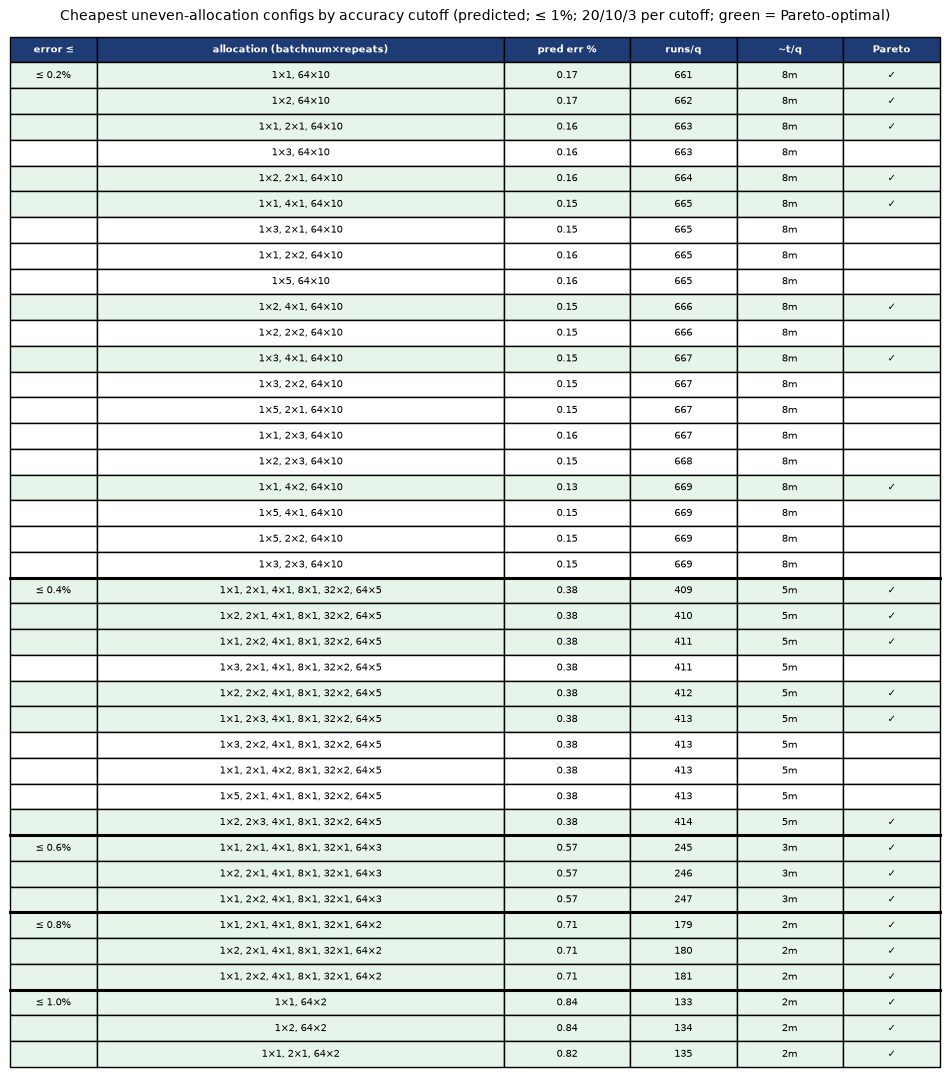

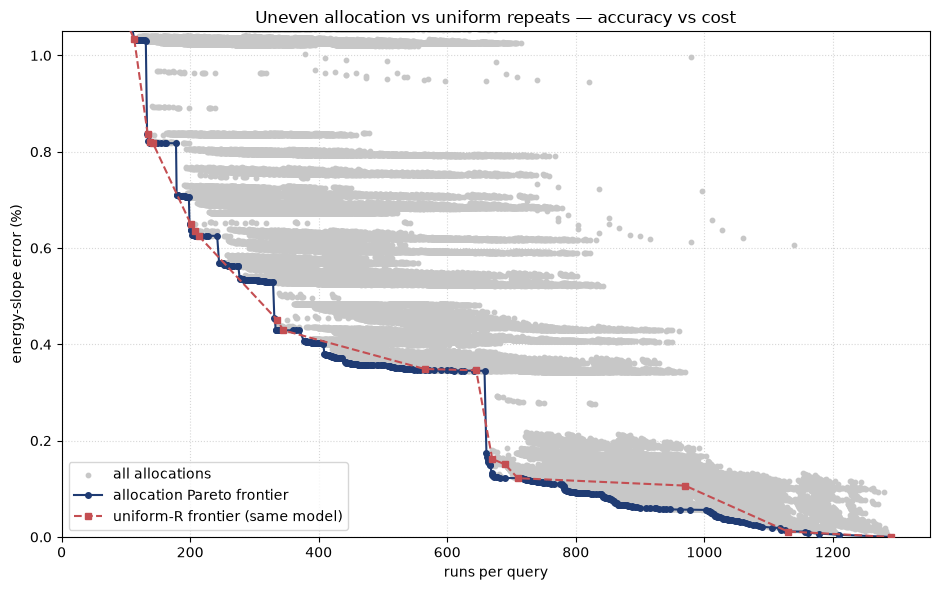

In [19]:
# ---- enumerate per-batchnum allocations and predict accuracy + cost ----
ALLOC_R = [r for r in [1, 2, 3, 5, 10] if r <= N_REP]   # repeats per batchnum (<= N)
recs = []
for bs in kept:
    idx = [bpos[b] for b in bs]
    bias = _slope(meanx[:, idx], xall[idx]) - b_full
    for n in itertools.product(ALLOC_R, repeat=len(idx)):
        err, var, bia = alloc_parts(idx, n, bias)
        runs = int(2 * max(n) + sum(ni * x for ni, x in zip(n, bs)))
        recs.append((", ".join(f"{x}×{ni}" for x, ni in zip(bs, n)),
                     err, var, bia, runs, SEC_PER_ENTRY * runs / full_copies,
                     len(set(n)) == 1))          # uniform = same repeats everywhere
cfg2 = pd.DataFrame(recs,
                    columns=["alloc", "err", "var", "bias", "runs", "secs", "uniform"])

# Pareto frontier (min err, min runs) via a cheap runs-sorted sweep
cfg2 = cfg2.sort_values(["runs", "err"]).reset_index(drop=True)
best = np.inf; par = np.zeros(len(cfg2), bool)
for i in range(len(cfg2)):
    if cfg2.at[i, "err"] < best - 1e-12:
        par[i] = True; best = cfg2.at[i, "err"]
cfg2["pareto"] = par
print(f"{len(cfg2)} allocations over {len(kept)} batch sets; "
      f"{int(par.sum())} on the Pareto frontier.")

# ---- cutoff table figure (max 1%; 20 / 10 / 3 rows) ----
PERCUT = {0.2: 20, 0.4: 10}
cols = ["error ≤", "allocation (batchnum×repeats)", "pred err %",
        "runs/q", "~t/q", "Pareto"]
rows, rowcolors = [], []
for c in [0.2, 0.4, 0.6, 0.8, 1.0]:
    feas = cfg2[cfg2["err"] <= c + 1e-9].sort_values(["runs", "err"])
    feas = feas.head(PERCUT.get(round(c, 1), 3))
    for k, (_, x) in enumerate(feas.iterrows()):
        rows.append([f"≤ {c:.1f}%" if k == 0 else "", x["alloc"],
                     f"{x['err']:.2f}", str(int(x["runs"])), fmt_dur(x["secs"]),
                     "✓" if x["pareto"] else ""])
        rowcolors.append("#e6f4ea" if x["pareto"] else "white")
group_starts = [i for i, r in enumerate(rows) if r[0]]

n_total = len(rows) + 1
fig, ax = plt.subplots(figsize=(12, 0.32 * len(rows) + 0.9))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1],
               colWidths=[0.09, 0.42, 0.13, 0.11, 0.11, 0.10])
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1f3b73")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(rowcolors):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(rc)
for g in group_starts[1:]:
    y = 1 - (g + 1) / n_total
    ax.plot([0, 1], [y, y], transform=ax.transAxes, color="black", lw=2.2,
            clip_on=False, zorder=5)
ax.set_title("Cheapest uneven-allocation configs by accuracy cutoff "
             "(predicted; ≤ 1%; 20/10/3 per cutoff; green = Pareto-optimal)",
             fontsize=10, pad=12)
fig.savefig(FIG_DIR / "accuracy_cutoffs_alloc_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()

# ---- scatter: allocations vs the uniform-design frontier ----
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(cfg2["runs"], cfg2["err"], s=10, color="0.78", zorder=2,
           label="all allocations")
pf = cfg2[cfg2["pareto"]].sort_values("runs")
ax.plot(pf["runs"], pf["err"], "-o", ms=4, color="#1f3b73", zorder=3,
        label="allocation Pareto frontier")
# uniform-R frontier computed the SAME way (same model, same kept batch sets) so
# it is a fair subset of the allocation space — the blue line must weakly dominate
u = cfg2[cfg2["uniform"]].sort_values(["runs", "err"]).reset_index(drop=True)
bu = np.inf; pu = np.zeros(len(u), bool)
for i in range(len(u)):
    if u.at[i, "err"] < bu - 1e-12:
        pu[i] = True; bu = u.at[i, "err"]
uni = u[pu]
ax.plot(uni["runs"], uni["err"], "--s", ms=4, color="#c44e52", zorder=3,
        label="uniform-R frontier (same model)")
ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
ax.set_ylim(0, 1.05); ax.set_xlim(left=0)
ax.set_title("Uneven allocation vs uniform repeats — accuracy vs cost")
ax.grid(linestyle=":", alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "alloc_vs_uniform_frontier.svg", format="svg",
            bbox_inches="tight")
plt.show()


### Every allocation Pareto-frontier config

The full accuracy-vs-cost frontier from §12, cheapest first. The predicted
**error** is split into the **bias** floor (from the batch set, unbeatable by more
repeats) and the **sampling σ** (the variance part, which shrinks as repeats are
added) — `error ≈ √(bias² + σ²)`. `runs/q` and `~t/q` are the per-query cost.


435 configs on the allocation Pareto frontier (error = √(bias² + σ²); 9 are uniform).


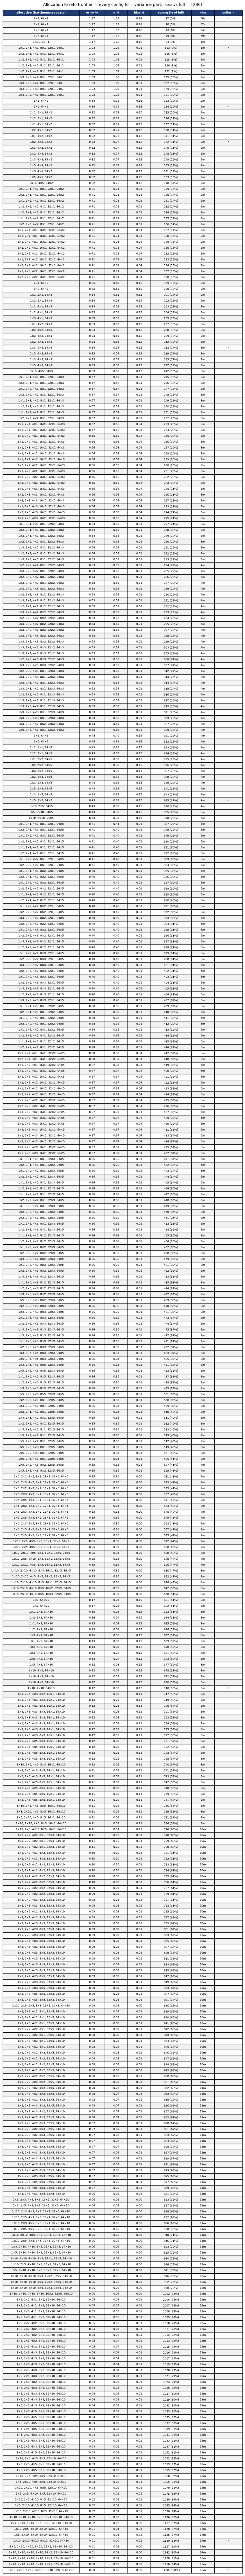

In [20]:
front = cfg2[cfg2["pareto"]].sort_values("runs").reset_index(drop=True)
print(f"{len(front)} configs on the allocation Pareto frontier "
      f"(error = √(bias² + σ²); {int(front['uniform'].sum())} are uniform).")

FULL_RUNS = int(N_REP * (2 + sum(BATCH)))          # full design = 100%
cols = ["allocation (batchnum×repeats)", "error %", "σ %", "bias %",
        "runs/q (% of full)", "~t/q", "uniform"]
rows, rowcolors = [], []
for i, (_, x) in enumerate(front.iterrows()):
    rows.append([x["alloc"], f"{x['err']:.2f}", f"{x['var']:.2f}",
                 f"{x['bias']:.2f}",
                 f"{int(x['runs'])} ({100 * x['runs'] / FULL_RUNS:.0f}%)",
                 fmt_dur(x["secs"]), "✓" if x["uniform"] else ""])
    rowcolors.append("#f2f2f2" if i % 2 else "white")   # alternating banding

fig, ax = plt.subplots(figsize=(11, 0.27 * len(rows) + 0.8))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1],
               colWidths=[0.30, 0.10, 0.09, 0.09, 0.16, 0.09, 0.11])
tbl.auto_set_font_size(False); tbl.set_fontsize(7)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1f3b73")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(rowcolors):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(rc)
ax.set_title(f"Allocation Pareto frontier — every config "
             f"(σ = variance part; runs vs full = {FULL_RUNS})", fontsize=10, pad=10)
fig.savefig(FIG_DIR / "alloc_frontier_energy_slope.svg", format="svg",
            bbox_inches="tight")
plt.show()


### Per-atom repeat counts across the frontier

The frontier above is a list of allocations; this breaks each one into its individual
**atoms** — a single `batchnum×repeats` choice such as `16×10` or `8×5` — and asks how
often each appears.

**A — frequency heatmap** (`batchnum × repeats`, cell = how many frontier configs use
that atom). Read it with two confounds in mind, both of which you flagged: an atom can
only appear where its budget makes it optimal (`16×10` only in the expensive tail,
`16×1` only at the cheap end), and a batchnum that sits in more of the kept batch sets
gets more chances to appear. So the count is really **"the budget range over which this
atom is part of the optimal choice"**, not an absolute goodness score.

**B — the de-confounded view**: each atom's repeats plotted against its config's
`runs/q`, coloured by batchnum, so you see directly how each variable's repeat count
climbs with budget — the empirical water-filling read straight off the real frontier
(compare §13c's modelled version). Saved to `./figures/`.


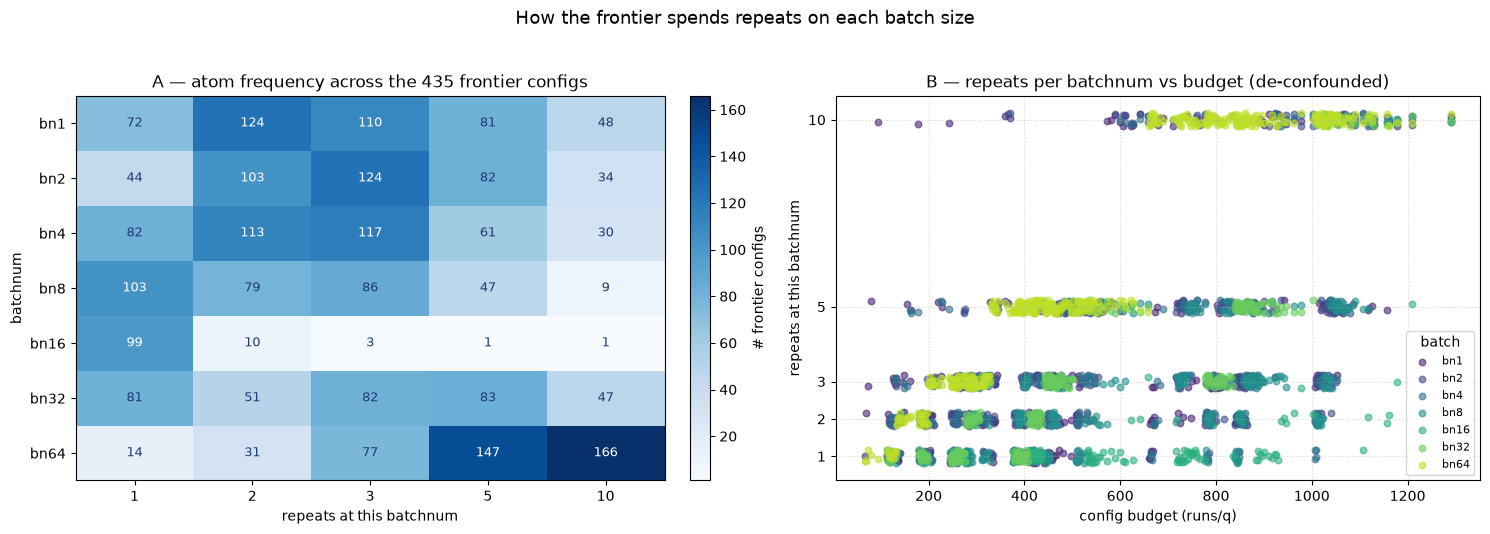

2442 atoms across 435 frontier configs.
Most frequent atoms (count — remember the budget & batch-set confounds):
   bn64×10: 166 configs
   bn64×5: 147 configs
   bn1×2: 124 configs
   bn2×3: 124 configs
   bn4×3: 117 configs
   bn4×2: 113 configs
   bn1×3: 110 configs
   bn8×1: 103 configs
   bn2×2: 103 configs
   bn16×1: 99 configs

How many kept batch sets each batchnum appears in (the other confound behind the raw counts):
   bn1:12/15, bn2:7/15, bn4:7/15, bn8:7/15, bn16:8/15, bn32:9/15, bn64:15/15


In [21]:
import re as _re

recs = []
for _, x in front.iterrows():
    for m in _re.finditer(r"(\d+)×(\d+)", x["alloc"]):
        recs.append((int(m.group(1)), int(m.group(2)),
                     int(x["runs"]), float(x["err"]), float(x["secs"])))
atoms = pd.DataFrame(recs, columns=["batchnum", "repeats", "runs", "err", "secs"])
REPVALS = sorted(atoms["repeats"].unique())

M = np.zeros((len(BATCH), len(REPVALS)), int)
for bn, rp in zip(atoms["batchnum"], atoms["repeats"]):
    M[BATCH.index(bn), REPVALS.index(rp)] += 1

fig, (axH, axS) = plt.subplots(1, 2, figsize=(15, 5.4))

im = axH.imshow(M, cmap="Blues", aspect="auto")
axH.set_xticks(range(len(REPVALS))); axH.set_xticklabels(REPVALS)
axH.set_yticks(range(len(BATCH))); axH.set_yticklabels([f"bn{b}" for b in BATCH])
for i in range(len(BATCH)):
    for j in range(len(REPVALS)):
        if M[i, j]:
            axH.text(j, i, str(M[i, j]), ha="center", va="center", fontsize=9,
                     color="white" if M[i, j] > M.max() * 0.55 else "#1f3b73")
axH.set_xlabel("repeats at this batchnum"); axH.set_ylabel("batchnum")
axH.set_title(f"A — atom frequency across the {len(front)} frontier configs")
fig.colorbar(im, ax=axH, fraction=0.046, pad=0.04).set_label("# frontier configs")

cols = plt.cm.viridis(np.linspace(0.1, 0.9, len(BATCH)))
rng = np.random.default_rng(1)
for k, b in enumerate(BATCH):
    s = atoms[atoms["batchnum"] == b]
    axS.scatter(s["runs"], s["repeats"] + rng.uniform(-0.18, 0.18, len(s)),
                s=22, color=cols[k], alpha=0.6, label=f"bn{b}")
axS.set_yticks(REPVALS); axS.set_xlabel("config budget (runs/q)")
axS.set_ylabel("repeats at this batchnum")
axS.set_title("B — repeats per batchnum vs budget (de-confounded)")
axS.grid(linestyle=":", alpha=0.5); axS.legend(fontsize=8, title="batch")

fig.suptitle("How the frontier spends repeats on each batch size", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "frontier_atom_frequency.svg", format="svg",
            bbox_inches="tight")
plt.show()

print(f"{len(atoms)} atoms across {len(front)} frontier configs.")
print("Most frequent atoms (count — remember the budget & batch-set confounds):")
top = (atoms.groupby(["batchnum", "repeats"]).size()
       .sort_values(ascending=False).head(10))
for (b, r), c in top.items():
    print(f"   bn{b}×{r}: {c} configs")
print("\nHow many kept batch sets each batchnum appears in "
      "(the other confound behind the raw counts):")
in_sets = {b: sum(b in bs for bs in kept) for b in BATCH}
print("   " + ", ".join(f"bn{b}:{in_sets[b]}/{len(kept)}" for b in BATCH))


## 13. Sensitivity — importance of each batch size and its repeats

Two separate things decide the energy-slope estimate, and this section pulls them
apart, for both a **uniform** and a **non-uniform** repeat policy.

* **Position importance** — how much each batch size *defines* the slope. An OLS
  line leans on a point by its **leverage** `(x − x̄)² / Σ(x − x̄)²`, so the extreme
  batch sizes (1 and 16) carry the fit and the middle ones barely move it. This is
  structural — it does **not** depend on how many repeats you run — and is checked
  empirically by the **leave-one-out** error: drop each batch size, refit, and see
  how far the energy slope shifts.
* **Repeat importance** — where the slope's **sampling noise** enters: each batch
  size's share of the slope variance
  `Var(b̂) = Σ (x−x̄)²σₓ²(1/nₓ−1/N) / [Σ(x−x̄)²]²` (the §12 model). This says which
  batch size the *next repeat* should go to.

The two **versions** apply two repeat policies at the **same total repeat budget**:

* **uniform** — the same repeats at every batch size (the §10–§11 assumption);
* **non-uniform** — the cost-aware optimal allocation `nₓ ∝ |x−x̄|·σₓ/√cₓ` (§12).

Position importance is identical in both (same batch set); repeat importance
shifts. Moving repeats toward the high-leverage end sharply narrows the spread in
the **cost-weighted marginal value of one more repeat** (`cₓ·∂Var/∂nₓ`) — the
optimum would equalise it in the continuous limit, though integer repeats and the
fixed run budget stop just short of perfect levelling — whereas uniform repeats
leave it lopsided toward the expensive, noisy high end. The figure is saved to
`./figures/`.


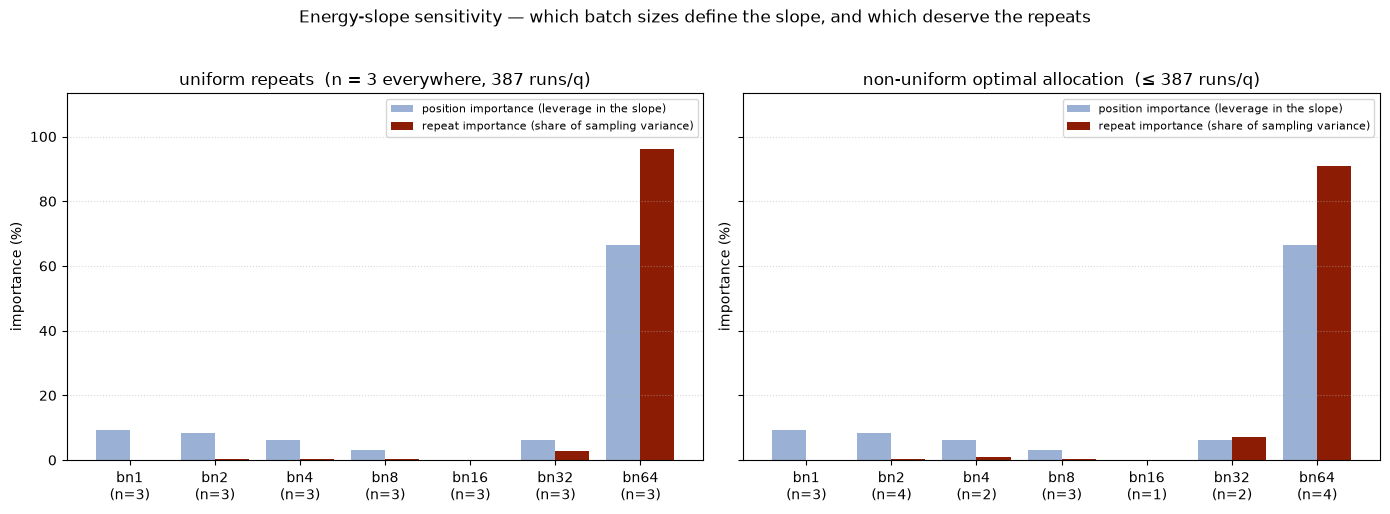

Position importance — leverage share, with empirical leave-one-out check:
   bn1 : leverage   9.3%   |  drop-it energy-slope error  0.09%
   bn2 : leverage   8.3%   |  drop-it energy-slope error  0.07%
   bn4 : leverage   6.3%   |  drop-it energy-slope error  0.05%
   bn8 : leverage   3.3%   |  drop-it energy-slope error  0.04%
   bn16: leverage   0.1%   |  drop-it energy-slope error  0.01%
   bn32: leverage   6.1%   |  drop-it energy-slope error  0.11%
   bn64: leverage  66.6%   |  drop-it energy-slope error  1.15%

Repeat importance — share of the slope's sampling variance:
   uniform  (n=3,3,3,3,3,3,3):  bn1 0%, bn2 0%, bn4 0%, bn8 0%, bn16 0%, bn32 3%, bn64 96%
   optimal  (n=3,4,2,3,1,2,4):  bn1 0%, bn2 0%, bn4 1%, bn8 0%, bn16 0%, bn32 7%, bn64 91%

Predicted energy-slope error at equal cost (uniform R=3 = 387 runs/q  vs  optimal = 387 runs/q): uniform 0.53%  vs  optimal 0.44%  (+16% change).
Cost-weighted value of one more repeat per batch (1.0 = best; sat = at N):
   uniform:  

In [22]:
# reuses §10's cube_E / slopes_intercepts and §12's meanx, sdx, b_full, ab, qmE
xbar = xall.mean()
lev = (xall - xbar) ** 2
DB = lev.sum()
pos_share = lev / DB                    # leverage share (sums to 1); repeat-agnostic
idxF = list(range(len(BATCH)))

# --- empirical leave-one-out: energy-slope error from DROPPING each batch size ---
s_full, _ = slopes_intercepts(cube_E, qmE, idxF, list(range(N_REP)))
loo = []
for j in idxF:
    keep = [k for k in idxF if k != j]
    if len(keep) >= 2:
        s_j, _ = slopes_intercepts(cube_E, qmE, keep, list(range(N_REP)))
        loo.append(100 * np.median(np.abs(s_j - s_full) / np.abs(s_full)))
    else:
        loo.append(np.nan)
loo = np.array(loo)

# --- repeat importance: each batch size's share of the slope's sampling variance ---
sig2 = sdx ** 2                         # (Qk, 5) per-query per-batchnum variance


def var_shares(n):
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    contrib = lev[None, :] * sig2 * inv[None, :]            # (Qk, 5), up to /DB²
    tot = contrib.sum(1, keepdims=True)
    share = np.divide(contrib, tot, out=np.zeros_like(contrib), where=tot > 0)
    return share.mean(0)                # mean share across queries (sums to ~1)


# version 1 — UNIFORM repeats (R=3, the §10/§11 sweet spot)
R_UNI = max(1, min(3, N_REP - 1))   # a sub-sampled operating point (< full repeats)
n_uni = np.full(len(BATCH), R_UNI, int)

# version 2 — NON-UNIFORM optimal allocation at the SAME run budget as uniform R
def alloc_var(n):                       # median predicted slope variance (up to /ab²)
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    return float(np.median((lev[None, :] * sig2 * inv[None, :]).sum(1) / DB ** 2))


def alloc_runs(n):                      # runs/q = 2·max(n) + Σ nₓ·x  (matches §12)
    return int(2 * max(n) + sum(int(ni) * b for ni, b in zip(n, BATCH)))


BUDGET_RUNS = alloc_runs(n_uni)         # spend no more runs/q than uniform R does
n_opt = np.ones(len(BATCH), int)        # greedy: each repeat goes where it cuts the
while True:                             # most variance per extra run (capped at N)
    cur_v, cur_r, best_j, best_gain = alloc_var(n_opt), alloc_runs(n_opt), -1, 0.0
    for j in range(len(BATCH)):
        if n_opt[j] >= N_REP:           # cannot sample beyond the population
            continue
        trial = n_opt.copy(); trial[j] += 1
        if alloc_runs(trial) > BUDGET_RUNS:
            continue
        dr = alloc_runs(trial) - cur_r
        gain = (cur_v - alloc_var(trial)) / dr if dr > 0 else 0.0
        if gain > best_gain:
            best_gain, best_j = gain, j
    if best_j < 0:
        break
    n_opt[best_j] += 1

share_uni, share_opt = var_shares(n_uni), var_shares(n_opt)


def cost_marg(n):                       # cost-weighted value of +1 repeat per batch
    base, br, vals = alloc_var(n), alloc_runs(n), []
    for j in range(len(BATCH)):
        t = n.copy()
        if t[j] >= N_REP:
            vals.append(np.nan); continue
        t[j] += 1; dr = alloc_runs(t) - br
        vals.append((base - alloc_var(t)) / dr if dr > 0 else np.nan)
    v = np.array(vals, float)
    return v / np.nanmax(v)


mv_uni, mv_opt = cost_marg(n_uni), cost_marg(n_opt)

# --- figure: position vs repeat importance, uniform | non-uniform ---
xb = np.arange(len(BATCH)); wbar = 0.4
ymax = 100 * max(pos_share.max(), share_uni.max(), share_opt.max()) * 1.18
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, (title, nvec, share) in zip(
        axes,
        [(f"uniform repeats  (n = {R_UNI} everywhere, {BUDGET_RUNS} runs/q)",
          n_uni, share_uni),
         (f"non-uniform optimal allocation  (≤ {BUDGET_RUNS} runs/q)",
          n_opt, share_opt)]):
    ax.bar(xb - wbar / 2, 100 * pos_share, wbar, color="#9ab0d4",
           label="position importance (leverage in the slope)")
    ax.bar(xb + wbar / 2, 100 * share, wbar, color="#8c1d04",
           label="repeat importance (share of sampling variance)")
    ax.set_xticks(xb)
    ax.set_xticklabels([f"bn{b}\n(n={nvec[k]})" for k, b in enumerate(BATCH)])
    ax.set_ylabel("importance (%)"); ax.set_title(title)
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle("Energy-slope sensitivity — which batch sizes define the slope, "
             "and which deserve the repeats", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "sensitivity_batch_repeat_energy_slope.svg", format="svg",
            bbox_inches="tight")
plt.show()

print("Position importance — leverage share, with empirical leave-one-out check:")
for b, p, l in zip(BATCH, pos_share, loo):
    print(f"   bn{b:<2}: leverage {100 * p:5.1f}%   |  drop-it energy-slope error "
          f"{l:5.2f}%")
print("\nRepeat importance — share of the slope's sampling variance:")
print("   uniform  (n=" + ",".join(map(str, n_uni)) + "):  "
      + ", ".join(f"bn{b} {100 * s:.0f}%" for b, s in zip(BATCH, share_uni)))
print("   optimal  (n=" + ",".join(map(str, n_opt)) + "):  "
      + ", ".join(f"bn{b} {100 * s:.0f}%" for b, s in zip(BATCH, share_opt)))

biasF = np.zeros(CE.shape[0])           # full batch set -> no bias
errU = alloc_error(idxF, list(n_uni), biasF)
errO = alloc_error(idxF, list(n_opt), biasF)
print(f"\nPredicted energy-slope error at equal cost (uniform R={R_UNI} = "
      f"{BUDGET_RUNS} runs/q  vs  optimal = {alloc_runs(n_opt)} runs/q): "
      f"uniform {errU:.2f}%  vs  optimal {errO:.2f}%  "
      f"({(100 * (errU - errO) / errU) if errU > 1e-9 else 0:+.0f}% change).")


def _fmt_mv(v):
    return "sat" if np.isnan(v) else f"{v:.2f}"


print("Cost-weighted value of one more repeat per batch (1.0 = best; sat = at N):")
print("   uniform:  " + ", ".join(f"bn{b} {_fmt_mv(v)}"
                                  for b, v in zip(BATCH, mv_uni)))
print("   optimal:  " + ", ".join(f"bn{b} {_fmt_mv(v)}"
                                  for b, v in zip(BATCH, mv_opt))
      + "   <- gap narrows sharply (integer repeats + fixed budget cap levelling)")


### 13b. The same sensitivity for the energy **overhead** (intercept)

The overhead is the fit's **intercept** — the fixed per-batch energy extrapolated to
`batchnum → 0` — so its "position importance" is the mirror image of the slope's.
The intercept is a weighted sum of the per-batchnum means `â = Σ hₓ·mₓ` with
`hₓ = 1/k − x̄(x−x̄)/Sxx`, so the **low** batch sizes (nearest the extrapolation to
zero) pin it while the high ones barely do — the opposite of the slope, which leans
on `bn16`. Repeat importance and the uniform-vs-optimal allocation follow the same
variance argument as §13, now with `hₓ²` in place of the slope leverage, and the
overhead error is again scored as a **% of one run's energy** (its natural scale,
since the overhead itself is often near zero). Figure saved to `./figures/`.


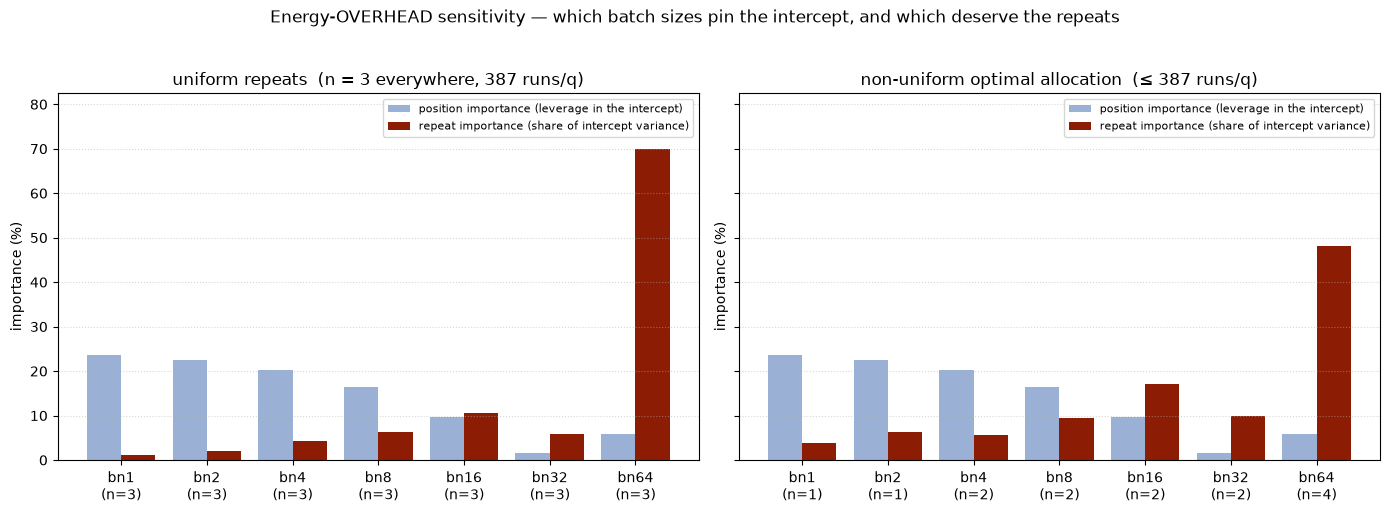

Position importance (overhead) — leverage share, with leave-one-out check:
   bn1 : leverage  23.6%   |  drop-it overhead error  4.17% of one run
   bn2 : leverage  22.5%   |  drop-it overhead error  3.15% of one run
   bn4 : leverage  20.3%   |  drop-it overhead error  2.46% of one run
   bn8 : leverage  16.4%   |  drop-it overhead error  2.66% of one run
   bn16: leverage   9.7%   |  drop-it overhead error  2.58% of one run
   bn32: leverage   1.6%   |  drop-it overhead error  1.54% of one run
   bn64: leverage   5.9%   |  drop-it overhead error  9.58% of one run

Repeat importance (overhead) — share of the intercept's sampling variance:
   uniform  (n=3,3,3,3,3,3,3):  bn1 1%, bn2 2%, bn4 4%, bn8 6%, bn16 10%, bn32 6%, bn64 70%
   optimal  (n=1,1,2,2,2,2,4):  bn1 4%, bn2 6%, bn4 6%, bn8 9%, bn16 17%, bn32 10%, bn64 48%

Predicted overhead error at equal cost (uniform R=3 = 387 runs/q  vs  optimal = 387 runs/q): uniform 5.53%  vs  optimal 5.55% of one run (-0% change).


In [23]:
# overhead (intercept) leverage: coefficient of each batchnum mean in â = Σ hₓ·mₓ
Sxx = ((xall - xbar) ** 2).sum()
hcoef = 1.0 / len(BATCH) - xbar * (xall - xbar) / Sxx
hlev = hcoef ** 2
pos_share_o = hlev / hlev.sum()

# empirical leave-one-out on the intercept, scored as % of one run's energy (|slope|)
s_full, o_full = slopes_intercepts(cube_E, qmE, idxF, list(range(N_REP)))
loo_o = []
for j in idxF:
    keep = [k for k in idxF if k != j]
    if len(keep) >= 2:
        s_j, o_j = slopes_intercepts(cube_E, qmE, keep, list(range(N_REP)))
        loo_o.append(100 * np.median(np.abs(o_j - o_full) / np.abs(s_full)))
    else:
        loo_o.append(np.nan)
loo_o = np.array(loo_o)


def var_shares_o(n):
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    contrib = hlev[None, :] * sig2 * inv[None, :]
    tot = contrib.sum(1, keepdims=True)
    share = np.divide(contrib, tot, out=np.zeros_like(contrib), where=tot > 0)
    return share.mean(0)


def alloc_var_o(n):
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    return float(np.median((hlev[None, :] * sig2 * inv[None, :]).sum(1)))


def alloc_err_o(n, bias):
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    Var = (hlev[None, :] * sig2 * inv[None, :]).sum(1)
    return 100 * np.median(np.sqrt(bias ** 2 + MED ** 2 * Var) / ab)


# greedy optimal allocation for the overhead, same run budget as uniform R (from §13)
n_opt_o = np.ones(len(BATCH), int)
while True:
    cur_v, cur_r, best_j, best_gain = alloc_var_o(n_opt_o), alloc_runs(n_opt_o), -1, 0.0
    for j in range(len(BATCH)):
        if n_opt_o[j] >= N_REP:
            continue
        trial = n_opt_o.copy(); trial[j] += 1
        if alloc_runs(trial) > BUDGET_RUNS:
            continue
        dr = alloc_runs(trial) - cur_r
        gain = (cur_v - alloc_var_o(trial)) / dr if dr > 0 else 0.0
        if gain > best_gain:
            best_gain, best_j = gain, j
    if best_j < 0:
        break
    n_opt_o[best_j] += 1

share_uni_o, share_opt_o = var_shares_o(n_uni), var_shares_o(n_opt_o)

xb = np.arange(len(BATCH)); wbar = 0.4
ymax = 100 * max(pos_share_o.max(), share_uni_o.max(), share_opt_o.max()) * 1.18
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, (title, nvec, share) in zip(
        axes,
        [(f"uniform repeats  (n = {R_UNI} everywhere, {BUDGET_RUNS} runs/q)",
          n_uni, share_uni_o),
         (f"non-uniform optimal allocation  (≤ {BUDGET_RUNS} runs/q)",
          n_opt_o, share_opt_o)]):
    ax.bar(xb - wbar / 2, 100 * pos_share_o, wbar, color="#9ab0d4",
           label="position importance (leverage in the intercept)")
    ax.bar(xb + wbar / 2, 100 * share, wbar, color="#8c1d04",
           label="repeat importance (share of intercept variance)")
    ax.set_xticks(xb)
    ax.set_xticklabels([f"bn{b}\n(n={nvec[k]})" for k, b in enumerate(BATCH)])
    ax.set_ylabel("importance (%)"); ax.set_title(title)
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle("Energy-OVERHEAD sensitivity — which batch sizes pin the intercept, "
             "and which deserve the repeats", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "sensitivity_batch_repeat_energy_overhead.svg", format="svg",
            bbox_inches="tight")
plt.show()

print("Position importance (overhead) — leverage share, with leave-one-out check:")
for b, p, l in zip(BATCH, pos_share_o, loo_o):
    print(f"   bn{b:<2}: leverage {100 * p:5.1f}%   |  drop-it overhead error "
          f"{l:5.2f}% of one run")
print("\nRepeat importance (overhead) — share of the intercept's sampling variance:")
print("   uniform  (n=" + ",".join(map(str, n_uni)) + "):  "
      + ", ".join(f"bn{b} {100 * s:.0f}%" for b, s in zip(BATCH, share_uni_o)))
print("   optimal  (n=" + ",".join(map(str, n_opt_o)) + "):  "
      + ", ".join(f"bn{b} {100 * s:.0f}%" for b, s in zip(BATCH, share_opt_o)))
biasFo = np.zeros(CE.shape[0])
euo, eoo = alloc_err_o(list(n_uni), biasFo), alloc_err_o(list(n_opt_o), biasFo)
print(f"\nPredicted overhead error at equal cost (uniform R={R_UNI} = {BUDGET_RUNS} "
      f"runs/q  vs  optimal = {alloc_runs(n_opt_o)} runs/q): "
      f"uniform {euo:.2f}%  vs  optimal {eoo:.2f}% of one run "
      f"({(100 * (euo - eoo) / euo) if euo > 1e-9 else 0:+.0f}% change).")


### 13c. Importance across the whole suite of repeats (not a single `n`)

§13/§13b froze the repeats at one operating point (`n=3`, or the optimal budget) to
read importance off a bar chart. This section instead sweeps **repeats across the
whole suite** and shows how importance behaves. The key theoretical fact drives the
design: each batch size's variance contribution is
`contribₓ ∝ leverageₓ · σₓ² · (1/nₓ − 1/N)`, so under **uniform** repeats `nₓ = R`
the `(1/R − 1/N)` factor is identical for every batch size and **cancels in the
share** — the *composition* of importance is invariant to how many repeats you run;
only the *absolute* uncertainty falls. Importance only becomes repeat-dependent once
repeats are spread **non-uniformly**.

Three panels (for the slope, then the overhead):

* **A — collapse & composition.** Stacked per-batch **absolute** variance
  contribution vs uniform `R = 1…N−1`, with the predicted error on the right axis.
  The stack shrinks toward the bias floor (`R→N`) while its proportions stay fixed —
  the invariance, drawn. The error line's steep early drop is the "≈3 repeats is
  enough" result (marginal gain `∝ 1/(R(R+1))`).
* **B — shares vs budget.** Each batch size's variance share against the run budget:
  **solid = uniform** (flat lines, by the cancellation above) vs **dashed = optimal
  allocation** at that budget (bending lines) — the only regime where importance
  moves across the suite.
* **C — water-filling path.** Greedy optimal allocation from one repeat each up to
  the full suite: each batch size's repeat count `nₓ` as a staircase over cumulative
  runs/q, with the marginal value of each added repeat (right axis). It shows the
  order the suite's repeats *should* be spent. Figures saved to `./figures/`.


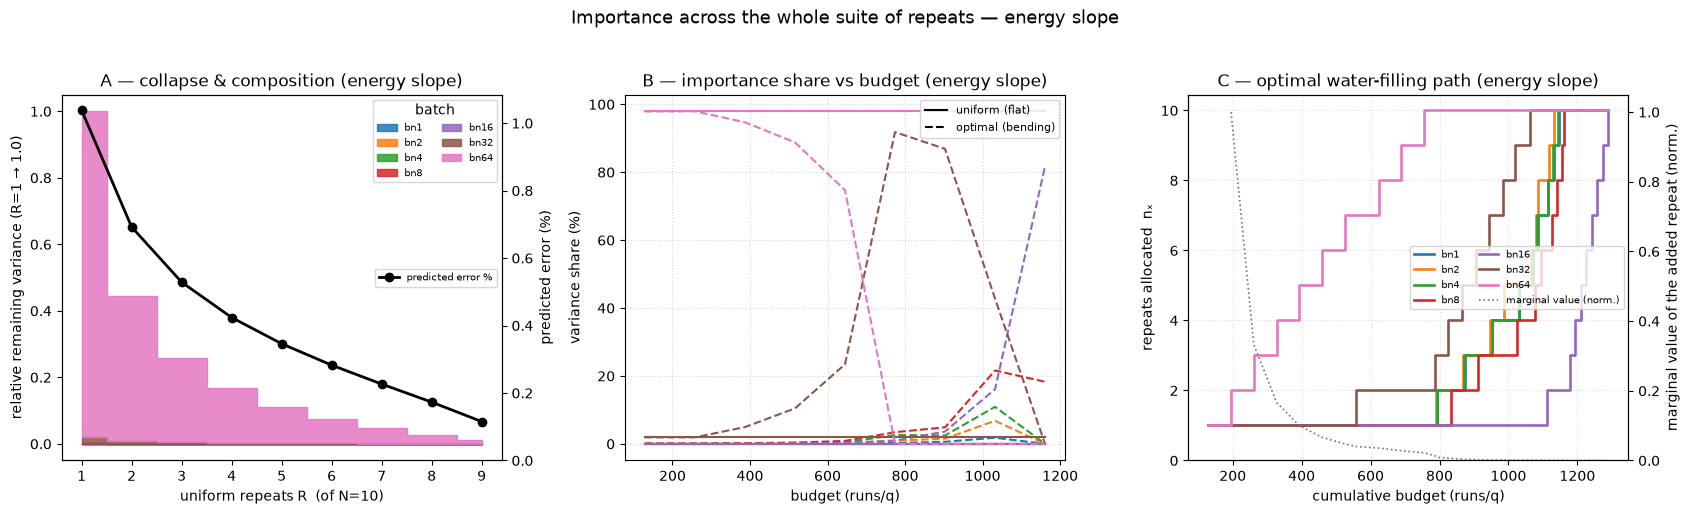

[energy slope] uniform variance share is the SAME at every R (invariance):
   bn1 0%, bn2 0%, bn4 0%, bn8 0%, bn16 0%, bn32 2%, bn64 98%
   predicted error: R=1 1.04%, R=3 0.53%, R=9 0.12%   (R=10 → 0, the bias floor)
   error removed by repeats 1→3: 0.51 pts;  by 3→9: 0.41 pts  (diminishing returns ∝ 1/(R(R+1)))


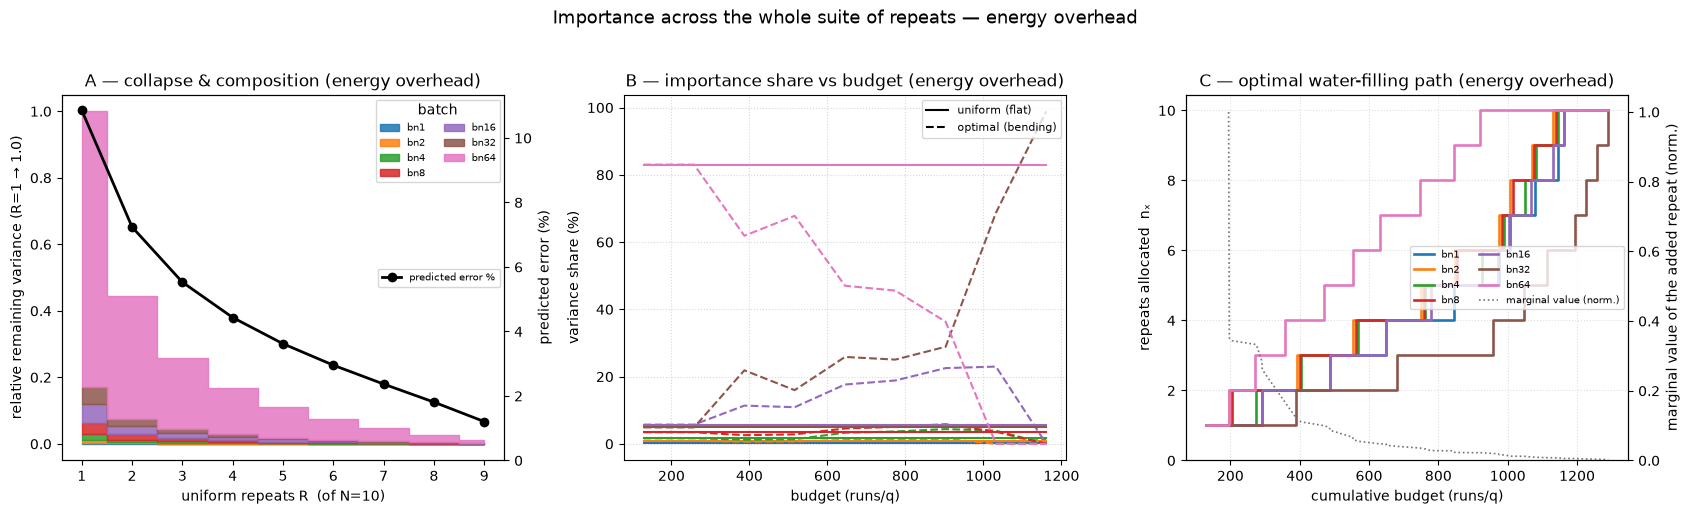

[energy overhead] uniform variance share is the SAME at every R (invariance):
   bn1 0%, bn2 1%, bn4 2%, bn8 3%, bn16 6%, bn32 5%, bn64 83%
   predicted error: R=1 10.86%, R=3 5.53%, R=9 1.21%   (R=10 → 0, the bias floor)
   error removed by repeats 1→3: 5.33 pts;  by 3→9: 4.32 pts  (diminishing returns ∝ 1/(R(R+1)))


In [24]:
coef2_slope = lev / DB ** 2        # (x−x̄)²/Sxx²  = coef of mₓ in the slope, squared
coef2_over = hlev                   # hₓ²            = coef of mₓ in the intercept, squared
sig2_rep = np.median(sig2, axis=0)  # representative per-batchnum variance (composition)
Rs = np.arange(1, N_REP)            # uniform repeat levels 1..N-1 (share undefined at N)


def err_pct(coef2, n):              # predicted % error (median across queries), bias=0
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP
    Var = (coef2[None, :] * sig2 * inv[None, :]).sum(1)
    return float(100 * np.median(np.sqrt(np.maximum(MED ** 2 * Var, 0)) / ab))


def optimal_alloc(coef2, B):        # greedy min-variance allocation within budget B
    n = np.ones(len(BATCH), int)

    def V(nn):
        inv = 1.0 / np.asarray(nn, float) - 1.0 / N_REP
        return float((coef2 * sig2_rep * inv).sum())
    while True:
        br, base, bj, bg = alloc_runs(n), V(n), -1, 0.0
        for j in range(len(BATCH)):
            if n[j] >= N_REP:
                continue
            t = n.copy(); t[j] += 1
            if alloc_runs(t) > B:
                continue
            dr = alloc_runs(t) - br
            g = (base - V(t)) / dr if dr > 0 else 0.0
            if g > bg:
                bg, bj = g, j
        if bj < 0:
            break
        n[bj] += 1
    return n


def waterfill_path(coef2):          # greedy path from 1 each up to N each
    n = np.ones(len(BATCH), int)

    def V(nn):
        inv = 1.0 / np.asarray(nn, float) - 1.0 / N_REP
        return float((coef2 * sig2_rep * inv).sum())
    xs, ns, mv = [alloc_runs(n)], [n.copy()], [np.nan]
    while (n < N_REP).any():
        br, base, bj, bg = alloc_runs(n), V(n), -1, -1.0
        for j in range(len(BATCH)):
            if n[j] >= N_REP:
                continue
            t = n.copy(); t[j] += 1; dr = alloc_runs(t) - br
            g = (base - V(t)) / dr if dr > 0 else 0.0
            if g > bg:
                bg, bj = g, j
        if bj < 0:
            break
        n[bj] += 1
        xs.append(alloc_runs(n)); ns.append(n.copy()); mv.append(bg)
    return np.array(xs), np.array(ns), np.array(mv)


def suite_importance(coef2, name, fname):
    # distinct categorical colours per batch size (avoid the viridis green/blue blur)
    _pal = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#17becf", "#bcbd22", "#7f7f7f"]
    cols = [_pal[k % len(_pal)] for k in range(len(BATCH))]
    fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(17, 5.2))

    # --- Panel A: collapse & composition (uniform R) ---
    contrib = np.array([coef2 * sig2_rep * (1.0 / R - 1.0 / N_REP) for R in Rs])
    scale = contrib.sum(1)[0]
    bottom = np.zeros(len(Rs))
    for k, b in enumerate(BATCH):
        axA.fill_between(Rs, bottom, bottom + contrib[:, k] / scale, step="mid",
                         color=cols[k], alpha=0.85, label=f"bn{b}")
        bottom += contrib[:, k] / scale
    axA.set_xlabel(f"uniform repeats R  (of N={N_REP})")
    axA.set_ylabel("relative remaining variance (R=1 → 1.0)")
    axA.set_xticks(Rs); axA.set_title(f"A — collapse & composition ({name})")
    axA.legend(fontsize=7, ncol=2, title="batch", loc="upper right")
    axA2 = axA.twinx()
    errs = [err_pct(coef2, [R] * len(BATCH)) for R in Rs]
    axA2.plot(Rs, errs, "k-o", lw=2, label="predicted error %")
    axA2.set_ylabel("predicted error (%)"); axA2.set_ylim(bottom=0)
    axA2.legend(fontsize=7, loc="center right")

    # --- Panel B: shares vs budget, uniform (flat) vs optimal (bending) ---
    budgets = [alloc_runs([R] * len(BATCH)) for R in Rs]
    su = coef2 * sig2_rep; su = su / su.sum()
    opt = np.array([(lambda n: (coef2 * sig2_rep * (1.0 / n - 1.0 / N_REP)))(
        optimal_alloc(coef2, B)) for B in budgets])
    opt = opt / opt.sum(1, keepdims=True)
    for k, b in enumerate(BATCH):
        axB.plot(budgets, [su[k] * 100] * len(budgets), "-", color=cols[k])
        axB.plot(budgets, opt[:, k] * 100, "--", color=cols[k])
    axB.plot([], [], "k-", label="uniform (flat)")
    axB.plot([], [], "k--", label="optimal (bending)")
    axB.set_xlabel("budget (runs/q)"); axB.set_ylabel("variance share (%)")
    axB.set_title(f"B — importance share vs budget ({name})")
    axB.grid(linestyle=":", alpha=0.5); axB.legend(fontsize=8, loc="upper right")

    # --- Panel C: water-filling path ---
    xs, ns, mv = waterfill_path(coef2)
    for k, b in enumerate(BATCH):
        axC.step(xs, ns[:, k], where="post", color=cols[k], lw=1.9, label=f"bn{b}")
    axC.set_xlabel("cumulative budget (runs/q)")
    axC.set_ylabel("repeats allocated  nₓ"); axC.set_ylim(bottom=0)
    axC.set_title(f"C — optimal water-filling path ({name})")
    axC.grid(linestyle=":", alpha=0.4)
    axC2 = axC.twinx()
    axC2.plot(xs[1:], mv[1:] / np.nanmax(mv[1:]), color="0.45", lw=1.2, ls=":",
              label="marginal value (norm.)")
    axC2.set_ylabel("marginal value of the added repeat (norm.)")
    axC2.set_ylim(bottom=0)
    h1, l1 = axC.get_legend_handles_labels()
    h2, l2 = axC2.get_legend_handles_labels()
    axC.legend(h1 + h2, l1 + l2, fontsize=7, ncol=2, loc="center right")

    fig.suptitle(f"Importance across the whole suite of repeats — {name}",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(FIG_DIR / fname, format="svg", bbox_inches="tight")
    plt.show()

    print(f"[{name}] uniform variance share is the SAME at every R (invariance):")
    print("   " + ", ".join(f"bn{b} {100 * s:.0f}%" for b, s in zip(BATCH, su)))
    print(f"   predicted error: R=1 {errs[0]:.2f}%, R=3 {err_pct(coef2, [3] * len(BATCH)):.2f}%, "
          f"R={N_REP-1} {errs[-1]:.2f}%   (R={N_REP} → 0, the bias floor)")
    g_early = errs[0] - err_pct(coef2, [3] * len(BATCH))
    g_late = err_pct(coef2, [3] * len(BATCH)) - errs[-1]
    print(f"   error removed by repeats 1→3: {g_early:.2f} pts;  "
          f"by 3→{N_REP-1}: {g_late:.2f} pts  (diminishing returns ∝ 1/(R(R+1)))")


suite_importance(coef2_slope, "energy slope", "suite_importance_energy_slope.svg")
suite_importance(coef2_over, "energy overhead", "suite_importance_energy_overhead.svg")


## 14. Frontier comparison across matching datasets (indexed vs minimally-indexed)

Every section above analyses the **one** run chosen by `RUN_SELECT`. This section
instead overlays the **accuracy-vs-cost frontier** (as in §11, for the energy
slope) of **all matching runs** in the cache, so the fully-indexed ~530-run set
and the minimally-indexed ~530-run set land on the same axes.

**"Matching"** means both of:

* the run's **database equals the selected run's**, read from its `summary.txt` and
  compared with any `_idx` / `_noidx` suffix stripped — so `tpch` and `tpch_idx`
  count as the same database; and
* the `summary.txt` records an **`entries`** count — which drops aborted
  `run_order`-only folders and supplies the per-query wall-time estimate.

For each matching run we rebuild its energy cube, take its own full design as
ground truth, sweep the same batch-set × repeat grid, and draw its Pareto frontier
(fewest **runs per query** for a given energy-slope error). Comparing on
**runs/query** is index-agnostic; the cutoff table adds the **wall-time** at each
accuracy level, where the indexed run's faster queries show through. Both figures
are saved to `./figures/`.


In [25]:
# ---- find matching datasets from their summary.txt (independent of RUN_SELECT) ----
def _summary_blob(timing_key):
    d = timing_key.rsplit("/", 1)[0] if "/" in timing_key else ""
    skey = (d + "/summary.txt") if d else "summary.txt"
    return BLOBS.get(skey)


def _parse_summary(blob):
    if not blob:
        return {}
    t = blob.decode("utf-8", "replace"); out = {}
    m = re.search(r"\b(?:database|db)\b\s*[:=]\s*(\S+)", t, re.I)
    if m: out["db"] = m.group(1)
    m = re.search(r"\bentries\b\s*[:=]\s*(\d+)", t, re.I)
    if m: out["entries"] = int(m.group(1))
    m = re.search(r"\((\d+)\s*seconds\)", t)
    if m: out["seconds"] = int(m.group(1))
    return out


def _base_db(name):
    return re.sub(r"_(?:idx|noidx)$", "", str(name), flags=re.I)


REG = discover_runs(BLOBS)
rows = []
for _, r in REG.iterrows():
    s = _parse_summary(_summary_blob(r["timing_key"]))
    db = s.get("db", r["db"])
    rows.append(dict(run_id=r["run_id"], timing_key=r["timing_key"], db=db,
                     base=_base_db(db), entries=s.get("entries"),
                     seconds=s.get("seconds"), groups=r["groups"]))
info = pd.DataFrame(rows)

sel_sum = _parse_summary(_summary_blob(SEL["timing_key"]))
sel_base = _base_db(sel_sum.get("db", SEL["db"]))
cand = info[(info["base"] == sel_base) & info["entries"].notna()]
# one run per db name: keep the SELECTED run for its db, else the most complete
# (avoids two tpch_idx runs — e.g. a 1-16 and a 1-64 sweep — both entering)
keep = []
for db, g in cand.groupby("db"):
    sr = g[g["timing_key"] == SEL["timing_key"]]
    keep.append(sr.iloc[0] if len(sr) else g.sort_values("groups").iloc[-1])
match = pd.DataFrame(keep)
match["_ix"] = match["db"].str.lower().str.endswith("idx")   # list *_idx first
match = (match.sort_values("_ix", ascending=False)
         .drop(columns="_ix").reset_index(drop=True))
print(f"selected database base = '{sel_base}';  matching datasets (one per db, "
      f"with a summary entries count): {len(match)}")
print(match[["run_id", "db", "groups", "entries", "seconds"]].to_string(index=False))


# ---- gate: only compare datasets that share the same batch set AND repeat count ----
# (different repeats make the per-config error values incomparable, so skip)
def _capped_bset_reps(timing_key):
    d = pd.read_csv(io.BytesIO(BLOBS[timing_key]))
    b = pd.to_numeric(d.loc[d["phase"] == "measured", "batchnum"], errors="coerce")
    allb = sorted(set(int(x) for x in b.dropna().unique()))
    bset = tuple(x for x in allb if x in set(BATCH))
    reps = int(round(d["run_id"].nunique() / max(d["query"].nunique(), 1)))
    return bset, reps


_DI = {m["db"]: _capped_bset_reps(m["timing_key"]) for _, m in match.iterrows()}
DS_BSETS = {k: v[0] for k, v in _DI.items()}
DS_REPS = {k: v[1] for k, v in _DI.items()}
COMPARE_OK = (len(match) >= 2 and len(set(DS_BSETS.values())) == 1
              and len(set(DS_REPS.values())) == 1)
if not COMPARE_OK:
    print("\n!! Cross-dataset comparison (§14–§15) SKIPPED — the matched datasets "
          "differ in batch set or repeat count (or there is only one):")
    for db in DS_BSETS:
        print(f"     {db}: batches {list(DS_BSETS[db])}, ~{DS_REPS[db]} repeats")
    print(f"   (BATCH_MAX={BATCH_MAX}; comparisons need the same batch set AND the "
          "same repeat count — different repeats make the errors incomparable.)")


# ---- energy-slope frontier for one dataset (self-contained, mirrors §10/§11) ----
def dataset_cfg(timing_key, summ):
    d = pd.read_csv(io.BytesIO(BLOBS[timing_key]))
    for c in ["batchnum", "elapsed_sec", "rapl_pkg_j", "failed"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d[d["failed"].fillna(0) == 0].copy()
    d.loc[d["rapl_pkg_j"] < 0, "rapl_pkg_j"] = np.nan
    d["qid"] = d["query"].astype(str).str.replace(
        r"^queries/tpch/tpch-queries/", "", regex=True)
    d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], errors="coerce")
    meas = d[d["phase"] == "measured"].dropna(subset=["batchnum", "rapl_pkg_j"]).copy()
    srt = d.sort_values("timestamp_utc"); rmap = {}
    for qid, g in srt.groupby("qid"):
        for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
            rmap[(qid, rid)] = i
    meas["repeat"] = [rmap[(q, r)] for q, r in zip(meas["qid"], meas["run_id"])]
    bset_all = sorted(set(int(b) for b in meas["batchnum"].unique()))
    bset = [b for b in bset_all if b in set(BATCH)]   # analysis set (<= BATCH_MAX)
    Rav = int(meas["repeat"].max()) if len(meas) else 0
    if len(bset) < 2 or Rav < 2:
        return None
    qids = sorted(meas["qid"].unique())
    qp = {q: i for i, q in enumerate(qids)}; bp = {b: i for i, b in enumerate(bset)}
    C = np.full((len(qids), len(bset), Rav), np.nan)
    for q, b, r, v in zip(meas["qid"], meas["batchnum"], meas["repeat"],
                          meas["rapl_pkg_j"]):
        if int(b) in bp and 1 <= int(r) <= Rav:
            C[qp[q], bp[int(b)], int(r) - 1] = v
    qmask = ~np.isnan(C).any(axis=(1, 2))
    if qmask.sum() < 3:
        return None

    def si(bidx, ridx):
        sub = C[qmask][:, bidx][:, :, ridx]
        Y = sub.reshape(sub.shape[0], -1)
        x = np.repeat(np.array([bset[i] for i in bidx], float), len(ridx))
        xc = x - x.mean()
        return Y @ xc / (xc ** 2).sum()

    s_true = si(list(range(len(bset))), list(range(Rav)))
    denom = np.abs(s_true)
    wct = d[d["phase"] == "warmup"]
    W = int(round(wct.groupby(["qid", "run_id"]).size().mean())) if len(wct) else 2
    fullc = W + sum(bset_all)             # run's real full group (for wall-time)
    if summ.get("entries") and summ.get("seconds"):
        spe = summ["seconds"] / summ["entries"]
    else:
        spe = d["elapsed_sec"].sum() / d["run_id"].nunique()
    bsets = make_batch_sets(bset)   # candidate sets from THIS dataset's batches
    rlist = [r for r in R_LIST if r <= Rav]
    recs = []
    for bs in bsets:
        bidx = [bp[b] for b in bs]
        for R in rlist:
            errs = [np.median(np.abs(si(bidx, list(cmb)) - s_true) / denom)
                    for cmb in itertools.combinations(range(Rav), R)]
            recs.append(dict(batch_set=",".join(map(str, bs)), R=R,
                             err=100 * np.mean(errs), runs=R * (W + sum(bs)),
                             secs=R * spe * (W + sum(bs)) / fullc))
    cfgD = pd.DataFrame(recs)
    e, rr = cfgD["err"].to_numpy(), cfgD["runs"].to_numpy()
    dom = (((e[None, :] <= e[:, None]) & (rr[None, :] <= rr[:, None]) &
            ((e[None, :] < e[:, None]) | (rr[None, :] < rr[:, None]))).any(1))
    cfgD["pareto"] = ~dom
    return dict(cfg=cfgD, Rav=Rav, bset=bset, nq=int(qmask.sum()), spe=spe)


frontiers = []
if COMPARE_OK:
    for _, m in match.iterrows():
        res = dataset_cfg(m["timing_key"],
                          {"entries": m["entries"], "seconds": m["seconds"]})
        if res is not None:
            res["label"] = f"{m['db']} — {m['groups']}g, R={res['Rav']}"
            res["db"] = m["db"]; res["groups"] = m["groups"]
            frontiers.append(res)
            print(f"  {m['db']:<12} R={res['Rav']} batches={res['bset']} "
                  f"queries={res['nq']} sec/entry={res['spe']:.1f}")

if not COMPARE_OK:
    print("(§14 frontier comparison skipped — datasets differ in batch sets.)")
else:
    # ---- overlay the energy-slope frontiers ----
    palette = ["#1f3b73", "#c44e52", "#55a868", "#8c6d1f", "#7b539c"]
    fig, ax = plt.subplots(figsize=(10, 6.2))
    ymax = 0.5
    for i, fr in enumerate(frontiers):
        c = palette[i % len(palette)]
        cfgD = fr["cfg"]; pfD = cfgD[cfgD["pareto"]].sort_values("runs")
        ax.scatter(cfgD["runs"], cfgD["err"], s=10, color=c, alpha=0.22, zorder=2)
        ax.plot(pfD["runs"], pfD["err"], "-o", ms=4, color=c, zorder=3,
                label=fr["label"])
        ymax = max(ymax, float(pfD["err"].quantile(0.9)))
    ax.set_ylim(0, min(4.0, ymax * 1.25)); ax.set_xlim(left=0)
    ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
    ax.set_title("Energy-slope accuracy vs cost — frontier per matching dataset")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(title="dataset")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "frontier_compare_datasets_energy_slope.svg",
                format="svg", bbox_inches="tight")
    plt.show()

    # ---- cutoff comparison table: cheapest config to hit each accuracy level ----
    CUTS = [0.5, 1.0, 2.0]
    cols = ["dataset"] + [f"≤ {c:g}%  (runs/q · ~t/q)" for c in CUTS]
    rows, rowcolors = [], []
    for i, fr in enumerate(frontiers):
        cfgD = fr["cfg"]; row = [fr["label"]]
        for c in CUTS:
            feas = cfgD[cfgD["err"] <= c + 1e-9].sort_values(["runs", "err"])
            if len(feas):
                x = feas.iloc[0]
                row.append(f"{x['batch_set']} R{int(x['R'])}\n{int(x['runs'])} · "
                           f"{fmt_dur(x['secs'])}")
            else:
                row.append("—")
        rows.append(row); rowcolors.append("#f2f2f2" if i % 2 else "white")
    fig, ax = plt.subplots(figsize=(11, 0.7 * len(rows) + 1.0))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center",
                   bbox=[0, 0, 1, 1], colWidths=[0.34] + [0.22] * len(CUTS))
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    tbl.scale(1, 2.2)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i, rc in enumerate(rowcolors):
        for j in range(len(cols)):
            tbl[i + 1, j].set_facecolor(rc)
    ax.set_title("Cheapest energy-slope config to reach each accuracy cutoff, "
                 "per dataset", fontsize=10, pad=12)
    fig.savefig(FIG_DIR / "frontier_compare_cutoffs.svg", format="svg",
                bbox_inches="tight")
    plt.show()


selected database base = 'tpch';  matching datasets (one per db, with a summary entries count): 2
                 run_id       db  groups  entries  seconds
20260917T105341Z-de2df1 tpch_idx     530    530.0  50638.0
20260911T114224Z-7b276d     tpch     530    530.0  47584.0

!! Cross-dataset comparison (§14–§15) SKIPPED — the matched datasets differ in batch set or repeat count (or there is only one):
     tpch_idx: batches [1, 2, 4, 8, 16, 32, 64], ~10 repeats
     tpch: batches [1, 2, 4, 8, 16], ~10 repeats
   (BATCH_MAX=64; comparisons need the same batch set AND the same repeat count — different repeats make the errors incomparable.)
(§14 frontier comparison skipped — datasets differ in batch sets.)


### 14b. Every frontier config on both sets — and how it fares on the other

The **union of the two Pareto frontiers**: each row is a config that is frontier on
at least one dataset. The per-dataset columns give **that config's** error and
wall-time on each set (i.e. the same config re-scored on the other one), and the two
**PF** columns tick whether it sits on that set's frontier — so a row ticked in
**both** (shaded green) is jointly optimal, while a row ticked in only one is a buy
that the indexing choice makes or breaks. `runs/q` is shared (same warm-ups + batch
copies), which is why it can be compared directly. Saved to `./figures/`.


In [26]:
if COMPARE_OK and len(frontiers) >= 2:
    def _cmap(fr):
        c = fr["cfg"].copy()
        c["key"] = c["batch_set"] + "|" + c["R"].astype(int).astype(str)
        return c.set_index("key")

    maps = [_cmap(fr) for fr in frontiers]
    union = set()
    for m in maps:
        union |= set(m.index[m["pareto"]])

    def _runs(k):
        for m in maps:
            if k in m.index:
                return int(m.loc[k, "runs"])
        return 0

    recs = []
    for k in union:
        bset, R = k.split("|")
        cells = [f"{bset} R{R}", str(_runs(k))]
        npf = 0
        for m in maps:
            if k in m.index:
                x = m.loc[k]; pf = bool(x["pareto"]); npf += int(pf)
                cells += [f"{x['err']:.2f}", fmt_dur(x["secs"]), "✓" if pf else ""]
            else:
                cells += ["—", "—", ""]
        both = (npf == len(frontiers))
        sort_err = float(maps[0].loc[k, "err"]) if k in maps[0].index else 9e9
        recs.append((_runs(k), sort_err, both, cells))
    recs.sort(key=lambda t: (t[0], t[1]))

    cols = ["config", "runs/q"]
    for fr in frontiers:
        cols += [f"{fr['db']}\nerr%", f"{fr['db']}\n~t/q", f"{fr['db']}\nPF"]
    rows = [r[3] for r in recs]
    rowflags = [r[2] for r in recs]

    w = [0.15, 0.08]
    for _ in frontiers:
        w += [0.09, 0.09, 0.06]
    w = [wi / sum(w) for wi in w]

    fig, ax = plt.subplots(figsize=(2.6 + 2.3 * len(frontiers), 0.30 * len(rows) + 1.2))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center",
                   bbox=[0, 0, 1, 1], colWidths=w)
    tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
    tbl.scale(1, 1.6)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i, both in enumerate(rowflags):
        rc = "#e6f4ea" if both else ("#f2f2f2" if i % 2 else "white")
        for j in range(len(cols)):
            tbl[i + 1, j].set_facecolor(rc)
    ax.set_title("Union of the energy-slope Pareto frontiers across both datasets "
                 "(green = frontier on both; PF = on that set's frontier)",
                 fontsize=10, pad=12)
    fig.savefig(FIG_DIR / "frontier_compare_configs_table.svg", format="svg",
                bbox_inches="tight")
    plt.show()
    nboth = sum(rowflags)
    print(f"{len(rows)} configs on at least one frontier; {nboth} on both "
          f"({', '.join(fr['db'] for fr in frontiers)}).")
    for r in recs:
        print(f"   {r[3][0]:<12} {r[3][1]:>4} runs/q   frontier-on: "
              + ", ".join(fr['db'] for fr, cell in zip(frontiers, r[3][4::3]) if cell))
else:
    print("(§14b cross-frontier table skipped — need two matching datasets that "
          "share a batch set.)")


(§14b cross-frontier table skipped — need two matching datasets that share a batch set.)


### 14c. The same comparison for non-uniform allocation

§14/§14b compared the datasets using **uniform** repeats. This repeats the comparison
with the **non-uniform allocation** model of §12: for each matching dataset we rebuild
its energy cube, take its full design as ground truth, and predict every allocation's
error as `√(bias² + σ²)` with the finite-population correction, keeping only batch sets
whose full-data (bias-floor) error is ≤ 1%. The **plot** overlays each dataset's
allocation Pareto frontier (fewest runs/q for a given predicted energy-slope error);
the **table** gives the cheapest allocation to reach each accuracy cutoff on each
dataset, with its runs/q and wall-time. As in §14, runs/q is index-agnostic while
~t/q exposes the minimally-indexed set's slower queries. Figures saved to `./figures/`.

Each dataset is rebuilt **self-contained** here (its own complete-cube query set, the
same convention as §14's uniform comparison), so the selected run's frontier below can
differ slightly from §12 — which analyses the selected run alone and drops one query
with an incomplete energy cube.


In [27]:
# non-uniform allocation frontier for one dataset (mirrors §12, self-contained)
def dataset_alloc_cfg(timing_key, summ):
    d = pd.read_csv(io.BytesIO(BLOBS[timing_key]))
    for c in ["batchnum", "elapsed_sec", "rapl_pkg_j", "failed"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d[d["failed"].fillna(0) == 0].copy()
    d.loc[d["rapl_pkg_j"] < 0, "rapl_pkg_j"] = np.nan
    d["qid"] = d["query"].astype(str).str.replace(
        r"^queries/tpch/tpch-queries/", "", regex=True)
    d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], errors="coerce")
    meas = d[d["phase"] == "measured"].dropna(subset=["batchnum", "rapl_pkg_j"]).copy()
    srt = d.sort_values("timestamp_utc"); rmap = {}
    for qid, g in srt.groupby("qid"):
        for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
            rmap[(qid, rid)] = i
    meas["repeat"] = [rmap[(q, r)] for q, r in zip(meas["qid"], meas["run_id"])]
    bset_all = sorted(set(int(b) for b in meas["batchnum"].unique()))
    bset = [b for b in bset_all if b in set(BATCH)]   # analysis set (<= BATCH_MAX)
    Rav = int(meas["repeat"].max()) if len(meas) else 0
    if len(bset) < 2 or Rav < 2:
        return None
    qids = sorted(meas["qid"].unique())
    qp = {q: i for i, q in enumerate(qids)}; bp = {b: i for i, b in enumerate(bset)}
    C = np.full((len(qids), len(bset), Rav), np.nan)
    for q, b, r, v in zip(meas["qid"], meas["batchnum"], meas["repeat"],
                          meas["rapl_pkg_j"]):
        if int(b) in bp and 1 <= int(r) <= Rav:
            C[qp[q], bp[int(b)], int(r) - 1] = v
    qmask = ~np.isnan(C).any(axis=(1, 2))
    if qmask.sum() < 3:
        return None
    Cq = C[qmask]; xb = np.array(bset, float)
    meanx = Cq.mean(axis=2); sdx = Cq.std(axis=2, ddof=1)

    def _slope(Y, xs):
        xc = xs - xs.mean()
        return (Y * xc).sum(1) / (xc ** 2).sum()

    b_full = _slope(meanx, xb); ab = np.abs(b_full)
    wct = d[d["phase"] == "warmup"]
    W = int(round(wct.groupby(["qid", "run_id"]).size().mean())) if len(wct) else 2
    fullc = W + sum(bset_all)             # run's real full group (for wall-time)
    if summ.get("entries") and summ.get("seconds"):
        spe = summ["seconds"] / summ["entries"]
    else:
        spe = d["elapsed_sec"].sum() / d["run_id"].nunique()
    MED = 0.6745
    alloc_r = [r for r in ALLOC_R if r <= Rav]
    cand = make_batch_sets(bset)   # candidate sets from THIS dataset's batches
    keptd = []
    for bs in cand:
        idx = [bp[b] for b in bs]
        bias = _slope(meanx[:, idx], xb[idx]) - b_full
        if 100 * np.median(np.abs(bias) / ab) <= 1.0:
            keptd.append(bs)
    recs = []
    for bs in keptd:
        idx = [bp[b] for b in bs]
        bias = _slope(meanx[:, idx], xb[idx]) - b_full
        xs = xb[idx]; lev = (xs - xs.mean()) ** 2; DB = lev.sum()
        for n in itertools.product(alloc_r, repeat=len(idx)):
            inv = 1.0 / np.asarray(n, float) - 1.0 / Rav
            Var = (lev * sdx[:, idx] ** 2 * inv).sum(1) / DB ** 2
            err = 100 * np.median(np.sqrt(bias ** 2 + MED ** 2 * Var) / ab)
            runs = int(2 * max(n) + sum(ni * x for ni, x in zip(n, bs)))
            recs.append(dict(alloc=", ".join(f"{x}×{ni}" for x, ni in zip(bs, n)),
                             err=err, runs=runs, secs=spe * runs / fullc,
                             uniform=len(set(n)) == 1))
    if not recs:
        return None
    cfgA = pd.DataFrame(recs).sort_values(["runs", "err"]).reset_index(drop=True)
    best = np.inf; par = np.zeros(len(cfgA), bool)
    for i in range(len(cfgA)):
        if cfgA.at[i, "err"] < best - 1e-12:
            par[i] = True; best = cfgA.at[i, "err"]
    cfgA["pareto"] = par
    return dict(cfg=cfgA, Rav=Rav, bset=bset, nq=int(qmask.sum()), spe=spe)


alloc_frontiers = []
if COMPARE_OK:
    for _, m in match.iterrows():
        res = dataset_alloc_cfg(m["timing_key"],
                                {"entries": m["entries"], "seconds": m["seconds"]})
        if res is not None:
            res["label"] = f"{m['db']} — {m['groups']}g, R={res['Rav']}"
            res["db"] = m["db"]; res["groups"] = m["groups"]
            alloc_frontiers.append(res)
            nf = int(res["cfg"]["pareto"].sum())
            print(f"  {m['db']:<12} R={res['Rav']}  {res['nq']} queries, "
                  f"{len(res['cfg'])} allocations, {nf} on the frontier")

if not COMPARE_OK:
    print("(§14c allocation frontier comparison skipped — datasets differ in "
          "batch sets.)")
else:
    # ---- overlay the non-uniform allocation frontiers ----
    palette = ["#1f3b73", "#c44e52", "#55a868", "#8c6d1f", "#7b539c"]
    fig, ax = plt.subplots(figsize=(10, 6.2))
    ymax = 0.5
    for i, fr in enumerate(alloc_frontiers):
        c = palette[i % len(palette)]
        cfgA = fr["cfg"]; pf = cfgA[cfgA["pareto"]].sort_values("runs")
        ax.scatter(cfgA["runs"], cfgA["err"], s=6, color=c, alpha=0.12, zorder=2)
        ax.plot(pf["runs"], pf["err"], "-o", ms=3, color=c, zorder=3,
                label=fr["label"])
        ymax = max(ymax, float(pf["err"].quantile(0.9)))
    ax.set_ylim(0, min(2.0, ymax * 1.25)); ax.set_xlim(left=0)
    ax.set_xlabel("runs per query")
    ax.set_ylabel("predicted energy-slope error (%)")
    ax.set_title("Non-uniform allocation — accuracy vs cost frontier per dataset")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(title="dataset")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "frontier_compare_datasets_alloc_energy_slope.svg",
                format="svg", bbox_inches="tight")
    plt.show()

    # ---- cutoff table: cheapest ALLOCATION to hit each accuracy level ----
    CUTS = [0.5, 1.0, 2.0]
    cols = ["dataset"] + [f"≤ {c:g}%  (alloc · runs/q · ~t/q)" for c in CUTS]
    rows, rowcolors = [], []
    for i, fr in enumerate(alloc_frontiers):
        cfgA = fr["cfg"]; row = [fr["label"]]
        for c in CUTS:
            feas = cfgA[cfgA["err"] <= c + 1e-9].sort_values(["runs", "err"])
            if len(feas):
                x = feas.iloc[0]
                row.append(f"{x['alloc']}\n{int(x['runs'])} · {fmt_dur(x['secs'])}")
            else:
                row.append("—")
        rows.append(row); rowcolors.append("#f2f2f2" if i % 2 else "white")
    fig, ax = plt.subplots(figsize=(13, 0.95 * len(rows) + 1.1))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center",
                   bbox=[0, 0, 1, 1], colWidths=[0.24] + [0.253] * len(CUTS))
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    tbl.scale(1, 2.4)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i, rc in enumerate(rowcolors):
        for j in range(len(cols)):
            tbl[i + 1, j].set_facecolor(rc)
    ax.set_title("Cheapest non-uniform allocation to reach each accuracy cutoff, "
                 "per dataset", fontsize=10, pad=12)
    fig.savefig(FIG_DIR / "frontier_compare_cutoffs_alloc.svg", format="svg",
                bbox_inches="tight")
    plt.show()


(§14c allocation frontier comparison skipped — datasets differ in batch sets.)


### 14d. Are the same allocations optimal on both datasets? (predictability)

§14b answered this for **uniform** repeats; this ports it to **non-uniform** allocation
to settle a design question: uniform repeat counts are worth preferring if they stay
optimal across datasets (predictable), whereas if the *non-uniform* optimum is
dataset-specific, an allocation tuned on one database won't transfer to another.

The **summary** compares, per allocation style, how much of the combined frontier is
optimal on **both** datasets, and adds the **average error offset** between the two
datasets — the mean `|error_tpch_idx − error_tpch|` in **percentage points**, and, in
parentheses, the mean **% difference** (that gap relative to the two datasets' average
error, skipping near-zero full-design configs) — evaluated over all **union** configs
and over all **matching** (on-both) configs. A small offset means a config's predicted
accuracy transfers between databases; a large one means the error itself is
dataset-specific even where the config is jointly optimal. The **table** then
lists every non-uniform allocation on
at least one dataset's frontier, with its error and wall-time on each and a **PF** tick
per dataset (green = frontier on both) — the same layout as §14b. A low "on both" share
for non-uniform against a high one for uniform is the evidence that **uniform
allocations are the more portable choice**. Figures saved to `./figures/`.


In [28]:
def _union_stats(frs, keyfn):
    maps = []
    for fr in frs:
        c = fr["cfg"].copy(); c["key"] = c.apply(keyfn, axis=1)
        maps.append(c.set_index("key"))
    psets = [set(m.index[m["pareto"]]) for m in maps]
    union = set().union(*psets) if psets else set()
    both = set.intersection(*psets) if len(psets) >= 2 else set()
    return maps, union, both, psets


def avg_offset(maps, keys):
    """mean |error_A − error_B| (pts) over configs present on every dataset."""
    diffs = []
    for k in keys:
        if all(k in m.index for m in maps):
            errs = [float(m.loc[k, "err"]) for m in maps]
            diffs.append(max(errs) - min(errs))
    return float(np.mean(diffs)) if diffs else float("nan")


def signed_offset(maps, keys):
    """mean(error on last dataset − error on first) over shared configs (pts)."""
    diffs = []
    for k in keys:
        if all(k in m.index for m in maps):
            diffs.append(float(maps[-1].loc[k, "err"]) - float(maps[0].loc[k, "err"]))
    return float(np.mean(diffs)) if diffs else float("nan")


def avg_pct_offset(maps, keys, floor=0.05):
    """mean %-difference in error (range / mean of the datasets) over shared configs;
    configs whose mean error < floor pts are skipped (relative diff is meaningless
    once the error is essentially zero, e.g. the full design)."""
    vals = []
    for k in keys:
        if all(k in m.index for m in maps):
            errs = [float(m.loc[k, "err"]) for m in maps]
            mean = sum(errs) / len(errs)
            if mean > floor:
                vals.append(100 * (max(errs) - min(errs)) / mean)
    return float(np.mean(vals)) if vals else float("nan")


if not COMPARE_OK:
    print("(§14d predictability comparison skipped — datasets differ in batch sets.)")
else:
    uni_maps, uni_union, uni_both, uni_ps = _union_stats(
        frontiers, lambda r: f"{r['batch_set']}|{int(r['R'])}")
    nu_maps, nu_union, nu_both, nu_ps = _union_stats(
        alloc_frontiers, lambda r: r["alloc"])
    srows = []
    for name, frs, maps, ps, union, both in [
            ("uniform repeats", frontiers, uni_maps, uni_ps, uni_union, uni_both),
            ("non-uniform alloc", alloc_frontiers, nu_maps, nu_ps, nu_union, nu_both)]:
        per = " / ".join(f"{fr['db']}:{len(ps[i])}" for i, fr in enumerate(frs))
        pct = 100 * len(both) / len(union) if union else 0
        srows.append([name, per, str(len(union)), str(len(both)), f"{pct:.0f}%",
                      f"{avg_offset(maps, union):.2f} ({avg_pct_offset(maps, union):.0f}%)",
                      f"{avg_offset(maps, both):.2f} ({avg_pct_offset(maps, both):.0f}%)"])
    scols = ["allocation style", "# frontier per dataset", "union", "on both",
             "on both %", "avg Δerr\nunion (pts, %)", "avg Δerr\nmatching (pts, %)"]
    fig, ax = plt.subplots(figsize=(14, 0.6 * len(srows) + 1.4)); ax.axis("off")
    tbl = ax.table(cellText=srows, colLabels=scols, cellLoc="center",
                   bbox=[0, 0, 1, 1],
                   colWidths=[0.17, 0.25, 0.07, 0.08, 0.09, 0.17, 0.17])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.6)
    for j in range(len(scols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(len(srows)):
        for j in range(len(scols)):
            tbl[i + 1, j].set_facecolor("#e6f4ea" if i == 0 else "white")
    ax.set_title("Cross-dataset predictability — share of the frontier optimal on "
                 "BOTH datasets (higher = more portable)", fontsize=10, pad=12)
    fig.savefig(FIG_DIR / "frontier_predictability_summary.svg", format="svg",
                bbox_inches="tight")
    plt.show()
    d0, d1 = alloc_frontiers[0]["db"], alloc_frontiers[-1]["db"]
    print(f"uniform    : {len(uni_both)}/{len(uni_union)} of the union optimal on both"
          f" ({100 * len(uni_both) / max(len(uni_union), 1):.0f}%); "
          f"avg |Δerr| union {avg_offset(uni_maps, uni_union):.2f} pts "
          f"({avg_pct_offset(uni_maps, uni_union):.0f}%) / "
          f"matching {avg_offset(uni_maps, uni_both):.2f} pts "
          f"({avg_pct_offset(uni_maps, uni_both):.0f}%)")
    print(f"non-uniform: {len(nu_both)}/{len(nu_union)} of the union optimal on both "
          f"({100 * len(nu_both) / max(len(nu_union), 1):.0f}%); "
          f"avg |Δerr| union {avg_offset(nu_maps, nu_union):.2f} pts "
          f"({avg_pct_offset(nu_maps, nu_union):.0f}%) / "
          f"matching {avg_offset(nu_maps, nu_both):.2f} pts "
          f"({avg_pct_offset(nu_maps, nu_both):.0f}%)")
    print(f"signed offset ({d1} − {d0}) over the union: "
          f"uniform {signed_offset(uni_maps, uni_union):+.2f} pts, "
          f"non-uniform {signed_offset(nu_maps, nu_union):+.2f} pts "
          f"(positive → {d1} predicts higher error for the same config).")


(§14d predictability comparison skipped — datasets differ in batch sets.)


In [29]:
if COMPARE_OK and len(alloc_frontiers) >= 2:
    def _runs_nu(k):
        for m in nu_maps:
            if k in m.index:
                return int(m.loc[k, "runs"])
        return 0

    recs = []
    for k in nu_union:
        cells = [k, str(_runs_nu(k))]; npf = 0
        for m in nu_maps:
            if k in m.index:
                x = m.loc[k]; pf = bool(x["pareto"]); npf += int(pf)
                cells += [f"{x['err']:.2f}", fmt_dur(x["secs"]), "✓" if pf else ""]
            else:
                cells += ["—", "—", ""]
        both = npf == len(nu_maps)
        se = float(nu_maps[0].loc[k, "err"]) if k in nu_maps[0].index else 9e9
        recs.append((_runs_nu(k), se, both, cells))
    recs.sort(key=lambda t: (t[0], t[1]))

    cols = ["allocation", "runs/q"]
    for fr in alloc_frontiers:
        cols += [f"{fr['db']}\nerr%", f"{fr['db']}\n~t/q", f"{fr['db']}\nPF"]
    rows = [r[3] for r in recs]; rowflags = [r[2] for r in recs]
    w = [0.24, 0.07]
    for _ in alloc_frontiers:
        w += [0.08, 0.08, 0.05]
    w = [wi / sum(w) for wi in w]

    fig, ax = plt.subplots(figsize=(2.8 + 2.4 * len(alloc_frontiers),
                                    0.26 * len(rows) + 1.2))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1],
                   colWidths=w)
    tbl.auto_set_font_size(False); tbl.set_fontsize(6.5)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i, both in enumerate(rowflags):
        rc = "#e6f4ea" if both else ("#f2f2f2" if i % 2 else "white")
        for j in range(len(cols)):
            tbl[i + 1, j].set_facecolor(rc)
    ax.set_title(f"Non-uniform allocations on either frontier ({len(rows)} configs; "
                 "green = frontier on both)", fontsize=10, pad=10)
    fig.savefig(FIG_DIR / "frontier_compare_configs_table_alloc.svg", format="svg",
                bbox_inches="tight")
    plt.show()
    print(f"{len(rows)} allocations on at least one frontier; "
          f"{sum(rowflags)} on both datasets.")
else:
    print("(§14d allocation cross-frontier table skipped — need two matching "
          "datasets that share a batch set.)")


(§14d allocation cross-frontier table skipped — need two matching datasets that share a batch set.)


## 15. Is the tpch–tpch_idx frontier gap just a runtime effect?

§14 showed tpch's energy-slope frontier sits slightly **above** tpch_idx at equal
runs/q. But §7/§9 established that run-to-run variance grows with **test length
(runtime)**, and tpch's tests run longer — the per-copy warm runtime reaches ~50 s on
tpch vs ~5 s on tpch_idx (its heavy tail is what makes tpch average ~3× slower, even
though the *median* query runtime is similar). So the gap may be a **test-length
effect**, not indexing: tpch's slow-tail queries are noisier and drag the median error
up.

Both databases run the **same 53 TPC-H queries**, so we can pair every query across the
two and test this three ways:

* **(a) relationship** — per query, the energy-slope error driver
  (`√Var(slope)/|slope|`, the relative sampling spread that sets the frontier) against
  its runtime, both datasets on one axis. If they lie on a **single trend**, tpch is
  just further along it (longer runtimes), not intrinsically worse.
* **(b) matched runtime** — recompute tpch's frontier using only queries within
  tpch_idx's runtime range, and compare medians in the overlap.
* **(c) outlier removal** — drop the few noisiest (highest error-driver) tpch queries
  and see how much of the gap they were carrying.

Figures saved to `./figures/`.


In [30]:
def _slope_vec(Y, xs):
    xc = xs - xs.mean()
    return (Y * xc).sum(1) / (xc ** 2).sum()


def dataset_bundle(timing_key, summ):
    d = pd.read_csv(io.BytesIO(BLOBS[timing_key]))
    for c in ["batchnum", "elapsed_sec", "avg_copy_elapsed_sec", "rapl_pkg_j",
              "failed"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d[d["failed"].fillna(0) == 0].copy()
    d.loc[d["rapl_pkg_j"] < 0, "rapl_pkg_j"] = np.nan
    d["qid"] = d["query"].astype(str).str.replace(
        r"^queries/tpch/tpch-queries/", "", regex=True)
    d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], errors="coerce")
    meas = d[d["phase"] == "measured"].dropna(subset=["batchnum", "rapl_pkg_j"]).copy()
    srt = d.sort_values("timestamp_utc"); rmap = {}
    for qid, g in srt.groupby("qid"):
        for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
            rmap[(qid, rid)] = i
    meas["repeat"] = [rmap[(q, r)] for q, r in zip(meas["qid"], meas["run_id"])]
    bset_all = sorted(set(int(b) for b in meas["batchnum"].unique()))
    bset = [b for b in bset_all if b in set(BATCH)]   # analysis set (<= BATCH_MAX)
    Rav = int(meas["repeat"].max())
    qids = sorted(meas["qid"].unique())
    qp = {q: i for i, q in enumerate(qids)}; bp = {b: i for i, b in enumerate(bset)}
    C = np.full((len(qids), len(bset), Rav), np.nan)
    for q, b, r, v in zip(meas["qid"], meas["batchnum"], meas["repeat"],
                          meas["rapl_pkg_j"]):
        if int(b) in bp and 1 <= int(r) <= Rav:
            C[qp[q], bp[int(b)], int(r) - 1] = v
    qmask = ~np.isnan(C).any(axis=(1, 2))
    Cq = C[qmask]; kq = [q for q, m in zip(qids, qmask) if m]
    rt1 = meas[meas["batchnum"] == 1].groupby("qid")["avg_copy_elapsed_sec"].mean()
    rt = np.array([rt1.get(q, np.nan) for q in kq])
    xb = np.array(bset, float); lev = (xb - xb.mean()) ** 2; DB = lev.sum()
    meanx = Cq.mean(2); sdx = Cq.std(2, ddof=1)
    b_E = _slope_vec(meanx, xb); ab = np.abs(b_E)
    Var1 = (lev * sdx ** 2 * (1 - 1.0 / Rav)).sum(1) / DB ** 2      # R=1 slope var
    slope_cv = 100 * np.sqrt(Var1) / ab                            # % (error driver)
    wct = d[d["phase"] == "warmup"]
    W = int(round(wct.groupby(["qid", "run_id"]).size().mean())) if len(wct) else 2
    spe = (summ["seconds"] / summ["entries"]) if summ.get("entries") and \
        summ.get("seconds") else d["elapsed_sec"].sum() / d["run_id"].nunique()
    return dict(cube=Cq, qids=kq, runtime=rt, slope_cv=slope_cv, bset=bset,
                Rav=Rav, W=W, spe=spe, fullc=W + sum(bset_all))


if not COMPARE_OK:
    print("(§15 per-query runtime comparison skipped — datasets differ in "
          "batch sets.)")
    BI = BB = None
else:
    mi = [m for _, m in match.iterrows() if str(m["db"]).lower().endswith("idx")]
    mb = [m for _, m in match.iterrows() if not str(m["db"]).lower().endswith("idx")]
    mi, mb = mi[0], mb[0]
    BI = dataset_bundle(mi["timing_key"],
                        {"entries": mi["entries"], "seconds": mi["seconds"]})
    BB = dataset_bundle(mb["timing_key"],
                        {"entries": mb["entries"], "seconds": mb["seconds"]})

    dfI = pd.DataFrame(dict(qid=BI["qids"], rt=BI["runtime"], cv=BI["slope_cv"]))
    dfB = pd.DataFrame(dict(qid=BB["qids"], rt=BB["runtime"], cv=BB["slope_cv"]))
    mrg = (dfI.merge(dfB, on="qid", suffixes=("_i", "_b"))
           .replace([np.inf, -np.inf], np.nan).dropna())

    fig, (axA, axP) = plt.subplots(1, 2, figsize=(15, 5.6))
    # --- (a) error driver vs runtime, both datasets, one trend? ---
    for lbl, df, col in [(mi["db"], dfI, "#1f3b73"), (mb["db"], dfB, "#c44e52")]:
        g = df[(df["cv"] > 0) & (df["rt"] > 0)].dropna()
        axA.scatter(g["rt"], g["cv"], s=26, color=col, alpha=0.6, label=lbl)
    allg = pd.concat([dfI, dfB]).replace([np.inf, -np.inf], np.nan).dropna()
    allg = allg[(allg["cv"] > 0) & (allg["rt"] > 0)]
    sl, ic = np.polyfit(np.log10(allg["rt"]), np.log10(allg["cv"]), 1)
    xs = np.array([allg["rt"].min(), allg["rt"].max()])
    axA.plot(xs, 10 ** (ic + sl * np.log10(xs)), "k--", lw=1.4,
             label=f"shared trend (slope {sl:+.2f})")
    axA.set_xscale("log"); axA.set_yscale("log")
    axA.set_xlabel("per-copy warm runtime (s) — test length")
    axA.set_ylabel("energy-slope error driver  √Var/|slope|  (%, R=1)")
    axA.set_title("(a) per-query error driver vs runtime")
    axA.grid(which="both", linestyle=":", alpha=0.4); axA.legend(fontsize=8)

    # --- (b) paired ratios: does a longer runtime bring more error? ---
    mrg["rt_ratio"] = mrg["rt_b"] / mrg["rt_i"]
    mrg["cv_ratio"] = mrg["cv_b"] / mrg["cv_i"]
    mp = mrg[(mrg["rt_ratio"] > 0) & (mrg["cv_ratio"] > 0)]
    axP.scatter(mp["rt_ratio"], mp["cv_ratio"], s=26, color="#55708c", alpha=0.7)
    axP.axhline(1, color="k", lw=0.8, ls="--")
    axP.axvline(1, color="k", lw=0.8, ls=":")
    rr = np.corrcoef(np.log10(mp["rt_ratio"]), np.log10(mp["cv_ratio"]))[0, 1]
    axP.set_xscale("log"); axP.set_yscale("log")
    axP.set_xlabel(f"runtime ratio  {mb['db']} / {mi['db']}  (per query)")
    axP.set_ylabel(f"error-driver ratio  {mb['db']} / {mi['db']}")
    axP.set_title(f"(b) paired per-query change  (log-log corr {rr:+.2f})")
    axP.grid(which="both", linestyle=":", alpha=0.4)
    fig.suptitle("Does the frontier gap follow runtime? — per-query view",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(FIG_DIR / "runtime_effect_per_query.svg", format="svg",
                bbox_inches="tight")
    plt.show()

    lo = max(dfI["rt"].min(), dfB["rt"].min())
    hi = min(dfI["rt"].max(), dfB["rt"].max())
    mI = dfI[(dfI["rt"] >= lo) & (dfI["rt"] <= hi) & (dfI["cv"] > 0)]["cv"].median()
    mB = dfB[(dfB["rt"] >= lo) & (dfB["rt"] <= hi) & (dfB["cv"] > 0)]["cv"].median()
    print(f"per-copy runtime range: {mi['db']} {dfI['rt'].min():.2f}-"
          f"{dfI['rt'].max():.2f}s, {mb['db']} {dfB['rt'].min():.2f}-"
          f"{dfB['rt'].max():.2f}s")
    print(f"median error driver (all queries): {mi['db']} {dfI['cv'].median():.2f}%, "
          f"{mb['db']} {dfB['cv'].median():.2f}%")
    print(f"median error driver (matched runtime {lo:.2f}-{hi:.2f}s): "
          f"{mi['db']} {mI:.2f}%, {mb['db']} {mB:.2f}%  "
          f"<- if close, the gap is a runtime shift, not indexing")
    print(f"shared log-log trend slope (error driver vs runtime) = {sl:+.2f}")


(§15 per-query runtime comparison skipped — datasets differ in batch sets.)


### 15b. Frontier under a runtime lens — matched range and outlier removal

Now the frontier itself (energy slope, uniform repeats as in §14) recomputed on query
subsets. Three tpch curves are compared with the full tpch_idx frontier: tpch **as-is**,
tpch restricted to the **runtime-matched** queries (within tpch_idx's runtime range),
and tpch with its **few noisiest queries removed**. If the matched/trimmed tpch curves
drop onto tpch_idx, the gap was carried by long, noisy tail queries — a test-length
effect. Saved to `./figures/`.


In [31]:
def frontier_sub(bundle, qsel):
    C = bundle["cube"][qsel]
    if C.shape[0] < 3:
        return None
    bset, Rav = bundle["bset"], bundle["Rav"]
    W, spe, fullc = bundle["W"], bundle["spe"], bundle["fullc"]
    bp = {b: i for i, b in enumerate(bset)}

    def si(bidx, ridx):
        sub = C[:, bidx][:, :, ridx]; Y = sub.reshape(sub.shape[0], -1)
        x = np.repeat(np.array([bset[i] for i in bidx], float), len(ridx))
        xc = x - x.mean(); return Y @ xc / (xc ** 2).sum()

    s_true = si(list(range(len(bset))), list(range(Rav))); denom = np.abs(s_true)
    recs = []
    for bs in make_batch_sets(bset):
        bidx = [bp[b] for b in bs]
        for R in [r for r in R_LIST if r <= Rav]:
            errs = [np.median(np.abs(si(bidx, list(cmb)) - s_true) / denom)
                    for cmb in itertools.combinations(range(Rav), R)]
            recs.append(dict(err=100 * np.mean(errs), runs=R * (W + sum(bs)),
                             secs=R * spe * (W + sum(bs)) / fullc))
    cfg = pd.DataFrame(recs)
    e, rr = cfg["err"].to_numpy(), cfg["runs"].to_numpy()
    dom = (((e[None, :] <= e[:, None]) & (rr[None, :] <= rr[:, None]) &
            ((e[None, :] < e[:, None]) | (rr[None, :] < rr[:, None]))).any(1))
    cfg["pareto"] = ~dom
    return cfg.sort_values("runs")


if not COMPARE_OK:
    print("(§15b frontier-under-runtime comparison skipped — datasets differ in "
          "batch sets.)")
else:
    rtB = BB["runtime"]; cvB = BB["slope_cv"]
    sel_all = np.ones(len(rtB), bool)
    sel_match = (rtB <= BI["runtime"].max()) & np.isfinite(rtB)   # within idx range
    K = 5
    order = np.argsort(np.where(np.isfinite(cvB), cvB, -np.inf))  # noisiest last
    sel_trim = np.ones(len(rtB), bool); sel_trim[order[-K:]] = False

    fI = frontier_sub(BI, np.ones(len(BI["runtime"]), bool))
    fB = frontier_sub(BB, sel_all)
    fBm = frontier_sub(BB, sel_match)
    fBt = frontier_sub(BB, sel_trim)

    fig, ax = plt.subplots(figsize=(10, 6.2))
    curves = [(fI, f"{mi['db']} (all {int(sel_all.size)}q)", "#1f3b73", "-o", 1.0),
              (fB, f"{mb['db']} (all {int(sel_all.sum())}q)", "#c44e52", "-o", 1.0),
              (fBm, f"{mb['db']} runtime-matched ({int(sel_match.sum())}q)",
               "#dd8452", "--s", 0.9),
              (fBt, f"{mb['db']} minus {K} noisiest ({int(sel_trim.sum())}q)",
               "#8c6d1f", ":^", 0.9)]
    for cfg, lbl, c, style, a in curves:
        if cfg is None:
            continue
        pf = cfg[cfg["pareto"]].sort_values("runs")
        ax.plot(pf["runs"], pf["err"], style, color=c, alpha=a, ms=4, label=lbl)
    ax.set_ylim(0, 2.0); ax.set_xlim(left=0)
    ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
    ax.set_title("Frontier under a runtime lens — does the tpch gap close?")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "runtime_effect_frontier.svg", format="svg",
                bbox_inches="tight")
    plt.show()

    def _err_at(cfg, runs):
        pf = cfg[cfg["pareto"]]
        f = pf[pf["runs"] <= runs]
        return f["err"].min() if len(f) else np.nan

    for r in [57, 95, 190]:
        print(f"energy-slope error at <= {r} runs/q:  "
              f"{mi['db']} {_err_at(fI, r):.2f}%,  {mb['db']} {_err_at(fB, r):.2f}%,  "
              f"{mb['db']} matched {_err_at(fBm, r):.2f}%,  "
              f"{mb['db']} trimmed {_err_at(fBt, r):.2f}%")
    print(f"\nThe {K} noisiest {mb['db']} queries removed: "
          + ", ".join(str(BB['qids'][i]) for i in order[-K:][::-1]))


(§15b frontier-under-runtime comparison skipped — datasets differ in batch sets.)


### 15c. Per-query comparison table — tpch_idx vs tpch

Both databases run the **same queries**, so this pairs them row by row (reusing §15's
bundles). For each query and each dataset it reports the quantities that bear on the
frontier gap:

* **rt (s)** — per-copy warm runtime (test length);
* **E/run (J)** — per-run package energy at `batchnum=1` (the quantity being fit);
* **eCV %** — run-to-run coefficient of variation of that per-run energy (the raw
  measurement **variance**, relative);
* **slopeCV %** — the energy-slope error driver `√Var/|slope|` at R=1 (what actually
  sets each query's contribution to the frontier).

Rows are sorted by **tpch slopeCV** (noisiest first); the top-5 (the queries §15b
removes) are shaded. This is the query-level view of why tpch's frontier sits a little
higher — look for high tpch slopeCV that is **not** matched by a long runtime. Saved to
`./figures/`.


In [32]:
def per_query_table(B):
    e1 = B["cube"][:, 0, :]            # batchnum=1 energy across repeats (per-run J)
    return pd.DataFrame(dict(
        qid=[q.replace(".sql", "") for q in B["qids"]],
        rt=B["runtime"], eJ=e1.mean(1),
        eCV=100 * e1.std(1, ddof=1) / e1.mean(1),
        slopeCV=B["slope_cv"]))


if not COMPARE_OK:
    print("(§15c per-query comparison table skipped — datasets differ in batch sets.)")
else:
    TI = per_query_table(BI); TB = per_query_table(BB)
    M = (TI.merge(TB, on="qid", suffixes=("_i", "_b"))
         .replace([np.inf, -np.inf], np.nan)
         .sort_values("slopeCV_b", ascending=False).reset_index(drop=True))

    cols = ["query", "rt idx (s)", "rt tpch (s)", "E/run idx (J)", "E/run tpch (J)",
            "eCV idx %", "eCV tpch %", "slopeCV idx %", "slopeCV tpch %"]
    rows = []
    for _, x in M.iterrows():
        rows.append([x["qid"], f"{x['rt_i']:.2f}", f"{x['rt_b']:.2f}",
                     f"{x['eJ_i']:.2f}", f"{x['eJ_b']:.2f}",
                     f"{x['eCV_i']:.1f}", f"{x['eCV_b']:.1f}",
                     f"{x['slopeCV_i']:.1f}", f"{x['slopeCV_b']:.1f}"])

    fig, ax = plt.subplots(figsize=(15, 0.24 * len(rows) + 1.1)); ax.axis("off")
    w = [0.16] + [0.105] * 8; w = [wi / sum(w) for wi in w]
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center",
                   bbox=[0, 0, 1, 1], colWidths=w)
    tbl.auto_set_font_size(False); tbl.set_fontsize(6.5)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor("#1f3b73")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(len(rows)):
        rc = "#f6d9d5" if i < 5 else ("#f2f2f2" if i % 2 else "white")  # top-5 shaded
        for j in range(len(cols)):
            tbl[i + 1, j].set_facecolor(rc)
    ax.set_title(f"Per-query comparison — {mi['db']} vs {mb['db']} "
                 "(sorted by tpch slope-CV; top-5 noisiest shaded)",
                 fontsize=10, pad=10)
    fig.savefig(FIG_DIR / "per_query_compare.svg", format="svg", bbox_inches="tight")
    plt.show()

    pd.set_option("display.width", 200, "display.max_rows", 200)
    show = M.rename(columns={"qid": "query", "rt_i": "rt_idx", "rt_b": "rt_tpch",
                             "eJ_i": "Ejrun_idx", "eJ_b": "Ejrun_tpch",
                             "eCV_i": "eCV_idx%", "eCV_b": "eCV_tpch%",
                             "slopeCV_i": "slpCV_idx%", "slopeCV_b": "slpCV_tpch%"})
    print(show.round(2).to_string(index=False))
    print(f"\nmedians — rt: idx {M['rt_i'].median():.2f}s / tpch "
          f"{M['rt_b'].median():.2f}s;  eCV: idx {M['eCV_i'].median():.1f}% / tpch "
          f"{M['eCV_b'].median():.1f}%;  slopeCV: idx {M['slopeCV_i'].median():.1f}% "
          f"/ tpch {M['slopeCV_b'].median():.1f}%")
    hi = M.head(5)
    print(f"top-5 noisiest tpch queries carry slopeCV {hi['slopeCV_b'].min():.1f}-"
          f"{hi['slopeCV_b'].max():.1f}% at runtimes {hi['rt_b'].min():.2f}-"
          f"{hi['rt_b'].max():.2f}s (not the longest queries).")


(§15c per-query comparison table skipped — datasets differ in batch sets.)
